# 🐼 Pandas in Python — Complete Student Course (Beginner → Advanced)


This notebook is a **teaching-first, code-first course** for learning Pandas from scratch and then progressing to advanced, real-world data-analysis workflows.

It is designed to be taught in class: concepts are explained in simple language, followed by small examples, mental models, common mistakes, practice tasks, and end-to-end projects.

### What this course covers
- What Pandas is, why it exists, and where it fits with Python, NumPy, SQL, Matplotlib/Seaborn, and Machine Learning.
- `Series`, `DataFrame`, `Index`, `MultiIndex`, indexing, filtering, sorting, aggregation, and GroupBy.
- Missing data, duplicates, strings, categories, dates/times, reshaping, joins/merges, validation, and data cleaning.
- Exploratory Data Analysis (EDA): profiling, data quality checks, distributions, categorical analysis, relationships, time trends, outliers, correlation, and communicating findings with Pandas + visualization.
- CSV, TSV, Excel, JSON, Parquet, SQL, chunked ingestion, and export patterns.
- Performance, memory, vectorization, Copy-on-Write, PyArrow-backed dtypes, method chaining, `pipe`, and modern Pandas 3.x features.
- Advanced joins (`merge_asof`, anti joins), window operations, time series, and practical analytics projects.

**Version note:** The examples are written for modern Pandas 3.x. Pandas 3.0 introduced a dedicated default string dtype and made Copy-on-Write the default/only behavior; the notebook includes a dedicated compatibility section for these changes.

## 📑 Course Roadmap


1. Pandas mindset and setup  
2. Series  
3. Index and alignment  
4. DataFrame fundamentals  
5. Inspecting data  
6. Selecting with `loc`/`iloc`  
7. Filtering and query  
8. Creating and modifying columns  
9. Sorting and ranking  
10. Descriptive statistics and aggregation  
11. Functions: vectorization, `map`, `apply`, DataFrame `map`  
12. Missing data  
13. Cleaning text and duplicates  
14. Data types and categorical data  
15. GroupBy  
16. Combining data: concat/merge/join  
17. Advanced joins  
18. Reshaping data  
19. MultiIndex  
20. Date/time and time series  
21. Window operations  
22. Exploratory Data Analysis (EDA) + visualization  
23. Input/output  
24. SQL and database workflows  
25. JSON normalization and nested data  
26. Performance and memory  
27. Method chaining and production-style code  
28. Validation and data quality  
29. Pandas 3.x modern behavior  
30. End-to-end projects  
31. Practice set  
32. Quick reference

# Why Do We Use Pandas?

Before learning Pandas, let's understand **why we need it**.

Imagine that you have a dataset containing **100,000 student records** with columns such as:

- Student ID
- Name
- Age
- Marks
- Department
- Attendance
- Salary

Python can work with this data using basic **lists, dictionaries, loops, and conditions**.

However, if we do everything manually, many operations become repetitive and require a lot of code.

**Pandas provides ready-made tools that make these operations much easier, faster, and more readable.**

---

## Pandas vs Manual Python

| Task | With Pandas | Without Pandas |
|---|---|---|
| Read CSV | `pd.read_csv()` | Open file, read lines, split values, create lists/dictionaries manually |
| Work with tables | `DataFrame` | Lists, dictionaries, or nested lists |
| Filter data | `df[df["marks"] > 80]` | Loop through every record and use `if` |
| Sort data | `df.sort_values()` | Write/use manual sorting logic |
| Find missing values | `df.isna()` | Check every value manually |
| Remove missing values | `df.dropna()` | Loop through records and create a new collection |
| Fill missing values | `df.fillna()` | Find missing values and replace them using loops |
| Remove duplicates | `df.drop_duplicates()` | Compare records and keep track of duplicates manually |
| Calculate average | `df["marks"].mean()` | Calculate total using a loop and divide by the number of values |
| Group data | `df.groupby()` | Create dictionaries/groups manually and loop through records |
| Count categories | `df["department"].value_counts()` | Create a dictionary and manually increase counts |
| Add a column | `df["status"] = ...` | Loop through every record and modify it |
| Merge datasets | `df1.merge(df2)` | Use nested loops to find matching records |
| Select columns | `df[["name", "marks"]]` | Manually create a new list/dictionary |
| Statistics | `df.describe()` | Calculate count, mean, min, max, standard deviation, etc. separately |
| Work with dates | Pandas datetime tools | Parse and manipulate date strings manually |
| Reshape data | `pivot()` / `melt()` | Reorganize rows and columns manually |
| Export data | `df.to_csv()` / `df.to_excel()` | Format and write the data manually |
| Large dataset analysis | Optimized DataFrame operations | Perform many manual loops and operations |
| Multiple operations | Combine Pandas operations easily | Write several loops and intermediate variables |

---

# 1. Reading a CSV File

### With Pandas

```python
import pandas as pd

df = pd.read_csv("students.csv")

# 1️⃣ Pandas Mindset: Why Do We Need It?


Pandas is a Python library for **working with structured/tabular data**. A table might come from Excel, CSV, a database, an API, a log file, or a machine-learning dataset.

Think of Pandas as a bridge between **raw data** and **useful information**:

`raw file → DataFrame → inspect → clean → transform → analyze → visualize/model → export`

### The key mental model
- **Series** = one labeled column.
- **DataFrame** = a table made of labeled columns and rows.
- **Index** = labels used to identify rows.
- Most Pandas work can be described as **select → filter → transform → aggregate → combine → reshape**.

### Normal Python vs Pandas

With a normal Python list you can store values, but repeated table operations require custom loops. Pandas gives you table-oriented operations directly.

In [331]:
marks = [85, 92, 76, 88, 95]

# Normal Python
average = sum(marks) / len(marks)
print('Python average:', average)

Python average: 87.2


**What to notice:** Pandas is not replacing Python; it is a specialized layer for data manipulation.

In [332]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from io import StringIO
from datetime import datetime


print("Pandas version:", pd.__version__)
print("NumPy version :", np.__version__)

Pandas version: 3.0.5
NumPy version : 2.5.3


## Create a self-contained practice workspace

This keeps file examples local and repeatable. The notebook does not require downloading a dataset.

In [333]:
BASE = Path.cwd() / '.pandas_course_lab'
RAW = BASE / 'raw'
PROCESSED = BASE / 'processed'
OUTPUT = BASE / 'output'
for folder in (RAW, PROCESSED, OUTPUT):
    folder.mkdir(parents=True, exist_ok=True)

print(BASE.resolve())

E:\Data Engineering\DE\Data-Engineering\Python For Data Engineering\Intermediate - 8\.pandas_course_lab


## Create reusable practice datasets

We will create small datasets with realistic columns. The same tables will be reused throughout the notebook.

In [334]:
sales_text = """order_id,order_date,customer,city,category,product,quantity,unit_price,discount,payment
1001,2026-01-03,Asha,Delhi,Electronics,Mouse,2,900,0.05,Card
1002,2026-01-04,Ravi,Mumbai,Office,Notebook,5,120,0.00,UPI
1003,2026-01-05,Neha,Delhi,Electronics,Keyboard,1,1800,0.10,Card
1004,2026-01-07,Amit,Bengaluru,Office,Pen,20,25,0.02,Cash
1005,2026-01-09,Riya,Chennai,Electronics,Monitor,2,12500,0.08,UPI
1006,2026-01-10,Karan,Mumbai,Office,Notebook,3,120,,UPI
1007,2026-01-12,Sana,Chennai,Home,Lamp,4,850,0.15,Card
1008,2026-01-15,Vikram,Delhi,Home,Chair,2,4500,0.05,Card
1009,2026-01-18,Meera,Bengaluru,Electronics,Mouse,3,900,0.00,UPI
1010,2026-01-21,Arun,Mumbai,Office,Desk,1,7000,0.05,Cash
1011,2026-02-02,Asha,Delhi,Office,Marker,10,60,0.00,UPI
1012,2026-02-05,Ravi,Mumbai,Electronics,Webcam,2,2500,0.10,Card
"""
(RAW / 'sales.csv').write_text(sales_text, encoding='utf-8')

customers_text = """customer_id,customer,city,segment
C001,Asha,Delhi,Consumer
C002,Ravi,Mumbai,Corporate
C003,Neha,Delhi,Consumer
C004,Amit,Bengaluru,Corporate
C005,Riya,Chennai,Consumer
C006,Karan,Mumbai,Consumer
C007,Sana,Chennai,Corporate
"""
(RAW / 'customers.csv').write_text(customers_text, encoding='utf-8')

print('Created practice files in:', RAW.resolve())

Created practice files in: E:\Data Engineering\DE\Data-Engineering\Python For Data Engineering\Intermediate - 8\.pandas_course_lab\raw


## 📝 Class Practice — 1️⃣ Pandas Mindset: Why Do We Need It?

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 1 — Easy

**Question:** Create a Pandas Series containing the marks 70, 85, 92, and 78, then display it.

💡 **Hint:** Use `pd.Series([...])`.

**Your task:** Write and run your own Pandas code in the cell below.

In [335]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 2 — Easy

**Question:** Create a small DataFrame with columns `Name`, `Age`, and `Marks` for three students.

💡 **Hint:** Use `pd.DataFrame({...})`.

**Your task:** Write and run your own Pandas code in the cell below.

In [336]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 3 — Easy → Medium

**Question:** Display only the first 2 rows of your student DataFrame.

💡 **Hint:** Use `.head(2)`.

**Your task:** Write and run your own Pandas code in the cell below.

In [337]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 4 — Easy

**Question:** Find the average marks of the `Marks` column.

💡 **Hint:** Select the column and use `.mean()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [338]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 2️⃣ Series — The One-Dimensional Building Block

A Series is like a single spreadsheet column, but with **values + labels + a dtype**.

### Create a Series from a list

The default index is 0, 1, 2, ...

In [339]:
s = pd.Series([10, 20, 30, 40], name='score')
print(s) 

0    10
1    20
2    30
3    40
Name: score, dtype: int64


**What to notice:** A Series stores data together with an index.

### Series from a dictionary

Dictionary keys become the Series index labels.

In [340]:
scores = pd.Series({'Math': 82, 'Physics': 91, 'Python': 95})
print(scores)

Math       82
Physics    91
Python     95
dtype: int64


### Custom index

You can choose meaningful labels instead of 0, 1, 2, ...

In [341]:
s = pd.Series([100, 200, 300], index=['a', 'b', 'c'], name='value')
print(s)

a    100
b    200
c    300
Name: value, dtype: int64


### Important Series attributes

Attributes describe the Series itself; they are usually used without parentheses.

In [342]:
s = pd.Series([10, 20, 30], index=['a', 'b', 'c'], name='score')
print('shape:', s.shape)
print('size :', s.size)
print('dtype:', s.dtype)
print('name :', s.name)
print('index:', s.index)
print('values:', s.to_numpy())

shape: (3,)
size : 3
dtype: int64
name : score
index: Index(['a', 'b', 'c'], dtype='str')
values: [10 20 30]


### Selecting one value

`loc` uses a label, while `iloc` uses a position.

In [343]:
s = pd.Series([100, 200, 300], index=['a', 'b', 'c'])
print('label b:', s.loc['b'])
print('position 1:', s.iloc[1])

label b: 200
position 1: 200


### Slicing

Use `iloc` when you mean positions. With `loc`, label slicing is label based and usually inclusive at both ends.

In [344]:
s = pd.Series([10, 20, 30, 40], index=['a', 'b', 'c', 'd'])
print('positions 1:3')
print(s.iloc[1:3])
print('labels b:d')
print(s.loc['b':'d'])

positions 1:3
b    20
c    30
dtype: int64
labels b:d
b    20
c    30
d    40
dtype: int64


### Boolean filtering

A comparison creates a Boolean mask; using the mask selects matching values.

In [345]:
s = pd.Series([12, 5, 19, 8, 25])
mask = s >= 10
print(mask)
print(s[mask])

0     True
1    False
2     True
3    False
4     True
dtype: bool
0    12
2    19
4    25
dtype: int64


### Vectorized arithmetic

Pandas applies arithmetic element-by-element without writing a Python loop.

In [346]:
s = pd.Series([10, 20, 30])
print(s * 2)
print(s + 5)
print(s ** 2)

0    20
1    40
2    60
dtype: int64
0    15
1    25
2    35
dtype: int64
0    100
1    400
2    900
dtype: int64


### Series alignment

Pandas aligns labels before arithmetic. This is a fundamental idea.

In [347]:
a = pd.Series({'x': 10, 'y': 20})
b = pd.Series({'y': 3, 'z': 5})
print(a + b)

x     NaN
y    23.0
z     NaN
dtype: float64


**What to notice:** The labels, not just positions, determine which values are combined. Missing labels produce missing results.

### Common Series statistics

Reduction methods turn many values into a summary.

In [348]:
s = pd.Series([3, 6, 9, 8, 5, 4, 2, 6, 3, 5, 8])
for name, value in [('mean', s.mean()), ('median', s.median()), ('min', s.min()), ('max', s.max()), ('sum', s.sum()), ('count', s.count())]:
    print(f'{name:>6}: {value}')

  mean: 5.363636363636363
median: 5.0
   min: 2
   max: 9
   sum: 59
 count: 11


### describe()

`describe()` gives a compact statistical summary.

In [349]:
print(s.describe())

count    11.000000
mean      5.363636
std       2.292280
min       2.000000
25%       3.500000
50%       5.000000
75%       7.000000
max       9.000000
dtype: float64


### 🧩 Series practice

**Task:** Create a Series of 5 student marks with custom roll-number labels and find the highest mark and average.

**Hint:** Use `pd.Series`, `.max()`, and `.mean()`.

In [350]:
# Write your solution here

## 📝 Class Practice — 2️⃣ Series — The One-Dimensional Building Block

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 5 — Easy

**Question:** Create a Series named `scores` with values 45, 60, 75, 90.

💡 **Hint:** Pass `name='scores'` to `pd.Series`.

**Your task:** Write and run your own Pandas code in the cell below.

In [351]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 6 — Easy → Medium

**Question:** Create a Series from a dictionary of three subjects and marks, then access the mark for Python.

💡 **Hint:** Dictionary keys become the index labels.

**Your task:** Write and run your own Pandas code in the cell below.

In [352]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 7 — Easy

**Question:** Select the values at positions 1 and 3 from a Series using positional indexing.

💡 **Hint:** Use `.iloc[[1, 3]]`.

**Your task:** Write and run your own Pandas code in the cell below.

In [353]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 8 — Easy

**Question:** Create a boolean mask for values greater than or equal to 50 and use it to filter a Series.

💡 **Hint:** First write `mask = series >= 50`.

**Your task:** Write and run your own Pandas code in the cell below.

In [354]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 9 — Easy → Medium

**Question:** Add 10 to every value in a numeric Series.

💡 **Hint:** Use vectorized arithmetic; no loop is needed.

**Your task:** Write and run your own Pandas code in the cell below.

In [355]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 3️⃣ Index, Labels, Reindexing & Alignment

Indexes are not just row numbers. They are labels that Pandas uses for selection and alignment.

### Create an Index

An Index stores labels shared by Series/DataFrames.

In [356]:
idx = pd.Index([10, 20, 30, 40], name='id')
print(idx)
print('dtype:', idx.dtype)
print('size :', idx.size)
print('unique:', idx.is_unique)

Index([10, 20, 30, 40], dtype='int64', name='id')
dtype: int64
size : 4
unique: True


### Set operations on Index

Indexes support set-like operations.

In [357]:
a = pd.Index([1, 3, 5, 7])
b = pd.Index([3, 5, 7, 9])
print('intersection:', a.intersection(b))
print('union       :', a.union(b))
print('difference  :', a.difference(b))

intersection: Index([3, 5, 7], dtype='int64')
union       : Index([1, 3, 5, 7, 9], dtype='int64')
difference  : Index([1], dtype='int64')


### Reindex a Series

Reindexing changes the label set/order and can create missing values for labels that do not exist.

In [358]:
s = pd.Series([10, 20, 30], index=['a', 'b', 'c'])
print(s.reindex(['c', 'a', 'd']))

c    30.0
a    10.0
d     NaN
dtype: float64


### Fill during reindex

You can choose a fill value for new labels.

In [359]:
s = pd.Series([10, 20], index=['a', 'b'])
print(s.reindex(['a', 'b', 'c'], fill_value= 32))

a    10
b    20
c    32
dtype: int64


In [360]:
# Different Fill Value
# Method - 1: Reindexing + loc() operation

s = pd.Series([10, 20], index=['a', 'b'])

s = s.reindex(['a', 'b', 'c', 'd'])

s.loc['c'] = 32
s.loc['d'] = 50

print(s)

a    10.0
b    20.0
c    32.0
d    50.0
dtype: float64


In [361]:
# Different Fill Value
# Method - 1: Reindexing + fillna() operation

s = pd.Series([10, 20], index=['a', 'b'])

s = s.reindex(['a', 'b', 'c', 'd'])

s = s.fillna({'c': 32, 'd': 50})

print(s)

a    10.0
b    20.0
c    32.0
d    50.0
dtype: float64


### Alignment between DataFrames

When combining DataFrames/Series, Pandas can align on labels.

In [362]:
left = pd.DataFrame({'A': [1, 2]}, index=['x', 'y'])
right = pd.DataFrame({'B': [10, 20]}, index=['y', 'z'])
print(left)
print(right)
print(left + right)

   A
x  1
y  2
    B
y  10
z  20
    A   B
x NaN NaN
y NaN NaN
z NaN NaN


## 📝 Class Practice — 3️⃣ Index, Labels, Reindexing & Alignment

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 10 — Easy

**Question:** Create a Series with index labels `a`, `b`, `c` and retrieve the value for label `b`.

💡 **Hint:** Use `.loc['b']`.

**Your task:** Write and run your own Pandas code in the cell below.

In [363]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 11 — Easy

**Question:** Create two Series with overlapping labels and add them together. Observe the missing label result.

💡 **Hint:** Pandas aligns by labels before arithmetic.

**Your task:** Write and run your own Pandas code in the cell below.

In [364]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 12 — Easy → Medium

**Question:** Reindex a Series so that a new label is included.

💡 **Hint:** Use `.reindex([...])`; check what happens to the new label.

**Your task:** Write and run your own Pandas code in the cell below.

In [365]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 4️⃣ DataFrame Fundamentals — Your Main Table

A DataFrame is a 2-D labeled table. Think **rows + columns + index**.

### Create a DataFrame from a dictionary

Each dictionary key becomes a column.

In [366]:
students = pd.DataFrame({
    'Name': ['Rahul', 'Priya', 'Amit', 'Neha'],
    'Age': [20, 21, 20, 22],
    'Marks': [85, 92, 76, 88],
    'Branch': ['CSE', 'IT', 'CSE', 'ECE']
})
print(students)

    Name  Age  Marks Branch
0  Rahul   20     85    CSE
1  Priya   21     92     IT
2   Amit   20     76    CSE
3   Neha   22     88    ECE


### Create from list of dictionaries

Each dictionary is a row; missing keys become missing values.

In [367]:
df = pd.DataFrame([
    {'Name': 'A', 'Marks': 80},
    {'Name': 'B', 'Marks': 90, 'Branch': 'CSE'},
    {'Name': 'C', 'Branch': 'IT'}
])
print(df)

  Name  Marks Branch
0    A   80.0    NaN
1    B   90.0    CSE
2    C    NaN     IT


### Create from list of lists

When using rows, provide column names explicitly.

In [368]:
rows = [['A', 20], ['B', 21], ['C', 22]]
df = pd.DataFrame(rows, columns=['Name', 'Age'])
print(df)

  Name  Age
0    A   20
1    B   21
2    C   22


### Create from NumPy array

The array dimensions must match the table shape.

In [369]:
arr = np.array([[1, 2], [3, 4], [5, 6]])
df = pd.DataFrame(arr, columns=['A', 'B'], index=['x', 'y', 'z'])
print(df)

   A  B
x  1  2
y  3  4
z  5  6


### Shape, index, columns

These three properties answer basic structural questions.

In [370]:
print('shape  :', students.shape)
print('index  :', students.index)
print('columns:', students.columns)

shape  : (4, 4)
index  : RangeIndex(start=0, stop=4, step=1)
columns: Index(['Name', 'Age', 'Marks', 'Branch'], dtype='str')


### Transpose

`.T` swaps rows and columns.

In [371]:
print(students.T)

            0      1     2     3
Name    Rahul  Priya  Amit  Neha
Age        20     21    20    22
Marks      85     92    76    88
Branch    CSE     IT   CSE   ECE


### Copy a DataFrame

Use `.copy()` when you explicitly want an independent object for later modification.

In [372]:
df2 = students.copy()
df2.loc[0, 'Marks'] = 100
print('Original:\n', students)
print('Copy:\n', df2)

Original:
     Name  Age  Marks Branch
0  Rahul   20     85    CSE
1  Priya   21     92     IT
2   Amit   20     76    CSE
3   Neha   22     88    ECE
Copy:
     Name  Age  Marks Branch
0  Rahul   20    100    CSE
1  Priya   21     92     IT
2   Amit   20     76    CSE
3   Neha   22     88    ECE


## 📝 Class Practice — 4️⃣ DataFrame Fundamentals — Your Main Table

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 13 — Easy

**Question:** Create a DataFrame from a dictionary containing `Name`, `Age`, and `City` for four people.

💡 **Hint:** Each dictionary key becomes a column.

**Your task:** Write and run your own Pandas code in the cell below.

In [373]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 14 — Easy

**Question:** Create a DataFrame from a list of lists and supply column names.

💡 **Hint:** Use `pd.DataFrame(rows, columns=[...])`.

**Your task:** Write and run your own Pandas code in the cell below.

In [374]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 15 — Easy → Medium

**Question:** Add a `Salary` column to a DataFrame.

💡 **Hint:** Assign a list or Series to `df['Salary']`.

**Your task:** Write and run your own Pandas code in the cell below.

In [375]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 16 — Easy

**Question:** Display the DataFrame's row and column count.

💡 **Hint:** Use `.shape`.

**Your task:** Write and run your own Pandas code in the cell below.

In [376]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 17 — Easy

**Question:** Check the column names and data types of a DataFrame.

💡 **Hint:** Use `.columns` and `.dtypes`.

**Your task:** Write and run your own Pandas code in the cell below.

In [377]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 5️⃣ Inspecting & Understanding a Dataset

Before analysis, do not jump straight to calculations. First understand the data.

### Read the sales CSV

The normal workflow starts by loading data into a DataFrame.

In [378]:
sales = pd.read_csv(RAW / 'sales.csv')
print(sales.head())

   order_id  order_date customer       city     category   product  quantity  \
0      1001  2026-01-03     Asha      Delhi  Electronics     Mouse         2   
1      1002  2026-01-04     Ravi     Mumbai       Office  Notebook         5   
2      1003  2026-01-05     Neha      Delhi  Electronics  Keyboard         1   
3      1004  2026-01-07     Amit  Bengaluru       Office       Pen        20   
4      1005  2026-01-09     Riya    Chennai  Electronics   Monitor         2   

   unit_price  discount payment  
0         900      0.05    Card  
1         120      0.00     UPI  
2        1800      0.10    Card  
3          25      0.02    Cash  
4       12500      0.08     UPI  


### head() and tail()

`head()` shows the first rows and `tail()` the last rows.

In [379]:
print('First 3 rows')
print(sales.head(3))
print('Last 3 rows')
print(sales.tail(3))

First 3 rows
   order_id  order_date customer    city     category   product  quantity  \
0      1001  2026-01-03     Asha   Delhi  Electronics     Mouse         2   
1      1002  2026-01-04     Ravi  Mumbai       Office  Notebook         5   
2      1003  2026-01-05     Neha   Delhi  Electronics  Keyboard         1   

   unit_price  discount payment  
0         900      0.05    Card  
1         120      0.00     UPI  
2        1800      0.10    Card  
Last 3 rows
    order_id  order_date customer    city     category product  quantity  \
9       1010  2026-01-21     Arun  Mumbai       Office    Desk         1   
10      1011  2026-02-02     Asha   Delhi       Office  Marker        10   
11      1012  2026-02-05     Ravi  Mumbai  Electronics  Webcam         2   

    unit_price  discount payment  
9         7000      0.05    Cash  
10          60      0.00     UPI  
11        2500      0.10    Card  


### sample()

Random samples can reveal unexpected records.

In [380]:
print(sales.sample(4, random_state=42))

    order_id  order_date customer       city     category product  quantity  \
10      1011  2026-02-02     Asha      Delhi       Office  Marker        10   
9       1010  2026-01-21     Arun     Mumbai       Office    Desk         1   
0       1001  2026-01-03     Asha      Delhi  Electronics   Mouse         2   
8       1009  2026-01-18    Meera  Bengaluru  Electronics   Mouse         3   

    unit_price  discount payment  
10          60      0.00     UPI  
9         7000      0.05    Cash  
0          900      0.05    Card  
8          900      0.00     UPI  


### info()

`info()` summarizes columns, non-null counts, dtypes, and memory usage.

In [381]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    12 non-null     int64  
 1   order_date  12 non-null     str    
 2   customer    12 non-null     str    
 3   city        12 non-null     str    
 4   category    12 non-null     str    
 5   product     12 non-null     str    
 6   quantity    12 non-null     int64  
 7   unit_price  12 non-null     int64  
 8   discount    11 non-null     float64
 9   payment     12 non-null     str    
dtypes: float64(1), int64(3), str(6)
memory usage: 1.5 KB


### describe()

For numeric columns, this gives count, mean, standard deviation, quartiles, min, and max.

In [382]:
print(sales.describe())

          order_id   quantity    unit_price   discount
count    12.000000  12.000000     12.000000  11.000000
mean   1006.500000   4.583333   2606.250000   0.054545
std       3.605551   5.434876   3764.125593   0.049064
min    1001.000000   1.000000     25.000000   0.000000
25%    1003.750000   2.000000    120.000000   0.010000
50%    1006.500000   2.500000    900.000000   0.050000
75%    1009.250000   4.250000   3000.000000   0.090000
max    1012.000000  20.000000  12500.000000   0.150000


### describe(include="all")

Include non-numeric columns when you want a broad profile.

In [383]:
print(sales.describe(include='all'))

           order_id  order_date customer   city     category product  \
count     12.000000          12       12     12           12      12   
unique          NaN          12       10      4            3      10   
top             NaN  2026-01-03     Asha  Delhi  Electronics   Mouse   
freq            NaN           1        2      4            5       2   
mean    1006.500000         NaN      NaN    NaN          NaN     NaN   
std        3.605551         NaN      NaN    NaN          NaN     NaN   
min     1001.000000         NaN      NaN    NaN          NaN     NaN   
25%     1003.750000         NaN      NaN    NaN          NaN     NaN   
50%     1006.500000         NaN      NaN    NaN          NaN     NaN   
75%     1009.250000         NaN      NaN    NaN          NaN     NaN   
max     1012.000000         NaN      NaN    NaN          NaN     NaN   

         quantity    unit_price   discount payment  
count   12.000000     12.000000  11.000000      12  
unique        NaN           N

### dtypes

Always inspect data types before transforming a dataset.

In [384]:
print(sales.dtypes)

order_id        int64
order_date        str
customer          str
city              str
category          str
product           str
quantity        int64
unit_price      int64
discount      float64
payment           str
dtype: object


### shape and column names

Use these quick checks in almost every data-analysis notebook.

In [385]:
print('Rows, columns:', sales.shape)
print('Columns:', sales.columns.tolist())

Rows, columns: (12, 10)
Columns: ['order_id', 'order_date', 'customer', 'city', 'category', 'product', 'quantity', 'unit_price', 'discount', 'payment']


### Unique values

Use `unique()` and `nunique()` to understand categories.

In [386]:
print('Cities:', sales['city'].unique())
print('Number of cities:', sales['city'].nunique())
print('Payment counts:\n', sales['payment'].value_counts())
print('Cities:', sales['city'].drop_duplicates())
print('Cities:', sales['city'].index.unique())



Cities: <ArrowStringArray>
['Delhi', 'Mumbai', 'Bengaluru', 'Chennai']
Length: 4, dtype: str
Number of cities: 4
Payment counts:
 payment
Card    5
UPI     5
Cash    2
Name: count, dtype: int64
Cities: 0        Delhi
1       Mumbai
3    Bengaluru
4      Chennai
Name: city, dtype: str
Cities: RangeIndex(start=0, stop=12, step=1)


### Memory usage

`deep=True` gives a more realistic estimate for string/object-like data.

In [387]:
print(sales.memory_usage(deep=True))
print('Total bytes:', sales.memory_usage(deep=True).sum())

Index         132
order_id       96
order_date    216
customer      148
city          172
category      189
product       165
quantity       96
unit_price     96
discount       96
payment       139
dtype: int64
Total bytes: 1545


In [388]:
# Find Missing values each Column Contains
print(sales.isna().sum())

order_id      0
order_date    0
customer      0
city          0
category      0
product       0
quantity      0
unit_price    0
discount      1
payment       0
dtype: int64


## 📝 Class Practice — 5️⃣ Inspecting & Understanding a Dataset

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 18 — Easy → Medium

**Question:** Load the practice sales CSV and display its first five rows.

💡 **Hint:** Use `pd.read_csv(...)` and `.head()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [389]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 19 — Easy

**Question:** Find the number of rows and columns in the sales dataset.

💡 **Hint:** Use `.shape`.

**Your task:** Write and run your own Pandas code in the cell below.

In [390]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 20 — Easy

**Question:** Use `info()` to inspect column data types and non-null counts.

💡 **Hint:** Call `sales.info()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [391]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 21 — Easy → Medium

**Question:** Use `describe()` to summarize the numerical columns.

💡 **Hint:** Call `.describe()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [392]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 22 — Easy

**Question:** Find how many missing values each column contains.

💡 **Hint:** Use `.isna().sum()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [393]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 6️⃣ Selecting Columns & Rows — `[]`, `loc`, `iloc`

`[]` is convenient for columns; `loc` is label-based; `iloc` is integer-position based.

### One column

One pair of brackets returns a Series.

In [394]:
print(sales['city'])

0         Delhi
1        Mumbai
2         Delhi
3     Bengaluru
4       Chennai
5        Mumbai
6       Chennai
7         Delhi
8     Bengaluru
9        Mumbai
10        Delhi
11       Mumbai
Name: city, dtype: str


### Multiple columns

Two brackets are used because the inner object is a list of column names.

In [395]:
print(sales[['customer', 'city', 'product']].head())

  customer       city   product
0     Asha      Delhi     Mouse
1     Ravi     Mumbai  Notebook
2     Neha      Delhi  Keyboard
3     Amit  Bengaluru       Pen
4     Riya    Chennai   Monitor


### Row by position with iloc

Positions start at 0.

In [396]:
print(sales.iloc[0])
print(sales.iloc[0:3,4:])

order_id             1001
order_date     2026-01-03
customer             Asha
city                Delhi
category      Electronics
product             Mouse
quantity                2
unit_price            900
discount             0.05
payment              Card
Name: 0, dtype: object
      category   product  quantity  unit_price  discount payment
0  Electronics     Mouse         2         900      0.05    Card
1       Office  Notebook         5         120      0.00     UPI
2  Electronics  Keyboard         1        1800      0.10    Card


### Specific cells with iloc

`iloc[row_position, column_position]` selects by integer position.

In [397]:
print(sales.iloc[2, 5])

Keyboard


### Specific cells with loc

`loc[row_label, column_label]` uses labels.

In [398]:
print(sales.loc[2, 'product'])

Keyboard


### Conditional loc

A Boolean condition can be combined with `loc` to choose both rows and columns.

In [399]:
print(sales.loc[sales['city'].eq('Delhi'), ['order_id', 'customer', 'product']])

    order_id customer   product
0       1001     Asha     Mouse
2       1003     Neha  Keyboard
7       1008   Vikram     Chair
10      1011     Asha    Marker


### Set and reset index

An index can be meaningful, but do not force every column into the index.

In [400]:
by_order = sales.set_index('order_id')
print(by_order.head(2))
print(by_order.reset_index().head(2))

          order_date customer    city     category   product  quantity  \
order_id                                                                 
1001      2026-01-03     Asha   Delhi  Electronics     Mouse         2   
1002      2026-01-04     Ravi  Mumbai       Office  Notebook         5   

          unit_price  discount payment  
order_id                                
1001             900      0.05    Card  
1002             120      0.00     UPI  
   order_id  order_date customer    city     category   product  quantity  \
0      1001  2026-01-03     Asha   Delhi  Electronics     Mouse         2   
1      1002  2026-01-04     Ravi  Mumbai       Office  Notebook         5   

   unit_price  discount payment  
0         900      0.05    Card  
1         120      0.00     UPI  


### Fast scalar access: at and iat

`at` is label-based scalar access; `iat` is position-based scalar access.

In [401]:
print(sales.at[0, 'customer'])
print(sales.iat[0, 2])

Asha
Asha


## 📝 Class Practice — 6️⃣ Selecting Columns & Rows — `[]`, `loc`, `iloc`

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 23 — Easy

**Question:** Select only the `product` column from the sales DataFrame.

💡 **Hint:** Use `df['product']`.

**Your task:** Write and run your own Pandas code in the cell below.

In [402]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 24 — Easy → Medium

**Question:** Select the `product` and `quantity` columns together.

💡 **Hint:** Use a list inside the brackets.

**Your task:** Write and run your own Pandas code in the cell below.

In [403]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 25 — Easy

**Question:** Select the first three rows using `iloc`.

💡 **Hint:** Remember: `.iloc` uses integer positions.

**Your task:** Write and run your own Pandas code in the cell below.

In [404]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 26 — Easy

**Question:** Select rows 2 through 5 and columns `customer` and `city` using `loc` or `iloc`.

💡 **Hint:** With `loc`, use labels/column names; with `iloc`, use integer positions.

**Your task:** Write and run your own Pandas code in the cell below.

In [405]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 27 — Easy → Medium

**Question:** Set `order_id` as the index and retrieve one row using its label.

💡 **Hint:** Use `.set_index('order_id')` followed by `.loc[...]`.

**Your task:** Write and run your own Pandas code in the cell below.

In [406]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 7️⃣ Filtering & Conditional Selection

Filtering means keeping only rows that satisfy a condition. This is one of the most important Pandas skills.

### One condition

A comparison returns a Boolean mask.

In [407]:
print(sales[sales['city'] == 'Delhi'])

    order_id  order_date customer   city     category   product  quantity  \
0       1001  2026-01-03     Asha  Delhi  Electronics     Mouse         2   
2       1003  2026-01-05     Neha  Delhi  Electronics  Keyboard         1   
7       1008  2026-01-15   Vikram  Delhi         Home     Chair         2   
10      1011  2026-02-02     Asha  Delhi       Office    Marker        10   

    unit_price  discount payment  
0          900      0.05    Card  
2         1800      0.10    Card  
7         4500      0.05    Card  
10          60      0.00     UPI  


### AND condition

Use `&` for element-wise AND, and put parentheses around each comparison.

In [408]:
mask = (sales['quantity'] >= 3) & (sales['discount'].fillna(0) >= 0.05)
print(sales[mask])

   order_id  order_date customer     city category product  quantity  \
6      1007  2026-01-12     Sana  Chennai     Home    Lamp         4   

   unit_price  discount payment  
6         850      0.15    Card  


In [409]:
print(sales.info())

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    12 non-null     int64  
 1   order_date  12 non-null     str    
 2   customer    12 non-null     str    
 3   city        12 non-null     str    
 4   category    12 non-null     str    
 5   product     12 non-null     str    
 6   quantity    12 non-null     int64  
 7   unit_price  12 non-null     int64  
 8   discount    11 non-null     float64
 9   payment     12 non-null     str    
dtypes: float64(1), int64(3), str(6)
memory usage: 1.5 KB
None


### OR condition

Use `|` for element-wise OR.

In [410]:
mask = (sales['city'] == 'Delhi') | (sales['city'] == 'Mumbai')
print(sales[mask])

    order_id  order_date customer    city     category   product  quantity  \
0       1001  2026-01-03     Asha   Delhi  Electronics     Mouse         2   
1       1002  2026-01-04     Ravi  Mumbai       Office  Notebook         5   
2       1003  2026-01-05     Neha   Delhi  Electronics  Keyboard         1   
5       1006  2026-01-10    Karan  Mumbai       Office  Notebook         3   
7       1008  2026-01-15   Vikram   Delhi         Home     Chair         2   
9       1010  2026-01-21     Arun  Mumbai       Office      Desk         1   
10      1011  2026-02-02     Asha   Delhi       Office    Marker        10   
11      1012  2026-02-05     Ravi  Mumbai  Electronics    Webcam         2   

    unit_price  discount payment  
0          900      0.05    Card  
1          120      0.00     UPI  
2         1800      0.10    Card  
5          120       NaN     UPI  
7         4500      0.05    Card  
9         7000      0.05    Cash  
10          60      0.00     UPI  
11        2500   

### NOT condition

Use `~` to negate a Boolean mask.

In [411]:
print(sales[~sales['category'].eq('Office')])

    order_id  order_date customer       city     category   product  quantity  \
0       1001  2026-01-03     Asha      Delhi  Electronics     Mouse         2   
2       1003  2026-01-05     Neha      Delhi  Electronics  Keyboard         1   
4       1005  2026-01-09     Riya    Chennai  Electronics   Monitor         2   
6       1007  2026-01-12     Sana    Chennai         Home      Lamp         4   
7       1008  2026-01-15   Vikram      Delhi         Home     Chair         2   
8       1009  2026-01-18    Meera  Bengaluru  Electronics     Mouse         3   
11      1012  2026-02-05     Ravi     Mumbai  Electronics    Webcam         2   

    unit_price  discount payment  
0          900      0.05    Card  
2         1800      0.10    Card  
4        12500      0.08     UPI  
6          850      0.15    Card  
7         4500      0.05    Card  
8          900      0.00     UPI  
11        2500      0.10    Card  


### isin()

`isin()` is cleaner than writing a long chain of OR conditions.

In [412]:
print(sales[sales['city'].isin(['Delhi', 'Chennai'])])

    order_id  order_date customer     city     category   product  quantity  \
0       1001  2026-01-03     Asha    Delhi  Electronics     Mouse         2   
2       1003  2026-01-05     Neha    Delhi  Electronics  Keyboard         1   
4       1005  2026-01-09     Riya  Chennai  Electronics   Monitor         2   
6       1007  2026-01-12     Sana  Chennai         Home      Lamp         4   
7       1008  2026-01-15   Vikram    Delhi         Home     Chair         2   
10      1011  2026-02-02     Asha    Delhi       Office    Marker        10   

    unit_price  discount payment  
0          900      0.05    Card  
2         1800      0.10    Card  
4        12500      0.08     UPI  
6          850      0.15    Card  
7         4500      0.05    Card  
10          60      0.00     UPI  


### between()

`between()` is useful for inclusive numeric ranges.

In [413]:
print(sales[sales['quantity'].between(3, 7)])

   order_id  order_date customer       city     category   product  quantity  \
1      1002  2026-01-04     Ravi     Mumbai       Office  Notebook         5   
5      1006  2026-01-10    Karan     Mumbai       Office  Notebook         3   
6      1007  2026-01-12     Sana    Chennai         Home      Lamp         4   
8      1009  2026-01-18    Meera  Bengaluru  Electronics     Mouse         3   

   unit_price  discount payment  
1         120      0.00     UPI  
5         120       NaN     UPI  
6         850      0.15    Card  
8         900      0.00     UPI  


### str.contains()

String methods can be used inside filters.

In [414]:
print(sales[sales['product'].str.contains('Mouse', case=False, na=False)])

   order_id  order_date customer       city     category product  quantity  \
0      1001  2026-01-03     Asha      Delhi  Electronics   Mouse         2   
8      1009  2026-01-18    Meera  Bengaluru  Electronics   Mouse         3   

   unit_price  discount payment  
0         900      0.05    Card  
8         900      0.00     UPI  


### query()

`query()` can make row conditions easier to read for simple expressions.

In [415]:
print(sales.query("quantity >= 3 and unit_price < 1000"))

    order_id  order_date customer       city     category   product  quantity  \
1       1002  2026-01-04     Ravi     Mumbai       Office  Notebook         5   
3       1004  2026-01-07     Amit  Bengaluru       Office       Pen        20   
5       1006  2026-01-10    Karan     Mumbai       Office  Notebook         3   
6       1007  2026-01-12     Sana    Chennai         Home      Lamp         4   
8       1009  2026-01-18    Meera  Bengaluru  Electronics     Mouse         3   
10      1011  2026-02-02     Asha      Delhi       Office    Marker        10   

    unit_price  discount payment  
1          120      0.00     UPI  
3           25      0.02    Cash  
5          120       NaN     UPI  
6          850      0.15    Card  
8          900      0.00     UPI  
10          60      0.00     UPI  


### query() with Python variables

Use `@variable` to refer to an external Python variable.

In [416]:
minimum_qty = 4
print(sales.query('quantity >= @minimum_qty'))

    order_id  order_date customer       city category   product  quantity  \
1       1002  2026-01-04     Ravi     Mumbai   Office  Notebook         5   
3       1004  2026-01-07     Amit  Bengaluru   Office       Pen        20   
6       1007  2026-01-12     Sana    Chennai     Home      Lamp         4   
10      1011  2026-02-02     Asha      Delhi   Office    Marker        10   

    unit_price  discount payment  
1          120      0.00     UPI  
3           25      0.02    Cash  
6          850      0.15    Card  
10          60      0.00     UPI  


### Callable indexing

For reusable pipelines, `loc` can accept callables that receive the object.

In [417]:
result = sales.loc[lambda d: d['quantity'] >= 3, ['order_id', 'product', 'quantity']]
print(result)

    order_id   product  quantity
1       1002  Notebook         5
3       1004       Pen        20
5       1006  Notebook         3
6       1007      Lamp         4
8       1009     Mouse         3
10      1011    Marker        10


In [418]:
result = (
    sales
    .dropna()
    .loc[lambda d: d['quantity'] >= 3, ['order_id', 'product', 'quantity']]
    .sort_values('quantity', ascending=False)
)

print(result)

    order_id   product  quantity
3       1004       Pen        20
10      1011    Marker        10
1       1002  Notebook         5
6       1007      Lamp         4
8       1009     Mouse         3


## 📝 Class Practice — 7️⃣ Filtering & Conditional Selection

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 28 — Easy

**Question:** Find all sales where quantity is greater than 2.

💡 **Hint:** Create a boolean condition on `quantity`.

**Your task:** Write and run your own Pandas code in the cell below.

In [419]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 29 — Easy

**Question:** Find all rows where the city is Delhi.

💡 **Hint:** Use `df['city'] == 'Delhi'`.

**Your task:** Write and run your own Pandas code in the cell below.

In [420]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 30 — Easy → Medium

**Question:** Find orders where quantity is greater than 2 AND payment is UPI.

💡 **Hint:** Use `&` and wrap each condition in parentheses.

**Your task:** Write and run your own Pandas code in the cell below.

In [421]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 31 — Easy

**Question:** Find orders from either Delhi OR Mumbai.

💡 **Hint:** Use `|` between two conditions.

**Your task:** Write and run your own Pandas code in the cell below.

In [422]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 32 — Easy

**Question:** Find rows where the product is either Mouse or Notebook.

💡 **Hint:** Try `.isin(['Mouse', 'Notebook'])`.

**Your task:** Write and run your own Pandas code in the cell below.

In [423]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 33 — Easy → Medium

**Question:** Find rows where the unit price is between 500 and 5000.

💡 **Hint:** Try `.between(500, 5000)`.

**Your task:** Write and run your own Pandas code in the cell below.

In [424]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 8️⃣ Creating, Modifying, Renaming & Deleting Data

A lot of practical analysis consists of deriving new columns and cleaning existing ones.

### Create a calculated column

Vectorized expressions operate on complete columns.

In [425]:
sales2 = sales.copy()
sales2['gross'] = sales2['quantity'] * sales2['unit_price']
print(sales2[['product', 'quantity', 'unit_price', 'gross']].head())

    product  quantity  unit_price  gross
0     Mouse         2         900   1800
1  Notebook         5         120    600
2  Keyboard         1        1800   1800
3       Pen        20          25    500
4   Monitor         2       12500  25000


### Create net sales

A discount of 0.10 means 10%, so the retained fraction is `1 - discount`.

In [426]:
sales2['discount'] = sales2['discount'].fillna(0)
sales2['net_sales'] = sales2['gross'] * (1 - sales2['discount'])
print(sales2[['product', 'gross', 'discount', 'net_sales']].head())

    product  gross  discount  net_sales
0     Mouse   1800      0.05     1710.0
1  Notebook    600      0.00      600.0
2  Keyboard   1800      0.10     1620.0
3       Pen    500      0.02      490.0
4   Monitor  25000      0.08    23000.0


### Modify a column

Use vectorized string or arithmetic operations instead of a Python loop where possible.

In [427]:
sales2['product_upper'] = sales2['product'].str.upper()
print(sales2[['product', 'product_upper']].head())

    product product_upper
0     Mouse         MOUSE
1  Notebook      NOTEBOOK
2  Keyboard      KEYBOARD
3       Pen           PEN
4   Monitor       MONITOR


### Rename selected columns

Use `rename(columns=...)` for targeted changes.

In [428]:
renamed = sales2.rename(columns={'unit_price': 'price', 'net_sales': 'revenue'})
print(renamed.head(2))

   order_id  order_date customer    city     category   product  quantity  \
0      1001  2026-01-03     Asha   Delhi  Electronics     Mouse         2   
1      1002  2026-01-04     Ravi  Mumbai       Office  Notebook         5   

   price  discount payment  gross  revenue product_upper  
0    900      0.05    Card   1800   1710.0         MOUSE  
1    120      0.00     UPI    600    600.0      NOTEBOOK  


### Drop columns

Use `drop(columns=...)` to remove fields.

In [429]:
small = sales2.drop(columns=['product_upper'])
print(small.columns.tolist())

['order_id', 'order_date', 'customer', 'city', 'category', 'product', 'quantity', 'unit_price', 'discount', 'payment', 'gross', 'net_sales']


### Drop rows

Rows are identified by index labels when using `drop(index=...)`.

In [430]:
print(sales2.drop(index=[0, 1]).head())

   order_id  order_date customer       city     category   product  quantity  \
2      1003  2026-01-05     Neha      Delhi  Electronics  Keyboard         1   
3      1004  2026-01-07     Amit  Bengaluru       Office       Pen        20   
4      1005  2026-01-09     Riya    Chennai  Electronics   Monitor         2   
5      1006  2026-01-10    Karan     Mumbai       Office  Notebook         3   
6      1007  2026-01-12     Sana    Chennai         Home      Lamp         4   

   unit_price  discount payment  gross  net_sales product_upper  
2        1800      0.10    Card   1800     1620.0      KEYBOARD  
3          25      0.02    Cash    500      490.0           PEN  
4       12500      0.08     UPI  25000    23000.0       MONITOR  
5         120      0.00     UPI    360      360.0      NOTEBOOK  
6         850      0.15    Card   3400     2890.0          LAMP  


### Insert at a specific column position

Use `insert(position, name, values)` when column order matters.

In [431]:
tmp = sales.copy()
tmp.insert(1, 'is_big_order', tmp['quantity'] >= 5)
print(tmp.head())

   order_id  is_big_order  order_date customer       city     category  \
0      1001         False  2026-01-03     Asha      Delhi  Electronics   
1      1002          True  2026-01-04     Ravi     Mumbai       Office   
2      1003         False  2026-01-05     Neha      Delhi  Electronics   
3      1004          True  2026-01-07     Amit  Bengaluru       Office   
4      1005         False  2026-01-09     Riya    Chennai  Electronics   

    product  quantity  unit_price  discount payment  
0     Mouse         2         900      0.05    Card  
1  Notebook         5         120      0.00     UPI  
2  Keyboard         1        1800      0.10    Card  
3       Pen        20          25      0.02    Cash  
4   Monitor         2       12500      0.08     UPI  


### assign()

`assign()` returns a new DataFrame and is especially useful in method chains.

In [432]:
result = (sales.copy()
          .assign(gross=lambda d: d['quantity'] * d['unit_price'])
          .assign(discount=lambda d: d['discount'].fillna(0))
          .assign(net_sales=lambda d: d['gross'] * (1 - d['discount'])))
print(result[['product', 'gross', 'net_sales']].head())

    product  gross  net_sales
0     Mouse   1800     1710.0
1  Notebook    600      600.0
2  Keyboard   1800     1620.0
3       Pen    500      490.0
4   Monitor  25000    23000.0


### Conditional replacement with where/mask

`where` keeps values where the condition is True; `mask` replaces values where the condition is True.

In [433]:
s = pd.Series([10, 20, 30, 40])
print('where:\n', s.where(s >= 25, 0))
print('mask:\n', s.mask(s >= 25, 0))

where:
 0     0
1     0
2    30
3    40
dtype: int64
mask:
 0    10
1    20
2     0
3     0
dtype: int64


### clip()

`clip()` limits values to a minimum/maximum.

In [434]:
s = pd.Series([5, 10, 20, 40])
print(s.clip(lower=10, upper=30))

0    10
1    10
2    20
3    30
dtype: int64


## 📝 Class Practice — 8️⃣ Creating, Modifying, Renaming & Deleting Data

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 34 — Easy

**Question:** Create a `gross_sales` column as `quantity * unit_price`.

💡 **Hint:** Multiply the two columns element-wise.

**Your task:** Write and run your own Pandas code in the cell below.

In [435]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 35 — Easy

**Question:** Create a `net_sales` column after applying the discount.

💡 **Hint:** Think about `gross_sales * (1 - discount)`.

**Your task:** Write and run your own Pandas code in the cell below.

In [436]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 36 — Easy → Medium

**Question:** Rename the `unit_price` column to `price`.

💡 **Hint:** Use `.rename(columns={...})`.

**Your task:** Write and run your own Pandas code in the cell below.

In [437]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 37 — Easy

**Question:** Delete an unnecessary column from a DataFrame.

💡 **Hint:** Use `.drop(columns=[...])`.

**Your task:** Write and run your own Pandas code in the cell below.

In [438]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 38 — Easy

**Question:** Use `assign()` to create a new column without modifying the original DataFrame variable.

💡 **Hint:** Chain `.assign(...)` onto the DataFrame.

**Your task:** Write and run your own Pandas code in the cell below.

In [439]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 9️⃣ Sorting, Ranking & Top-N

Sorting is usually used after cleaning and before reporting.

### Sort ascending

In [440]:
print(sales.sort_values('quantity').head())

    order_id  order_date customer    city     category   product  quantity  \
2       1003  2026-01-05     Neha   Delhi  Electronics  Keyboard         1   
9       1010  2026-01-21     Arun  Mumbai       Office      Desk         1   
7       1008  2026-01-15   Vikram   Delhi         Home     Chair         2   
0       1001  2026-01-03     Asha   Delhi  Electronics     Mouse         2   
11      1012  2026-02-05     Ravi  Mumbai  Electronics    Webcam         2   

    unit_price  discount payment  
2         1800      0.10    Card  
9         7000      0.05    Cash  
7         4500      0.05    Card  
0          900      0.05    Card  
11        2500      0.10    Card  


### Sort descending

In [441]:
print(sales.sort_values('quantity', ascending=False).head())

    order_id  order_date customer       city     category   product  quantity  \
3       1004  2026-01-07     Amit  Bengaluru       Office       Pen        20   
10      1011  2026-02-02     Asha      Delhi       Office    Marker        10   
1       1002  2026-01-04     Ravi     Mumbai       Office  Notebook         5   
6       1007  2026-01-12     Sana    Chennai         Home      Lamp         4   
8       1009  2026-01-18    Meera  Bengaluru  Electronics     Mouse         3   

    unit_price  discount payment  
3           25      0.02    Cash  
10          60      0.00     UPI  
1          120      0.00     UPI  
6          850      0.15    Card  
8          900      0.00     UPI  


### Sort by multiple columns

Supply one ascending flag per sort column.

In [442]:
print(sales.sort_values(['city', 'quantity'], ascending=[True, False]).head(10))

    order_id  order_date customer       city     category   product  quantity  \
3       1004  2026-01-07     Amit  Bengaluru       Office       Pen        20   
8       1009  2026-01-18    Meera  Bengaluru  Electronics     Mouse         3   
6       1007  2026-01-12     Sana    Chennai         Home      Lamp         4   
4       1005  2026-01-09     Riya    Chennai  Electronics   Monitor         2   
10      1011  2026-02-02     Asha      Delhi       Office    Marker        10   
0       1001  2026-01-03     Asha      Delhi  Electronics     Mouse         2   
7       1008  2026-01-15   Vikram      Delhi         Home     Chair         2   
2       1003  2026-01-05     Neha      Delhi  Electronics  Keyboard         1   
1       1002  2026-01-04     Ravi     Mumbai       Office  Notebook         5   
5       1006  2026-01-10    Karan     Mumbai       Office  Notebook         3   

    unit_price  discount payment  
3           25      0.02    Cash  
8          900      0.00     UPI  
6  

### Sort by index

In [443]:
print(sales.sort_index().head())

   order_id  order_date customer       city     category   product  quantity  \
0      1001  2026-01-03     Asha      Delhi  Electronics     Mouse         2   
1      1002  2026-01-04     Ravi     Mumbai       Office  Notebook         5   
2      1003  2026-01-05     Neha      Delhi  Electronics  Keyboard         1   
3      1004  2026-01-07     Amit  Bengaluru       Office       Pen        20   
4      1005  2026-01-09     Riya    Chennai  Electronics   Monitor         2   

   unit_price  discount payment  
0         900      0.05    Card  
1         120      0.00     UPI  
2        1800      0.10    Card  
3          25      0.02    Cash  
4       12500      0.08     UPI  


### Rank values

`rank()` handles ties with several methods.

In [444]:
marks = pd.Series([88, 95, 95, 72, 88])
print(marks.rank(method='dense', ascending=False))

0    2.0
1    1.0
2    1.0
3    3.0
4    2.0
dtype: float64


### Top-N rows

Use `nlargest()`/`nsmallest()` when you want the top values without sorting everything.

In [445]:
print(sales2.nlargest(3, 'net_sales')[['order_id', 'product', 'net_sales']])

   order_id  product  net_sales
4      1005  Monitor    23000.0
7      1008    Chair     8550.0
9      1010     Desk     6650.0


## 📝 Class Practice — 9️⃣ Sorting, Ranking & Top-N

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 39 — Easy → Medium

**Question:** Sort the sales DataFrame by `unit_price` from lowest to highest.

💡 **Hint:** Use `.sort_values(...)`.

**Your task:** Write and run your own Pandas code in the cell below.

In [446]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 40 — Easy

**Question:** Sort by quantity in descending order.

💡 **Hint:** Set `ascending=False`.

**Your task:** Write and run your own Pandas code in the cell below.

In [447]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 41 — Easy

**Question:** Find the three highest-priced products.

💡 **Hint:** Sort descending and use `.head(3)`.

**Your task:** Write and run your own Pandas code in the cell below.

In [448]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 42 — Easy → Medium

**Question:** Create a rank column for sales amount.

💡 **Hint:** Use `.rank()` on the chosen numeric column.

**Your task:** Write and run your own Pandas code in the cell below.

In [449]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 🔟 Statistics, Aggregation & Correlation

Statistics turn rows into useful summaries.

### Common statistics

In [450]:
numeric = sales2[['quantity', 'unit_price', 'gross', 'net_sales']]
print('mean:\n', numeric.mean())
print('median:\n', numeric.median())
print('std:\n', numeric.std())

mean:
 quantity         4.583333
unit_price    2606.250000
gross         4813.333333
net_sales     4472.500000
dtype: float64
median:
 quantity         2.5
unit_price     900.0
gross         2250.0
net_sales     2205.0
dtype: float64
std:
 quantity         5.434876
unit_price    3764.125593
gross         6930.902254
net_sales     6387.603228
dtype: float64


### Column-wise vs row-wise

`axis=0` means reduce down rows (per column). `axis=1` means reduce across columns (per row).

In [451]:
demo = pd.DataFrame({'Math': [80, 90], 'Python': [95, 85], 'DBMS': [70, 88]})
print(demo)
print('column means:\n', demo.mean(axis=0))
print('row means:\n', demo.mean(axis=1))

   Math  Python  DBMS
0    80      95    70
1    90      85    88
column means:
 Math      85.0
Python    90.0
DBMS      79.0
dtype: float64
row means:
 0    81.666667
1    87.666667
dtype: float64


### Correlation

`corr()` measures pairwise linear association between numeric columns.

In [452]:
print(sales2.head())
print(sales2[['quantity', 'unit_price', 'net_sales']].corr())

   order_id  order_date customer       city     category   product  quantity  \
0      1001  2026-01-03     Asha      Delhi  Electronics     Mouse         2   
1      1002  2026-01-04     Ravi     Mumbai       Office  Notebook         5   
2      1003  2026-01-05     Neha      Delhi  Electronics  Keyboard         1   
3      1004  2026-01-07     Amit  Bengaluru       Office       Pen        20   
4      1005  2026-01-09     Riya    Chennai  Electronics   Monitor         2   

   unit_price  discount payment  gross  net_sales product_upper  
0         900      0.05    Card   1800     1710.0         MOUSE  
1         120      0.00     UPI    600      600.0      NOTEBOOK  
2        1800      0.10    Card   1800     1620.0      KEYBOARD  
3          25      0.02    Cash    500      490.0           PEN  
4       12500      0.08     UPI  25000    23000.0       MONITOR  
            quantity  unit_price  net_sales
quantity    1.000000   -0.380316  -0.321199
unit_price -0.380316    1.000000   

### Skew and quantiles

In [453]:
print('skew:', sales2['unit_price'].skew())
print('quantiles:\n', sales2['unit_price'].quantile([0.25, 0.5, 0.75]))

skew: 2.0040727423713838
quantiles:
 0.25     120.0
0.50     900.0
0.75    3000.0
Name: unit_price, dtype: float64


### Value counts and percentages

In [454]:
print(sales['payment'].value_counts())
print(sales['payment'].value_counts(normalize=True).mul(100).round(1))

payment
Card    5
UPI     5
Cash    2
Name: count, dtype: int64
payment
Card    41.7
UPI     41.7
Cash    16.7
Name: proportion, dtype: float64


### Custom aggregation

Use `agg()` when you want several summaries together.

In [455]:
print(sales2['net_sales'].agg(['count', 'sum', 'mean', 'min', 'max']))

count       12.0
sum      53670.0
mean      4472.5
min        360.0
max      23000.0
Name: net_sales, dtype: float64


### Named aggregations

Named aggregations make summary output easier to read.

In [456]:
summary = sales2.agg(
    total_revenue=('net_sales', 'sum'),
    avg_order_value=('net_sales', 'mean'),
    max_order_value=('net_sales', 'max')
)
print(summary)

                 net_sales
total_revenue      53670.0
avg_order_value     4472.5
max_order_value    23000.0


## 📝 Class Practice — 🔟 Statistics, Aggregation & Correlation

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 43 — Easy

**Question:** Calculate the total quantity sold.

💡 **Hint:** Use `.sum()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [457]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 44 — Easy

**Question:** Calculate the average unit price.

💡 **Hint:** Use `.mean()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [458]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 45 — Easy → Medium

**Question:** Find the minimum and maximum quantity.

💡 **Hint:** Use `.min()` and `.max()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [459]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 46 — Easy

**Question:** Calculate mean, median, and standard deviation of a numeric column in one output.

💡 **Hint:** Try `.agg(['mean', 'median', 'std'])`.

**Your task:** Write and run your own Pandas code in the cell below.

In [460]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 47 — Easy

**Question:** Find the correlation between two numerical columns.

💡 **Hint:** Use `.corr()` on the selected columns.

**Your task:** Write and run your own Pandas code in the cell below.

In [461]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 1️⃣1️⃣ Functions: Vectorization, map, apply & DataFrame.map

Prefer vectorized operations first. Use `map` and `apply` when they genuinely make the logic clearer or when no direct vectorized expression exists.

### Vectorized transformation

In [462]:
df = pd.DataFrame({'marks': [40, 65, 82, 95]})
df['bonus_marks'] = df['marks'] + 5
df['passed'] = df['marks'] >= 40
print(df)

   marks  bonus_marks  passed
0     40           45    True
1     65           70    True
2     82           87    True
3     95          100    True


### Series.map() with a dictionary

A mapping dictionary is ideal for simple category replacement.

In [463]:
df = pd.DataFrame({'grade': ['A', 'B', 'A', 'C']})
labels = {'A': 'Excellent', 'B': 'Good', 'C': 'Average'}
df['meaning'] = df['grade'].map(labels)
print(df)

  grade    meaning
0     A  Excellent
1     B       Good
2     A  Excellent
3     C    Average


### Series.map() with a function

In [464]:
s = pd.Series(['delhi', 'mumbai', 'chennai'])
print(s.map(str.title))

0      Delhi
1     Mumbai
2    Chennai
dtype: str


### Series.apply()

`apply()` can call a Python function on each Series element. It is flexible, but do not use it when a direct vectorized method exists.

In [465]:
def bucket(mark):
    if mark >= 90:
        return 'Excellent'
    if mark >= 75:
        return 'Good'
    return 'Needs improvement'

marks = pd.Series([95, 82, 70, 91])
print(marks.apply(bucket))

0            Excellent
1                 Good
2    Needs improvement
3            Excellent
dtype: str


### DataFrame.apply()

With `axis=1`, the function receives each row; with `axis=0`, each column.

In [466]:
df = pd.DataFrame({'math': [80, 90], 'python': [95, 85]})
df['average'] = df[['math', 'python']].mean(axis=1)
print(df)

   math  python  average
0    80      95     87.5
1    90      85     87.5


### DataFrame.map() — modern elementwise operation

In modern Pandas, `DataFrame.map()` is the DataFrame-level elementwise API. This is preferable to older `applymap()` examples.

In [467]:
df = pd.DataFrame({'a': [1, 2], 'b': [3, 4]})
print(df.map(lambda x: x * 10))

    a   b
0  10  30
1  20  40


### pd.eval()

`pd.eval()` can evaluate expressions and can be useful for some large arithmetic expressions.

In [468]:
df = pd.DataFrame({'a': [1, 2, 3], 'b': [10, 20, 30]})
print(pd.eval('df.a + df.b * 2'))

0    21
1    42
2    63
dtype: int64


## 📝 Class Practice — 1️⃣1️⃣ Functions: Vectorization, map, apply & DataFrame.map

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 48 — Easy → Medium

**Question:** Create a new Series by multiplying all prices by 1.10.

💡 **Hint:** Prefer vectorized arithmetic.

**Your task:** Write and run your own Pandas code in the cell below.

In [469]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 49 — Easy

**Question:** Use `map()` on a payment column to convert `UPI` to `Digital` and `Card` to `Digital`.

💡 **Hint:** Pass a dictionary to `.map({...})`.

**Your task:** Write and run your own Pandas code in the cell below.

In [470]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 50 — Easy

**Question:** Use a function with `Series.apply()` to label a quantity as `Bulk` when it is at least 5.

💡 **Hint:** Write a small function with an `if` statement.

**Your task:** Write and run your own Pandas code in the cell below.

In [471]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 51 — Easy → Medium

**Question:** Use `DataFrame.map()` on a tiny numeric DataFrame to add 1 to every cell.

💡 **Hint:** Return `value + 1` from the mapping function.

**Your task:** Write and run your own Pandas code in the cell below.

In [472]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 1️⃣2️⃣ Missing Data — `NaN`, `NaT`, `pd.NA`

Real datasets often have missing values. Missing data must be **detected, understood, and then handled according to the business meaning**.

### Detect missing values

`isna()`/`isnull()` return a Boolean mask.

In [473]:
dirty = pd.DataFrame({
    'name': ['A', 'B', 'C'],
    'age': [20, np.nan, 22],
    'salary': [50000, 60000, np.nan]
})
print(dirty.isna())
print('Missing by column:\n', dirty.isna().sum())

    name    age  salary
0  False  False   False
1  False   True   False
2  False  False    True
Missing by column:
 name      0
age       1
salary    1
dtype: int64


### Missing percentage

Percentages are easier to compare across columns.

In [474]:
missing_pct = dirty.isna().mean().mul(100).sort_values(ascending=False)
print(missing_pct)

age       33.333333
salary    33.333333
name       0.000000
dtype: float64


### dropna()

Remove rows with missing values. Do this only when losing those rows is acceptable.

In [475]:
print(dirty.dropna())

  name   age   salary
0    A  20.0  50000.0


### dropna(subset=...)

Only certain columns can determine whether a row should be dropped.

In [476]:
print(dirty.dropna(subset=['name', 'age']))

  name   age   salary
0    A  20.0  50000.0
2    C  22.0      NaN


### fillna()

Fill missing values with a chosen value.

In [477]:
filled = dirty.copy()
filled['salary'] = filled['salary'].fillna(filled['salary'].median())
print(filled)

  name   age   salary
0    A  20.0  50000.0
1    B   NaN  60000.0
2    C  22.0  55000.0


### Forward fill / backward fill

Useful for ordered data where carrying the previous/next value makes business sense.

In [478]:
s = pd.Series([10, np.nan, np.nan, 40])
print('ffill:', s.ffill().to_list())
print('bfill:', s.bfill().to_list())

ffill: [10.0, 10.0, 10.0, 40.0]
bfill: [10.0, 40.0, 40.0, 40.0]


### Interpolate

Interpolation estimates values between known observations.

In [479]:
s = pd.Series([10, np.nan, np.nan, 40])
print(s.interpolate())

0    10.0
1    20.0
2    30.0
3    40.0
dtype: float64


### Replace alternate missing markers

Data may use strings such as `NA`, `unknown`, `?`, or `-` for missing data. Standardize them before analysis.

In [480]:
raw = pd.Series(['10', '?', '20', 'NA', '30'])
clean = raw.replace({'?': np.nan, 'NA': np.nan})
print(clean)

0     10
1    NaN
2     20
3    NaN
4     30
dtype: str


### Do not compare NaN with ==

Missing values are special; `value == np.nan` is not the correct test.

In [481]:
value = np.nan
print('value == np.nan:', value == np.nan)
print('pd.isna(value):', pd.isna(value))

value == np.nan: False
pd.isna(value): True


## 📝 Class Practice — 1️⃣2️⃣ Missing Data — `NaN`, `NaT`, `pd.NA`

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 52 — Easy

**Question:** Find all rows that contain at least one missing value.

💡 **Hint:** Use `.isna().any(axis=1)`.

**Your task:** Write and run your own Pandas code in the cell below.

In [482]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 53 — Easy

**Question:** Count missing values in every column.

💡 **Hint:** Use `.isna().sum()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [483]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 54 — Easy → Medium

**Question:** Fill missing discount values with 0.

💡 **Hint:** Use `.fillna(0)`.

**Your task:** Write and run your own Pandas code in the cell below.

In [484]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 55 — Easy

**Question:** Fill a missing numerical value with the column mean.

💡 **Hint:** Use `.fillna(df['column'].mean())`.

**Your task:** Write and run your own Pandas code in the cell below.

In [485]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 56 — Easy

**Question:** Drop rows where a specific important column is missing.

💡 **Hint:** Use `.dropna(subset=[...])`.

**Your task:** Write and run your own Pandas code in the cell below.

In [486]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 1️⃣3️⃣ Text/String Cleaning

The `.str` accessor provides vectorized string operations.

### Strip spaces and normalize case

Cleaning text before matching is a common ETL step.

In [487]:
s = pd.Series([' Delhi ', 'mumbai', 'CHENNAI ', '  delhi'])
clean = s.str.strip().str.title()
print(clean)

0      Delhi
1     Mumbai
2    Chennai
3      Delhi
dtype: str


### contains / startswith / endswith

In [488]:
s = pd.Series(['python.csv', 'sales.csv', 'notes.txt', 'data.csv'," "])
print(s[s.str.endswith('.csv')])
print(s[s.str.startswith('sale')])
print(s[s.str.contains('data|sales', regex=True, na= False)])

0    python.csv
1     sales.csv
3      data.csv
dtype: str
1    sales.csv
dtype: str
1    sales.csv
3     data.csv
dtype: str


### split and extract pieces

In [489]:
s = pd.Series(['Rahul-CSE', 'Priya-IT', 'Amit-CSE'])
print(s.str.split('-', expand = True))

       0    1
0  Rahul  CSE
1  Priya   IT
2   Amit  CSE


### replace text

In [490]:
s = pd.Series(['UPI', 'upi', 'Cash'])
print(s.str.replace('upi', 'UPI', case=False, regex=False))

0     UPI
1     UPI
2    Cash
dtype: str


### regular expression extract

In [491]:
emails = pd.Series(['a@gmail.com', 'b@yahoo.com', 'not-an-email'])
print(emails.str.extract(r'@([^@]+)$'))

           0
0  gmail.com
1  yahoo.com
2        NaN


### String length and slicing

In [492]:
s = pd.Series(['Rahul', 'Priya', 'Amit'])
print('length:\n', s.str.len())
print('first 2 chars:\n', s.str[:2])

length:
 0    5
1    5
2    4
dtype: int64
first 2 chars:
 0    Ra
1    Pr
2    Am
dtype: str


## 📝 Class Practice — 1️⃣3️⃣ Text/String Cleaning

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 57 — Easy → Medium

**Question:** Convert all customer names to uppercase.

💡 **Hint:** Use `.str.upper()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [493]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 58 — Easy

**Question:** Convert all city names to lowercase.

💡 **Hint:** Use `.str.lower()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [494]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 59 — Easy

**Question:** Find customers whose name contains the letter `a`.

💡 **Hint:** Try `.str.contains('a', case=False, na=False)`.

**Your task:** Write and run your own Pandas code in the cell below.

In [495]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 60 — Easy → Medium

**Question:** Remove extra spaces from a text column.

💡 **Hint:** Use `.str.strip()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [496]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 61 — Easy

**Question:** Extract the first three characters of every product name.

💡 **Hint:** Use `.str[:3]`.

**Your task:** Write and run your own Pandas code in the cell below.

In [497]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 1️⃣4️⃣ Duplicates & Data Cleaning Workflow

A robust cleaning workflow is: **inspect → decide → transform → validate**.

### Detect duplicates

In [498]:
df = pd.DataFrame({
    'id': [1, 2, 2, 3],
    'name': ['A', 'B', 'B', 'C'],
    'score': [80, 90, 90, 70]
})
print(df)
print(df.duplicated())

   id name  score
0   1    A     80
1   2    B     90
2   2    B     90
3   3    C     70
0    False
1    False
2     True
3    False
dtype: bool


### Remove duplicate rows

In [499]:
print(df.drop_duplicates())

   id name  score
0   1    A     80
1   2    B     90
3   3    C     70


### Duplicates based on selected columns

In [500]:
print(df.drop_duplicates(subset=['id']))

   id name  score
0   1    A     80
1   2    B     90
3   3    C     70


### Keep first/last

In [501]:
print('keep first:\n', df.drop_duplicates(subset=['id'], keep='first'))
print('keep last:\n', df.drop_duplicates(subset=['id'], keep='last'))

keep first:
    id name  score
0   1    A     80
1   2    B     90
3   3    C     70
keep last:
    id name  score
0   1    A     80
2   2    B     90
3   3    C     70


### Normalize before duplicate detection

Two strings may look different because of whitespace/case but represent the same business value.

In [502]:
names = pd.Series([' Rahul', 'rahul ', 'PRIYA', 'Priya'])
normalized = names.str.strip().str.casefold()
print(normalized)
print('Duplicate mask:', normalized.duplicated().to_list())

0    rahul
1    rahul
2    priya
3    priya
dtype: str
Duplicate mask: [False, True, False, True]


## 📝 Class Practice — 1️⃣4️⃣ Duplicates & Data Cleaning Workflow

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 62 — Easy

**Question:** Check which rows are duplicates.

💡 **Hint:** Use `.duplicated()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [503]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 63 — Easy → Medium

**Question:** Remove duplicate rows from a DataFrame.

💡 **Hint:** Use `.drop_duplicates()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [504]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 64 — Easy

**Question:** Create a tiny DataFrame with one duplicate row and prove that `drop_duplicates()` removes it.

💡 **Hint:** Use a repeated dictionary/list row.

**Your task:** Write and run your own Pandas code in the cell below.

In [505]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 65 — Easy

**Question:** After cleaning, reset the index so it starts at 0 again.

💡 **Hint:** Use `.reset_index(drop=True)`.

**Your task:** Write and run your own Pandas code in the cell below.

In [506]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 1️⃣5️⃣ Data Types — A Data-Quality and Performance Tool

Correct dtypes make filtering, calculations, storage, and memory use more reliable.

### Inspect dtypes

In [507]:
print(sales.dtypes)

order_id        int64
order_date        str
customer          str
city              str
category          str
product           str
quantity        int64
unit_price      int64
discount      float64
payment           str
dtype: object


### Convert numeric text safely

Use `pd.to_numeric(..., errors="coerce")` when bad values should become missing instead of raising an error.

In [508]:
s = pd.Series(['10', '20', 'bad', '30'])
print(pd.to_numeric(s, errors='coerce'))
# If a value cannot be converted to a number, 
# replace it with NaN instead of generating an error.

0    10.0
1    20.0
2     NaN
3    30.0
dtype: float64


### Convert explicit dtype

In [509]:
df = pd.DataFrame({'age': ['20', '21', '22']})
df['age'] = df['age'].astype('int64')
print(df.dtypes)


"""

df = pd.DataFrame({'age': ['20', '21', '22']})
df['age'] = df['age'].astype('int64')
print(df.dtypes)

"""


age    int64
dtype: object


"\n\ndf = pd.DataFrame({'age': ['20', '21', '22']})\ndf['age'] = df['age'].astype('int64')\nprint(df.dtypes)\n\n"

### Nullable integer

Nullable extension dtypes allow missing values while keeping integer semantics.

In [510]:
s = pd.Series([1, 2, None], dtype='Int64')
print(s)
print(s.dtype)

# int64  → regular integer dtype
# Int64  → Pandas nullable integer dtype

0       1
1       2
2    <NA>
dtype: Int64
Int64


### Nullable boolean

In [511]:
s = pd.Series([True, False, None], dtype='boolean')
print(s)
print(s.dtype)

0     True
1    False
2     <NA>
dtype: boolean
boolean


### convert_dtypes()

This asks Pandas to choose modern nullable dtypes for the data.

In [512]:
df = pd.DataFrame({'name': ['A', 'B'], 'age': [20, None]})
converted = df.convert_dtypes()
print(df)
print(df.dtypes)
print(converted)
print(converted.dtypes)

  name   age
0    A  20.0
1    B   NaN
name        str
age     float64
dtype: object
  name   age
0    A    20
1    B  <NA>
name    string
age      Int64
dtype: object


### select_dtypes()

Select columns by dtype instead of listing names manually.

In [513]:
profile = sales2.select_dtypes(include='number')
print(profile.columns.tolist())

['order_id', 'quantity', 'unit_price', 'discount', 'gross', 'net_sales']


## 📝 Class Practice — 1️⃣5️⃣ Data Types — A Data-Quality and Performance Tool

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 66 — Easy → Medium

**Question:** Display the data type of every column.

💡 **Hint:** Use `.dtypes`.

**Your task:** Write and run your own Pandas code in the cell below.

In [514]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 67 — Easy

**Question:** Convert a numeric-looking text column to a numeric dtype.

💡 **Hint:** Use `pd.to_numeric(..., errors='coerce')`.

**Your task:** Write and run your own Pandas code in the cell below.

In [515]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 68 — Easy

**Question:** Convert a date column from text to datetime.

💡 **Hint:** Use `pd.to_datetime(...)`.

**Your task:** Write and run your own Pandas code in the cell below.

In [516]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 69 — Easy → Medium

**Question:** List only the numeric columns in a DataFrame.

💡 **Hint:** Use `.select_dtypes(include='number')`.

**Your task:** Write and run your own Pandas code in the cell below.

In [517]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 1️⃣6️⃣ Categorical Data

Categoricals are useful when a column has a limited set of repeated categories, especially when the categories have a meaningful order.

### Create a category

In [518]:
s = pd.Series(['Bronze', 'Gold', 'Silver', 'Gold'], dtype='category')
print(s)
print(s.dtype)

0    Bronze
1      Gold
2    Silver
3      Gold
dtype: category
Categories (3, str): ['Bronze', 'Gold', 'Silver']
category


### Ordered categories

Ordered categories are useful when values have a natural order.

In [519]:
levels = ['Bronze', 'Silver', 'Gold']
s = pd.Series(pd.Categorical(['Gold', 'Bronze', 'Silver'], categories=levels, ordered=True))
print(s.sort_values())

1    Bronze
2    Silver
0      Gold
dtype: category
Categories (3, str): ['Bronze' < 'Silver' < 'Gold']


### Category codes

Codes are internal integer representations. Use category labels for human-facing logic.

In [520]:
print(s.cat.codes)

0    2
1    0
2    1
dtype: int8


### cut()

`cut()` turns numeric ranges into bins.

In [521]:
ages = pd.Series([18, 22, 27, 35, 42, 58])
bins = [0, 20, 30, 40, 60]
labels = ['0-20', '21-30', '31-40', '41-60']
print(pd.cut(ages, bins=bins, labels=labels, include_lowest=True))

0     0-20
1    21-30
2    21-30
3    31-40
4    41-60
5    41-60
dtype: category
Categories (4, str): ['0-20' < '21-30' < '31-40' < '41-60']


### qcut()

`qcut()` creates bins based on quantiles, trying to put a similar number of observations in each bin.

In [522]:
income = pd.Series([20, 30, 45, 50, 60, 80, 100, 150])
print(pd.qcut(income, q=4, labels=['Q1', 'Q2', 'Q3', 'Q4']))

0    Q1
1    Q1
2    Q2
3    Q2
4    Q3
5    Q3
6    Q4
7    Q4
dtype: category
Categories (4, str): ['Q1' < 'Q2' < 'Q3' < 'Q4']


## 📝 Class Practice — 1️⃣6️⃣ Categorical Data

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 70 — Easy

**Question:** Convert a repeated category column such as `city` to the `category` dtype.

💡 **Hint:** Use `.astype('category')`.

**Your task:** Write and run your own Pandas code in the cell below.

In [523]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 71 — Easy

**Question:** Display the categories present in a categorical Series.

💡 **Hint:** Use `.cat.categories`.

**Your task:** Write and run your own Pandas code in the cell below.

In [524]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 72 — Easy → Medium

**Question:** Create age groups with `pd.cut()` such as Young, Adult, and Senior.

💡 **Hint:** Choose sensible bin edges and labels.

**Your task:** Write and run your own Pandas code in the cell below.

In [525]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 1️⃣7️⃣ GroupBy — Split → Apply → Combine

`groupby()` is one of the most powerful Pandas concepts. Think: **split rows into groups, calculate something for each group, combine results**.

### Basic groupby sum

In [526]:
sales2 = sales2.copy()
print(sales2.groupby('city')['net_sales'].sum())

city
Bengaluru     3190.0
Chennai      25890.0
Delhi        12480.0
Mumbai       12110.0
Name: net_sales, dtype: float64


### Groupby mean

In [527]:
print(sales2.groupby('category')['net_sales'].mean())

category
Electronics    6706.0
Home           5720.0
Office         1740.0
Name: net_sales, dtype: float64


### Multiple aggregations

In [528]:
print(sales2.groupby('city')['net_sales'].agg(['count', 'sum', 'mean', 'max']))

           count      sum     mean      max
city                                       
Bengaluru      2   3190.0   1595.0   2700.0
Chennai        2  25890.0  12945.0  23000.0
Delhi          4  12480.0   3120.0   8550.0
Mumbai         4  12110.0   3027.5   6650.0


### Named aggregations

In [529]:
city_summary = sales2.groupby('city').agg(
    orders=('order_id', 'count'),
    units=('quantity', 'sum'),
    revenue=('net_sales', 'sum'),
    avg_order=('net_sales', 'mean')
).reset_index()
print(city_summary)

        city  orders  units  revenue  avg_order
0  Bengaluru       2     23   3190.0     1595.0
1    Chennai       2      6  25890.0    12945.0
2      Delhi       4     15  12480.0     3120.0
3     Mumbai       4     11  12110.0     3027.5


### Multiple grouping keys

In [530]:
print(sales2.groupby(['city', 'category'])['net_sales'].sum())

city       category   
Bengaluru  Electronics     2700.0
           Office           490.0
Chennai    Electronics    23000.0
           Home            2890.0
Delhi      Electronics     3330.0
           Home            8550.0
           Office           600.0
Mumbai     Electronics     4500.0
           Office          7610.0
Name: net_sales, dtype: float64


### as_index=False

This keeps grouping columns as normal columns, which is often convenient for reporting.

In [531]:
print(sales2.groupby('city', as_index=False)['net_sales'].sum())

        city  net_sales
0  Bengaluru     3190.0
1    Chennai    25890.0
2      Delhi    12480.0
3     Mumbai    12110.0


### transform()

`transform()` returns a value aligned to the original rows, making it perfect for group-level features.

In [532]:
d = sales2[['city', 'net_sales']].copy()
d['city_total'] = d.groupby('city')['net_sales'].transform('sum')
d['share_of_city'] = d['net_sales'] / d['city_total']
print(d.head())

        city  net_sales  city_total  share_of_city
0      Delhi     1710.0     12480.0       0.137019
1     Mumbai      600.0     12110.0       0.049546
2      Delhi     1620.0     12480.0       0.129808
3  Bengaluru      490.0      3190.0       0.153605
4    Chennai    23000.0     25890.0       0.888374


### filter()

Keep or remove entire groups based on a group-level condition.

In [533]:
print(sales2.groupby('city').filter(lambda g: g['net_sales'].sum() > 10000)[['city', 'net_sales']])

       city  net_sales
0     Delhi     1710.0
1    Mumbai      600.0
2     Delhi     1620.0
4   Chennai    23000.0
5    Mumbai      360.0
6   Chennai     2890.0
7     Delhi     8550.0
9    Mumbai     6650.0
10    Delhi      600.0
11   Mumbai     4500.0


### Groupby + size/value counts

In [534]:
print(sales2.groupby('city').size())
print(sales2.groupby(['city', 'payment']).size())

city
Bengaluru    2
Chennai      2
Delhi        4
Mumbai       4
dtype: int64
city       payment
Bengaluru  Cash       1
           UPI        1
Chennai    Card       1
           UPI        1
Delhi      Card       3
           UPI        1
Mumbai     Card       1
           Cash       1
           UPI        2
dtype: int64


## 📝 Class Practice — 1️⃣7️⃣ GroupBy — Split → Apply → Combine

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 73 — Easy

**Question:** Calculate total quantity sold for each product.

💡 **Hint:** Use `groupby('product')['quantity'].sum()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [535]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 74 — Easy

**Question:** Calculate average unit price for each category.

💡 **Hint:** Group by `category` and use `.mean()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [536]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 75 — Easy → Medium

**Question:** Find total sales by city.

💡 **Hint:** Group by `city` and aggregate the sales column.

**Your task:** Write and run your own Pandas code in the cell below.

In [537]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 76 — Easy

**Question:** For each category, calculate both total quantity and average price.

💡 **Hint:** Use `.groupby(...).agg(...)`.

**Your task:** Write and run your own Pandas code in the cell below.

In [538]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 77 — Easy

**Question:** Find the city with the highest total sales.

💡 **Hint:** Group, sum, then sort descending.

**Your task:** Write and run your own Pandas code in the cell below.

In [539]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 78 — Easy → Medium

**Question:** Add each customer's total spending back to every row using `transform`.

💡 **Hint:** Group by customer and use `.transform('sum')`.

**Your task:** Write and run your own Pandas code in the cell below.

In [540]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 1️⃣8️⃣ Combining DataFrames — concat, merge, join

Real projects rarely contain everything in one table. You usually need to combine datasets.

### Vertical concat

Stack rows from tables with the same column meaning.

In [541]:
jan = pd.DataFrame({'id': [1, 2], 'sales': [100, 200]})
feb = pd.DataFrame({'id': [3, 4], 'sales': [150, 250]})
print(pd.concat([jan, feb], ignore_index=True))

   id  sales
0   1    100
1   2    200
2   3    150
3   4    250


### Horizontal concat

Place columns side-by-side. Use carefully: alignment is by index.

In [542]:
a = pd.DataFrame({'name': ['A', 'B']})
b = pd.DataFrame({'score': [80, 90]})
print(pd.concat([a, b], axis=1))

  name  score
0    A     80
1    B     90


### Inner merge

Keeps keys found in both tables.

In [543]:
customers = pd.read_csv(RAW / 'customers.csv')
orders = sales2.merge(customers, on=['customer', 'city'], how='inner', suffixes=('_order', '_customer'))
print(orders.head())

"""
SELECT *
FROM sales2
INNER JOIN customers
    ON sales2.customer = customers.customer
   AND sales2.city = customers.city;

"""

   order_id  order_date customer       city     category   product  quantity  \
0      1001  2026-01-03     Asha      Delhi  Electronics     Mouse         2   
1      1002  2026-01-04     Ravi     Mumbai       Office  Notebook         5   
2      1003  2026-01-05     Neha      Delhi  Electronics  Keyboard         1   
3      1004  2026-01-07     Amit  Bengaluru       Office       Pen        20   
4      1005  2026-01-09     Riya    Chennai  Electronics   Monitor         2   

   unit_price  discount payment  gross  net_sales product_upper customer_id  \
0         900      0.05    Card   1800     1710.0         MOUSE        C001   
1         120      0.00     UPI    600      600.0      NOTEBOOK        C002   
2        1800      0.10    Card   1800     1620.0      KEYBOARD        C003   
3          25      0.02    Cash    500      490.0           PEN        C004   
4       12500      0.08     UPI  25000    23000.0       MONITOR        C005   

     segment  
0   Consumer  
1  Corporate  

'\nSELECT *\nFROM sales2\nINNER JOIN customers\n    ON sales2.customer = customers.customer\n   AND sales2.city = customers.city;\n\n'

### Left merge

Keeps every row from the left table.

In [544]:
left = pd.DataFrame({'id': [1, 2, 3], 'value': ['A', 'B', 'C']})
right = pd.DataFrame({'id': [2, 3, 4], 'score': [90, 80, 70]})
print(left.merge(right, on='id', how='left'))


"""

SELECT *
FROM left
LEFT JOIN right
    ON left.id = right.id;

"""

   id value  score
0   1     A    NaN
1   2     B   90.0
2   3     C   80.0


'\n\nSELECT *\nFROM left\nLEFT JOIN right\n    ON left.id = right.id;\n\n'

### Outer merge

Keeps the union of keys from both tables.

In [545]:
print(left.merge(right, on='id', how='outer', indicator=True))

   id value  score      _merge
0   1     A    NaN   left_only
1   2     B   90.0        both
2   3     C   80.0        both
3   4   NaN   70.0  right_only


### Different key names

In [546]:
l = pd.DataFrame({'customer_id': [1, 2], 'name': ['A', 'B']})
r = pd.DataFrame({'id': [1, 2], 'city': ['Delhi', 'Mumbai']})
print(l.merge(r, left_on='customer_id', right_on='id'))

   customer_id name  id    city
0            1    A   1   Delhi
1            2    B   2  Mumbai


### Merge validation

`validate` documents the expected relationship and can catch unexpected duplicates.

In [547]:
l = pd.DataFrame({'id': [1, 2], 'x': [10, 20]})
r = pd.DataFrame({'id': [1, 2], 'y': ['A', 'B']})
print(l.merge(r, on='id', validate='one_to_one'))

"""
| `validate`       | Meaning                             |
| ---------------- | ----------------------------------- |
| `'one_to_one'`   | Each key appears once on both sides |
| `'one_to_many'`  | Left key once, right key can repeat |
| `'many_to_one'`  | Left key can repeat, right key once |
| `'many_to_many'` | Keys can repeat on both sides       |

""" 

   id   x  y
0   1  10  A
1   2  20  B


"\n| `validate`       | Meaning                             |\n| ---------------- | ----------------------------------- |\n| `'one_to_one'`   | Each key appears once on both sides |\n| `'one_to_many'`  | Left key once, right key can repeat |\n| `'many_to_one'`  | Left key can repeat, right key once |\n| `'many_to_many'` | Keys can repeat on both sides       |\n\n"

### Join on indexes

`join()` is convenient when the join keys are indexes.

In [548]:
a = pd.DataFrame({'score': [80, 90]}, index=['A', 'B'])
b = pd.DataFrame({'grade': ['B', 'A']}, index=['A', 'B'])
print(a.join(b))

   score grade
A     80     B
B     90     A


## 📝 Class Practice — 1️⃣8️⃣ Combining DataFrames — concat, merge, join

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 79 — Easy

**Question:** Vertically concatenate two small DataFrames containing January and February sales.

💡 **Hint:** Use `pd.concat([df1, df2], ignore_index=True)`.

**Your task:** Write and run your own Pandas code in the cell below.

In [549]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 80 — Easy

**Question:** Merge sales data with customer information using `customer` as the key.

💡 **Hint:** Use `pd.merge(...)` or `.merge(...)`.

**Your task:** Write and run your own Pandas code in the cell below.

In [550]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 81 — Easy → Medium

**Question:** Perform a left merge and check which rows from the left table are preserved.

💡 **Hint:** Set `how='left'`.

**Your task:** Write and run your own Pandas code in the cell below.

In [551]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 82 — Easy

**Question:** Create two tiny DataFrames and perform an inner merge.

💡 **Hint:** Use a common ID column.

**Your task:** Write and run your own Pandas code in the cell below.

In [552]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 83 — Easy

**Question:** Join two DataFrames using their indexes.

💡 **Hint:** Use `.join(...)`.

**Your task:** Write and run your own Pandas code in the cell below.

In [553]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 1️⃣9️⃣ Advanced Joins

Pandas supports more than the everyday inner/left/right/outer joins.

### Cross merge

A cross merge creates every combination of rows. Use it intentionally because the row count can grow very quickly.

In [554]:
products = pd.DataFrame({'product': ['Mouse', 'Keyboard']})
months = pd.DataFrame({'month': ['Jan', 'Feb', 'Mar']})
print(products.merge(months, how='cross'))

    product month
0     Mouse   Jan
1     Mouse   Feb
2     Mouse   Mar
3  Keyboard   Jan
4  Keyboard   Feb
5  Keyboard   Mar


### Left anti join (Pandas 3.0+)

An anti join returns left-side rows that have no match on the right. This is useful for data-quality checks and reconciliation.

In [555]:
all_ids = pd.DataFrame({'id': [1, 2, 3, 4]})
known_ids = pd.DataFrame({'id': [2, 4]})

if tuple(map(int, pd.__version__.split('.')[:2])) >= (3, 0):
    print(all_ids.merge(known_ids, on='id', how='left_anti'))
else:
    print('Pandas < 3 fallback:')
    print(all_ids[~all_ids['id'].isin(known_ids['id'])])

# left_anti = Give me what's in LEFT but NOT in RIGHT.

   id
0   1
2   3


### Right anti join (Pandas 3.0+)

In [556]:
if tuple(map(int, pd.__version__.split('.')[:2])) >= (3, 0):
    print(all_ids.merge(known_ids, on='id', how='right_anti'))
else:
    print('Pandas < 3 fallback:')
    print(known_ids[~known_ids['id'].isin(all_ids['id'])])

"""
left_anti = LEFT − RIGHT

right_anti = RIGHT − LEFT

""" 

Empty DataFrame
Columns: [id]
Index: []


'\nleft_anti = LEFT − RIGHT\n\nright_anti = RIGHT − LEFT\n\n'

### merge_asof()

`merge_asof()` matches the nearest key rather than requiring exact equality. Inputs must be sorted by the merge key.

In [557]:
trades = pd.DataFrame({'time': pd.to_datetime(['2026-01-01 10:00', '2026-01-01 10:05', '2026-01-01 10:09']), 'qty': [10, 20, 15]}).sort_values('time')
prices = pd.DataFrame({'time': pd.to_datetime(['2026-01-01 09:59', '2026-01-01 10:03', '2026-01-01 10:08']), 'price': [100, 102, 101]}).sort_values('time')
print(pd.merge_asof(trades, prices, on='time'))

"""
                 trade                  price
                  ↓                       ↓
10:00 ─────────→ 09:59 ───────────────→ 100
10:05 ─────────→ 10:03 ───────────────→ 102
10:09 ─────────→ 10:08 ───────────────→ 101

"""

                 time  qty  price
0 2026-01-01 10:00:00   10    100
1 2026-01-01 10:05:00   20    102
2 2026-01-01 10:09:00   15    101


'\n                 trade                  price\n                  ↓                       ↓\n10:00 ─────────→ 09:59 ───────────────→ 100\n10:05 ─────────→ 10:03 ───────────────→ 102\n10:09 ─────────→ 10:08 ───────────────→ 101\n\n'

### merge_asof direction

Use `backward`, `forward`, or `nearest` depending on the meaning of the event time.

In [558]:
print(pd.merge_asof(trades, prices, on='time', direction='nearest'))

"""
| Direction    | What Pandas looks for |
| ------------ | --------------------- |
| `'backward'` | Previous time         |
| `'forward'`  | Next time             |
| `'nearest'`  | Closest time          |

""" 

                 time  qty  price
0 2026-01-01 10:00:00   10    100
1 2026-01-01 10:05:00   20    102
2 2026-01-01 10:09:00   15    101


"\n| Direction    | What Pandas looks for |\n| ------------ | --------------------- |\n| `'backward'` | Previous time         |\n| `'forward'`  | Next time             |\n| `'nearest'`  | Closest time          |\n\n"

### merge_asof with tolerance

Tolerance prevents matches that are too far away in time/value.

In [559]:
print(pd.merge_asof(trades, prices, on='time', tolerance=pd.Timedelta('2min')) )

                 time  qty  price
0 2026-01-01 10:00:00   10    100
1 2026-01-01 10:05:00   20    102
2 2026-01-01 10:09:00   15    101


## 📝 Class Practice — 1️⃣9️⃣ Advanced Joins

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 84 — Easy → Medium

**Question:** Perform a full outer merge between two small customer tables.

💡 **Hint:** Use `how='outer'`.

**Your task:** Write and run your own Pandas code in the cell below.

In [560]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 85 — Easy

**Question:** Add `indicator=True` to a merge and inspect where each row came from.

💡 **Hint:** Look at the generated merge indicator column.

**Your task:** Write and run your own Pandas code in the cell below.

In [561]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 86 — Easy

**Question:** Use a left anti join to find customers present in one table but not another, if supported by your Pandas version.

💡 **Hint:** Try `how='left_anti'`; otherwise reproduce the result with `indicator=True`.

**Your task:** Write and run your own Pandas code in the cell below.

In [562]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 2️⃣0️⃣ Reshaping — Wide ↔ Long

Reshaping changes the structure of your table without changing the underlying information.

### pivot()

`pivot()` reshapes using unique combinations of index/columns. It fails when the combination is duplicated.

In [563]:
long = pd.DataFrame({
    'city': ['Delhi', 'Delhi', 'Mumbai', 'Mumbai'],
    'category': ['Office', 'Home', 'Office', 'Home'],
    'sales': [100, 150, 200, 120]
})
print(long.pivot(index='city', columns='category', values='sales'))

category  Home  Office
city                  
Delhi      150     100
Mumbai     120     200


### pivot_table()

`pivot_table()` can aggregate duplicate combinations.

In [564]:
long2 = pd.DataFrame({
    'city': ['Delhi', 'Delhi', 'Delhi', 'Mumbai'],
    'category': ['Office', 'Office', 'Home', 'Home'],
    'sales': [100, 50, 150, 120]
})
print(long2.pivot_table(index='city', columns='category', values='sales', aggfunc='sum', fill_value=0))

category  Home  Office
city                  
Delhi      150     150
Mumbai     120       0


### Multiple aggregations in pivot_table

In [565]:
print(long2.pivot_table(index='city', values='sales', aggfunc=['sum', 'mean']))

         sum   mean
       sales  sales
city               
Delhi    300  100.0
Mumbai   120  120.0


### melt()

`melt()` converts wide data into long/tidy data.

In [566]:
wide = pd.DataFrame({
    'student': ['A', 'B'],
    'Math': [80, 90],
    'Python': [95, 85],
    'DBMS': [70, 88]
})
print(wide.melt(id_vars='student', var_name='subject', value_name='marks'))

  student subject  marks
0       A    Math     80
1       B    Math     90
2       A  Python     95
3       B  Python     85
4       A    DBMS     70
5       B    DBMS     88


### stack/unstack

These are index-oriented reshaping tools and become especially important with MultiIndex.

In [567]:
tmp = long2.drop_duplicates(['city', 'category']).set_index(['city', 'category'])
print('MultiIndex table:\n', tmp)
print('unstack category:\n', tmp.unstack('category'))

MultiIndex table:
                  sales
city   category       
Delhi  Office      100
       Home        150
Mumbai Home        120
unstack category:
           sales       
category   Home Office
city                  
Delhi     150.0  100.0
Mumbai    120.0    NaN


### explode()

`explode()` turns list-like values in one cell into multiple rows.

In [568]:
df = pd.DataFrame({'name': ['A', 'B'], 'skills': [['Python', 'SQL'], ['Java', 'Git']]})
print(df)
print("\n")
print(df.explode('skills', ignore_index=True))

  name         skills
0    A  [Python, SQL]
1    B    [Java, Git]


  name  skills
0    A  Python
1    A     SQL
2    B    Java
3    B     Git


## 📝 Class Practice — 2️⃣0️⃣ Reshaping — Wide ↔ Long

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 87 — Easy → Medium

**Question:** Create a wide DataFrame of student marks for Math and Science and convert it to long format.

💡 **Hint:** Use `pd.melt()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [569]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 88 — Easy

**Question:** Create a pivot table showing total sales by city and category.

💡 **Hint:** Try `pd.pivot_table(...)`.

**Your task:** Write and run your own Pandas code in the cell below.

In [570]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 89 — Easy

**Question:** Turn a long table into a wide table using `pivot()`.

💡 **Hint:** Identify the index, columns, and values.

**Your task:** Write and run your own Pandas code in the cell below.

In [571]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 90 — Easy → Medium

**Question:** Use `explode()` on a column containing lists such as ['Python', 'SQL'].

💡 **Hint:** Each list item should become its own row.

**Your task:** Write and run your own Pandas code in the cell below.

In [572]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 2️⃣1️⃣ MultiIndex & Hierarchical Data

A MultiIndex lets one axis contain multiple levels of labels. It is useful for hierarchical summaries but can be harder for beginners to read.

### Create MultiIndex from tuples

In [573]:
idx = pd.MultiIndex.from_tuples([('Delhi', 'Office'), ('Delhi', 'Home'), ('Mumbai', 'Office')], names=['city', 'category'])
df = pd.DataFrame({'sales': [100, 150, 200]}, index=idx)
print(df)

                 sales
city   category       
Delhi  Office      100
       Home        150
Mumbai Office      200


### Select one level

In [574]:
print(df.loc['Delhi'])

          sales
category       
Office      100
Home        150


### xs()

`xs()` can select across one index level without fully spelling the tuple.

In [575]:
print(df.xs('Office', level='category'))

        sales
city         
Delhi     100
Mumbai    200


### unstack and stack

In [576]:
wide = df.unstack('category')
print('Unstacked:\n', wide)
print('Stacked back:\n', wide.stack(future_stack=True))

Unstacked:
           sales       
category   Home Office
city                  
Delhi     150.0  100.0
Mumbai      NaN  200.0
Stacked back:
                  sales
city   category       
Delhi  Home      150.0
       Office    100.0
Mumbai Home        NaN
       Office    200.0


### reset_index()

A common way to make hierarchical indexes easier to work with is to turn them back into normal columns.

In [577]:
print(df.reset_index())

     city category  sales
0   Delhi   Office    100
1   Delhi     Home    150
2  Mumbai   Office    200


## 📝 Class Practice — 2️⃣1️⃣ MultiIndex & Hierarchical Data

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 91 — Easy

**Question:** Create a MultiIndex DataFrame using `city` and `category`.

💡 **Hint:** Use `.set_index(['city', 'category'])`.

**Your task:** Write and run your own Pandas code in the cell below.

In [578]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 92 — Easy

**Question:** Retrieve all rows for one city from a MultiIndex.

💡 **Hint:** Try `.loc[...]` with the appropriate label.

**Your task:** Write and run your own Pandas code in the cell below.

In [579]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 93 — Easy → Medium

**Question:** Reset a MultiIndex back into normal columns.

💡 **Hint:** Use `.reset_index()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [580]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 2️⃣2️⃣ Date & Time

Dates are stored as real datetime values so you can filter, extract parts, resample, and calculate time differences.

### Convert text to datetime

In [581]:
dates = pd.Series(['2026-01-10', '2026-02-15', '2026-03-20'])
dt = pd.to_datetime(dates)
print(dt)
print(dt.dtype)

0   2026-01-10
1   2026-02-15
2   2026-03-20
dtype: datetime64[us]
datetime64[us]


### Parse a sales date column

In [582]:
sales_time = sales2.copy()
sales_time['order_date'] = pd.to_datetime(sales_time['order_date'])
print(sales_time.dtypes)

order_id                  int64
order_date       datetime64[us]
customer                    str
city                        str
category                    str
product                     str
quantity                  int64
unit_price                int64
discount                float64
payment                     str
gross                     int64
net_sales               float64
product_upper               str
dtype: object


### Datetime components

In [583]:
d = sales_time['order_date']
print('year:', d.dt.year.to_list())
print('month:', d.dt.month.to_list())
print('weekday:', d.dt.day_name().to_list())
print('quarter:', d.dt.quarter.to_list())

year: [2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026, 2026]
month: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2]
weekday: ['Saturday', 'Sunday', 'Monday', 'Wednesday', 'Friday', 'Saturday', 'Monday', 'Thursday', 'Sunday', 'Wednesday', 'Monday', 'Thursday']
quarter: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


### Filter by date

In [584]:
start = pd.Timestamp('2026-01-10')
end = pd.Timestamp('2026-01-20')
print(sales_time[sales_time['order_date'].between(start, end)])

   order_id order_date customer       city     category   product  quantity  \
5      1006 2026-01-10    Karan     Mumbai       Office  Notebook         3   
6      1007 2026-01-12     Sana    Chennai         Home      Lamp         4   
7      1008 2026-01-15   Vikram      Delhi         Home     Chair         2   
8      1009 2026-01-18    Meera  Bengaluru  Electronics     Mouse         3   

   unit_price  discount payment  gross  net_sales product_upper  
5         120      0.00     UPI    360      360.0      NOTEBOOK  
6         850      0.15    Card   3400     2890.0          LAMP  
7        4500      0.05    Card   9000     8550.0         CHAIR  
8         900      0.00     UPI   2700     2700.0         MOUSE  


### Date range

In [585]:
print(pd.date_range('2026-01-01', periods=5, freq='D'))

"""
pd.date_range(start, periods, freq)

| `freq`  | Meaning      | Example                |
| ------- | ------------ | ---------------------- |
| `'D'`   | Daily        | Jan 1, Jan 2, Jan 3    |
| `'W'`   | Weekly       | Jan 4, Jan 11, Jan 18  |
| `'ME'`  | Month end    | Jan 31, Feb 28, Mar 31 |
| `'MS'`  | Month start  | Jan 1, Feb 1, Mar 1    |
| `'h'`   | Hourly       | 10:00, 11:00, 12:00    |
| `'min'` | Every minute | 10:00, 10:01, 10:02    |


""" 

DatetimeIndex(['2026-01-01', '2026-01-02', '2026-01-03', '2026-01-04',
               '2026-01-05'],
              dtype='datetime64[us]', freq='D')


"\npd.date_range(start, periods, freq)\n\n| `freq`  | Meaning      | Example                |\n| ------- | ------------ | ---------------------- |\n| `'D'`   | Daily        | Jan 1, Jan 2, Jan 3    |\n| `'W'`   | Weekly       | Jan 4, Jan 11, Jan 18  |\n| `'ME'`  | Month end    | Jan 31, Feb 28, Mar 31 |\n| `'MS'`  | Month start  | Jan 1, Feb 1, Mar 1    |\n| `'h'`   | Hourly       | 10:00, 11:00, 12:00    |\n| `'min'` | Every minute | 10:00, 10:01, 10:02    |\n\n\n"

### Timedelta

A timedelta represents a duration.

In [586]:
start = pd.Timestamp('2026-01-01')
end = pd.Timestamp('2026-01-10')
print(end - start)
print((end - start).days)

9 days 00:00:00
9


### Period

Periods are useful for representing spans such as a month.

In [587]:
p = pd.Period('2026-01', freq='M')
print('period:', p)
print('start:', p.start_time)
print('end  :', p.end_time)

period: 2026-01
start: 2026-01-01 00:00:00
end  : 2026-01-31 23:59:59.999999


### to_period / to_timestamp

You can switch between timestamp and period representations.

In [588]:
dates = pd.Series(pd.to_datetime(['2026-01-10', '2026-02-15']))
periods = dates.dt.to_period('M')
print(periods)
print(periods.dt.to_timestamp())

0    2026-01
1    2026-02
dtype: period[M]
0   2026-01-01
1   2026-02-01
dtype: datetime64[us]


### Resample

Resampling converts timestamped data to a new time frequency and aggregates it.

In [589]:
daily = sales_time.set_index('order_date').resample('ME')['net_sales'].sum()
print(daily)

order_date
2026-01-31    48570.0
2026-02-28     5100.0
Freq: ME, Name: net_sales, dtype: float64


### Time zones

Timezone-aware timestamps are important when combining data from different regions.

In [590]:
ts = pd.Timestamp('2026-01-01 10:00', tz='Asia/Kolkata')
print(ts)
print(ts.tz_convert('UTC'))

2026-01-01 10:00:00+05:30
2026-01-01 04:30:00+00:00


## 📝 Class Practice — 2️⃣2️⃣ Date & Time

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 94 — Easy

**Question:** Convert `order_date` to datetime and display its dtype.

💡 **Hint:** Use `pd.to_datetime`.

**Your task:** Write and run your own Pandas code in the cell below.

In [591]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 95 — Easy

**Question:** Create a new column containing only the year of each order.

💡 **Hint:** Use `.dt.year`.

**Your task:** Write and run your own Pandas code in the cell below.

In [592]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 96 — Easy → Medium

**Question:** Create a new column containing the month number.

💡 **Hint:** Use `.dt.month`.

**Your task:** Write and run your own Pandas code in the cell below.

In [593]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 97 — Easy

**Question:** Filter orders that happened in January 2026.

💡 **Hint:** Build a datetime condition.

**Your task:** Write and run your own Pandas code in the cell below.

In [594]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 98 — Easy

**Question:** Calculate the number of days between two dates.

💡 **Hint:** Subtract two datetime values.

**Your task:** Write and run your own Pandas code in the cell below.

In [595]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 99 — Easy → Medium

**Question:** Extract weekday names from a datetime column.

💡 **Hint:** Use `.dt.day_name()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [596]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 2️⃣3️⃣ Rolling, Expanding & EWM Windows

Window functions calculate values using a moving or growing set of observations.

## Pandas `rolling()` and Moving Average

```python
s = pd.Series([10, 20, 30, 40, 50])

print(s.rolling(3).mean())
```

### 1. `s.rolling(3)`

The `3` means:

> Look at **3 consecutive values at a time**.

```text
Values:  10   20   30   40   50

Window 1: [10   20   30]
Window 2:      [20   30   40]
Window 3:           [30   40   50]
```

### 2. `.mean()`

For each 3-value window, calculate the average:

```text
(10 + 20 + 30) / 3 = 20

(20 + 30 + 40) / 3 = 30

(30 + 40 + 50) / 3 = 40
```

### Output

```text
0     NaN
1     NaN
2    20.0
3    30.0
4    40.0
dtype: float64
```

### Why are the first two values `NaN`?

Pandas needs **3 values** to calculate the first rolling average.

```text
Index   Value    3-value window available?
  0       10     ❌
  1       20     ❌
  2       30     ✅ → (10+20+30)/3 = 20
  3       40     ✅ → (20+30+40)/3 = 30
  4       50     ✅ → (30+40+50)/3 = 40
```

### Real-World Example

Suppose these are daily sales:

```text
Monday      10
Tuesday     20
Wednesday   30
Thursday    40
Friday      50
```

A 3-day rolling average gives:

```text
Wednesday   → average Mon-Wed = 20
Thursday    → average Tue-Thu = 30
Friday      → average Wed-Fri = 40
```

Rolling averages are useful for **smoothing noisy data and identifying trends**.

### Key Idea

```python
s.rolling(3).mean()
```

means:

> **Take 3 values at a time, move the window forward, and calculate their average.**

### Other Rolling Operations

```python
s.rolling(3).sum()     # 3-value rolling total
s.rolling(3).max()     # 3-value rolling maximum
s.rolling(3).min()     # 3-value rolling minimum
```


### Rolling mean

In [597]:
s = pd.Series([10, 20, 30, 40, 50])
print(s.rolling(3).mean())

0     NaN
1     NaN
2    20.0
3    30.0
4    40.0
dtype: float64


### Rolling sum

In [598]:
print(s.rolling(3).sum())

0      NaN
1      NaN
2     60.0
3     90.0
4    120.0
dtype: float64


### Minimum periods

By default, a full window is needed. `min_periods` lets you calculate sooner.

## Pandas `rolling()` with `min_periods`

```python
print(s.rolling(3, min_periods=1).mean())
```

### What does `min_periods=1` mean?

Normally:

```python
s.rolling(3).mean()
```

Pandas requires **3 values** before calculating the rolling mean.

```text
0     NaN
1     NaN
2    20.0
3    30.0
4    40.0
```

When we use:

```python
s.rolling(3, min_periods=1).mean()
```

it means:

> **Calculate the rolling mean as long as at least 1 value is available.**

### How the window works

For:

```python
s = pd.Series([10, 20, 30, 40, 50])
```

the calculations are:

```text
Window 1: [10]              → 10 / 1   = 10
Window 2: [10, 20]          → 30 / 2   = 15
Window 3: [10, 20, 30]      → 60 / 3   = 20
Window 4: [20, 30, 40]      → 90 / 3   = 30
Window 5: [30, 40, 50]      → 120 / 3  = 40
```

### Output

```text
0    10.0
1    15.0
2    20.0
3    30.0
4    40.0
dtype: float64
```

### Comparison

| Code                                 | Window Size | Minimum Values Required | First Results  |
| ------------------------------------ | ----------: | ----------------------: | -------------- |
| `s.rolling(3).mean()`                |           3 |                       3 | `NaN, NaN, 20` |
| `s.rolling(3, min_periods=1).mean()` |           3 |                       1 | `10, 15, 20`   |

### Key Idea

```python
rolling(3)
```

→ Use a **3-value window**.

```python
rolling(3, min_periods=1)
```

→ Use a **3-value window**, but calculate the result when **at least 1 value** is available.


In [599]:
print(s.rolling(3, min_periods=1).mean())

0    10.0
1    15.0
2    20.0
3    30.0
4    40.0
dtype: float64


### Expanding

An expanding window starts small and grows to include all previous observations.

## Pandas `expanding().mean()`

```python
print(s.expanding().mean())
```

If:

```python
s = pd.Series([10, 20, 30, 40, 50])
```

`expanding()` calculates a **cumulative/expanding window**.

Unlike `rolling(3)`, the window **keeps getting bigger**.

### How it works

```text
Values:  10   20   30   40   50

Window 1: [10]
Window 2: [10, 20]
Window 3: [10, 20, 30]
Window 4: [10, 20, 30, 40]
Window 5: [10, 20, 30, 40, 50]
```

Then `.mean()` calculates the average of everything in the current window:

```text
10 / 1                       = 10
(10 + 20) / 2                = 15
(10 + 20 + 30) / 3           = 20
(10 + 20 + 30 + 40) / 4      = 25
(10 + 20 + 30 + 40 + 50) / 5 = 30
```

### Output

```text
0    10.0
1    15.0
2    20.0
3    25.0
4    30.0
dtype: float64
```

### `rolling()` vs `expanding()`

| Method        | Window behaviour                                    |
| ------------- | --------------------------------------------------- |
| `rolling(3)`  | Always looks at the **last 3 values**               |
| `expanding()` | Starts at the beginning and **keeps adding values** |

### Visual Comparison

```text
ROLLING(3)

[10 20 30]
   [20 30 40]
      [30 40 50]


EXPANDING()

[10]
[10 20]
[10 20 30]
[10 20 30 40]
[10 20 30 40 50]
```

### Key Idea

> **`rolling()` = fixed-size moving window**
> **`expanding()` = growing window from the beginning**

`expanding().mean()` is useful for calculating a **cumulative average over time**.


In [600]:
print(s.expanding().mean())

0    10.0
1    15.0
2    20.0
3    25.0
4    30.0
dtype: float64


### Exponentially weighted mean

EWM gives more weight to recent observations.

## Pandas `ewm().mean()` — Exponentially Weighted Moving Average

```python
print(s.ewm(span=3, adjust=False).mean())
```

If:

```python
s = pd.Series([10, 20, 30, 40, 50])
```

`ewm()` calculates an **Exponentially Weighted Moving Average (EWMA)**.

The main idea is:

> **Recent values get more importance (weight) than older values.**

### 1. `span=3`

```python
s.ewm(span=3)
```

`span=3` controls how quickly the weights decrease for older observations.

* Smaller `span` → **more importance to recent values**
* Larger `span` → **smoother result and more influence from older values**

### 2. `adjust=False`

```python
adjust=False
```

This calculates the EWMA **recursively**, where each new value is combined with the previous EWMA.

For `span=3`:

```text
alpha = 2 / (span + 1)
      = 2 / (3 + 1)
      = 0.5
```

The formula becomes:

```text
EWMA = α × Current Value + (1 − α) × Previous EWMA
```

So:

```text
EWMA = 0.5 × Current + 0.5 × Previous EWMA
```

### Step-by-Step Calculation

```text
Value:     10     20     30     40     50

EWMA:
10
0.5(20) + 0.5(10) = 15
0.5(30) + 0.5(15) = 22.5
0.5(40) + 0.5(22.5) = 31.25
0.5(50) + 0.5(31.25) = 40.625
```

### Output

```text
0    10.000
1    15.000
2    22.500
3    31.250
4    40.625
dtype: float64
```

### Compare the Three Methods

| Method               | Window Behaviour | Main Idea                         |
| -------------------- | ---------------- | --------------------------------- |
| `rolling(3).mean()`  | Fixed 3 values   | Equal weight                      |
| `expanding().mean()` | Keeps growing    | All available values              |
| `ewm(span=3).mean()` | Weighted         | **Recent values get more weight** |

### Visual Comparison

```text
ROLLING

[10 20 30] → equal importance
   [20 30 40]
      [30 40 50]


EXPANDING

[10]
[10 20]
[10 20 30]
[10 20 30 40]
[10 20 30 40 50]


EWM

10  → older
20  → more weight
30  → more weight
40  → more weight
50  → highest importance
```

### Key Idea

```python
s.ewm(span=3, adjust=False).mean()
```

means:

> **Calculate a moving average where recent values have greater influence than older values.**

This is useful for **time-series data**, such as:

* Sales
* Stock prices
* Website traffic
* Sensor readings
* Other data where recent observations may be more relevant


In [601]:
print(s.ewm(span=3, adjust=False).mean())

0    10.000
1    15.000
2    22.500
3    31.250
4    40.625
dtype: float64


### Groupby + rolling

Rolling calculations can also be performed independently within groups.

## Pandas `groupby()` + `rolling()` — Group-wise Rolling Average

```python
d = pd.DataFrame({

    'city': ['Delhi']*4 + ['Mumbai']*4,

    'date': pd.date_range('2026-01-01', periods=4).tolist() * 2,

    'sales': [10, 20, 30, 25, 8, 12, 20, 30]

}).sort_values(['city', 'date'])

d['rolling_2'] = (
    d.groupby('city')['sales']
     .rolling(2, min_periods=1)
     .mean()
     .reset_index(level=0, drop=True)
)

print(d)
```

### 1. Creating the DataFrame

#### `city`

```python
['Delhi']*4 + ['Mumbai']*4
```

means:

```text
Delhi
Delhi
Delhi
Delhi
Mumbai
Mumbai
Mumbai
Mumbai
```

#### `date`

```python
pd.date_range('2026-01-01', periods=4)
```

creates:

```text
2026-01-01
2026-01-02
2026-01-03
2026-01-04
```

Then `* 2` repeats these dates for Mumbai.

#### `sales`

```text
Delhi:   10, 20, 30, 25
Mumbai:   8, 12, 20, 30
```

The DataFrame becomes:

```text
     city        date  sales
0   Delhi  2026-01-01     10
1   Delhi  2026-01-02     20
2   Delhi  2026-01-03     30
3   Delhi  2026-01-04     25
4  Mumbai  2026-01-01      8
5  Mumbai  2026-01-02     12
6  Mumbai  2026-01-03     20
7  Mumbai  2026-01-04     30
```

---

## 2. Understanding the Important Line

```python
d['rolling_2'] = (
    d.groupby('city')['sales']
     .rolling(2, min_periods=1)
     .mean()
     .reset_index(level=0, drop=True)
)
```

### `groupby('city')`

```python
d.groupby('city')
```

means:

> **Treat each city as a separate group.**

So:

```text
Delhi
10, 20, 30, 25

Mumbai
8, 12, 20, 30
```

The rolling calculation will **not mix Delhi and Mumbai**.

---

### `['sales']`

```python
d.groupby('city')['sales']
```

means:

> Within each city, work only with the `sales` column.

---

### `.rolling(2, min_periods=1)`

```python
.rolling(2, min_periods=1)
```

means:

> Calculate a rolling window of **2 values**, but allow the calculation when at least **1 value** is available.

For Delhi:

```text
10
10, 20
20, 30
30, 25
```

For Mumbai:

```text
8
8, 12
12, 20
20, 30
```

---

### `.mean()`

Calculate the average for each rolling window.

#### Delhi

```text
10                    → 10.0
(10 + 20) / 2         → 15.0
(20 + 30) / 2         → 25.0
(30 + 25) / 2         → 27.5
```

#### Mumbai

```text
8                     → 8.0
(8 + 12) / 2          → 10.0
(12 + 20) / 2         → 16.0
(20 + 30) / 2         → 25.0
```

---

## 3. Why `reset_index(level=0, drop=True)`?

After:

```python
groupby().rolling()
```

Pandas creates a **MultiIndex** containing the group (`city`) and the original row index.

Conceptually:

```text
city      original index
Delhi           0
Delhi           1
Delhi           2
Delhi           3
Mumbai          4
Mumbai          5
Mumbai          6
Mumbai          7
```

We want to assign these rolling values back to:

```python
d['rolling_2']
```

Therefore:

```python
.reset_index(level=0, drop=True)
```

removes the extra `city` index level and keeps the original row positions.

> **In simple terms:** Remove the extra group index so the rolling results line up with the original DataFrame.

---

## 4. Final Output

```text
     city        date  sales  rolling_2
0   Delhi  2026-01-01     10       10.0
1   Delhi  2026-01-02     20       15.0
2   Delhi  2026-01-03     30       25.0
3   Delhi  2026-01-04     25       27.5
4  Mumbai  2026-01-01      8        8.0
5  Mumbai  2026-01-02     12       10.0
6  Mumbai  2026-01-03     20       16.0
7  Mumbai  2026-01-04     30       25.0
```

## 5. Visual Understanding

### Delhi

```text
10 → 10
20 → (10 + 20) / 2 = 15
30 → (20 + 30) / 2 = 25
25 → (30 + 25) / 2 = 27.5
```

### Mumbai

```text
8  → 8
12 → (8 + 12) / 2 = 10
20 → (12 + 20) / 2 = 16
30 → (20 + 30) / 2 = 25
```

## Key Idea

```python
d.groupby('city')['sales'].rolling(2).mean()
```

means:

> **For each city separately, calculate a rolling average using the last 2 sales values.**

### General Pattern

```python
df.groupby('group_column')['value_column'].rolling(window).mean()
```

This is useful for **time-series analysis when each group needs its own moving calculation**, such as:

* Sales by city
* Temperature by location
* Stock prices by company
* Website traffic by region
* Sensor readings by device


In [602]:
d = pd.DataFrame({
    'city': ['Delhi']*4 + ['Mumbai']*4,
    'date': pd.date_range('2026-01-01', periods=4).tolist() * 2,
    'sales': [10, 20, 30, 25, 8, 12, 20, 30]
}).sort_values(['city', 'date'])
d['rolling_2'] = d.groupby('city')['sales'].rolling(2, min_periods=1).mean().reset_index(level=0, drop=True)
print(d)

     city       date  sales  rolling_2
0   Delhi 2026-01-01     10       10.0
1   Delhi 2026-01-02     20       15.0
2   Delhi 2026-01-03     30       25.0
3   Delhi 2026-01-04     25       27.5
4  Mumbai 2026-01-01      8        8.0
5  Mumbai 2026-01-02     12       10.0
6  Mumbai 2026-01-03     20       16.0
7  Mumbai 2026-01-04     30       25.0


## 📝 Class Practice — 2️⃣3️⃣ Rolling, Expanding & EWM Windows

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 100 — Easy

**Question:** Create a simple Series and calculate a 3-value rolling mean.

💡 **Hint:** Use `.rolling(3).mean()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [603]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 101 — Easy

**Question:** Calculate a cumulative/expanding sum of sales.

💡 **Hint:** Use `.expanding().sum()` or `.cumsum()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [604]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 102 — Easy → Medium

**Question:** Calculate a rolling maximum with a window of 3.

💡 **Hint:** Use `.rolling(3).max()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [605]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 2️⃣4️⃣ Exploratory Data Analysis (EDA) with Pandas + Visualization

Exploratory Data Analysis (EDA) is the process of **understanding a dataset before making conclusions or building models**.

The goal is not only to produce charts. A good EDA workflow combines:

**business questions → data inspection → data quality → cleaning → univariate analysis → bivariate/multivariate analysis → time trends → outliers → relationships → findings → recommendations**

This section uses **Pandas + Matplotlib**, with Pandas plotting used wherever practical, and a reproducible e-commerce sales dataset so students can follow the complete workflow.

## What students should be able to do after this section

By the end, you should be able to:

- profile an unfamiliar dataset with `shape`, `info`, `describe`, `dtypes`, `nunique` and samples
- measure missing values, duplicates and invalid records
- clean data with Pandas before analysis
- analyse numeric and categorical variables separately
- compare groups with `groupby()`, `agg()`, `pivot_table()` and `crosstab()`
- investigate relationships using scatter plots and correlation
- analyse change over time using datetime features and resampling
- identify and investigate outliers using the IQR method
- select a suitable chart for a question and explain what the chart shows
- convert EDA results into evidence-based business findings

## The EDA question framework

When a new dataset arrives, ask:

| EDA area | Question to ask | Typical Pandas tool |
|---|---|---|
| Structure | What is in the dataset? | `shape`, `columns`, `dtypes`, `info()` |
| Data quality | What can I trust? | `isna()`, `duplicated()`, validation rules |
| Numeric distribution | How are values spread? | `describe()`, histogram, box plot |
| Category distribution | Which groups dominate? | `value_counts()`, bar chart |
| Group comparison | Which group performs differently? | `groupby()`, `agg()`, box plot |
| Relationships | Do variables move together? | scatter plot, `corr()` |
| Time | How does behaviour change? | datetime, `resample()`, line chart |
| Outliers | Which records are unusual? | quantiles, IQR, box plot |
| Communication | What should the business know? | summary tables + written findings |

## Create a realistic, reproducible EDA project dataset

The small `sales.csv` file used earlier is useful for learning syntax, but it is too small for meaningful EDA.

For the project below we create **601 raw order records** with:

- 120 customers
- multiple cities, customer segments, categories and products
- dates across a full year
- numeric, categorical and datetime variables
- intentionally messy values for teaching: missing values, inconsistent text, invalid quantities, duplicate records and suspicious prices

The data is generated with a fixed random seed, so every student gets the same dataset when the cell is run.

In [606]:
# Reproducible EDA project data
rng = np.random.default_rng(42)

n_customers = 120
n_orders = 600

# Customer master data
customer_numbers = np.arange(1, n_customers + 1)
customer_master = pd.DataFrame({
    "customer_id": [f"C{x:03d}" for x in customer_numbers],
    "customer": [f"Customer_{x:03d}" for x in customer_numbers],
    "city": rng.choice(
        ["Chennai", "Bengaluru", "Delhi", "Mumbai", "Hyderabad"],
        size=n_customers,
        p=[0.23, 0.19, 0.20, 0.20, 0.18]
    ),
    "segment": rng.choice(
        ["Consumer", "Corporate", "Small Business"],
        size=n_customers,
        p=[0.55, 0.25, 0.20]
    )
})

# Product catalogue
products_by_category = {
    "Electronics": ["Monitor", "Keyboard", "Mouse", "Webcam", "Headset"],
    "Home": ["Chair", "Lamp", "Desk", "Table Fan"],
    "Office": ["Notebook", "Pen", "Marker", "Printer Paper", "Stapler"],
    "Accessories": ["USB Cable", "Laptop Stand", "Phone Case", "Power Bank"]
}

price_map = {
    "Monitor": 12500, "Keyboard": 1800, "Mouse": 900, "Webcam": 2500, "Headset": 2200,
    "Chair": 4500, "Lamp": 850, "Desk": 7000, "Table Fan": 2200,
    "Notebook": 120, "Pen": 25, "Marker": 60, "Printer Paper": 350, "Stapler": 180,
    "USB Cable": 450, "Laptop Stand": 1400, "Phone Case": 600, "Power Bank": 1800
}

# Generate orders
order_customer_idx = rng.integers(0, n_customers, size=n_orders)
categories = rng.choice(
    list(products_by_category),
    size=n_orders,
    p=[0.30, 0.22, 0.28, 0.20]
)
products = [rng.choice(products_by_category[c]) for c in categories]

order_dates = pd.to_datetime(
    rng.choice(pd.date_range("2025-01-01", "2025-12-31", freq="D"), size=n_orders)
)

unit_price = np.array([price_map[p] for p in products], dtype=float)
unit_price = unit_price * rng.normal(1.0, 0.06, size=n_orders)

eda_raw = pd.DataFrame({
    "order_id": np.arange(5001, 5001 + n_orders),
    "order_date": order_dates,
    "customer_id": customer_master.loc[order_customer_idx, "customer_id"].to_numpy(),
    "customer": customer_master.loc[order_customer_idx, "customer"].to_numpy(),
    "city": customer_master.loc[order_customer_idx, "city"].to_numpy(),
    "segment": customer_master.loc[order_customer_idx, "segment"].to_numpy(),
    "category": categories,
    "product": products,
    "quantity": rng.integers(1, 9, size=n_orders).astype(float),
    "unit_price": unit_price.round(2),
    "discount": np.clip(rng.normal(0.08, 0.05, size=n_orders), 0, 0.25).round(3),
    "payment": rng.choice(["UPI", "Card", "Cash", "Net Banking"], size=n_orders,
                          p=[0.45, 0.35, 0.12, 0.08]),
    "sales_channel": rng.choice(["Website", "Mobile App", "Store"], size=n_orders,
                                 p=[0.45, 0.35, 0.20]),
    "shipping_days": np.clip(
        np.rint(rng.normal(4.5, 1.8, size=n_orders)), 1, 10
    ).astype(float),
    "customer_rating": np.clip(
        np.rint(rng.normal(4.0, 0.8, size=n_orders)), 1, 5
    ).astype(float),
    "returned": rng.choice(["No", "Yes"], size=n_orders, p=[0.92, 0.08])
}).sort_values("order_date").reset_index(drop=True)

# Intentionally introduce data-quality issues for the EDA exercise
for column, count in [
    ("discount", 14),
    ("customer_rating", 10),
    ("shipping_days", 8)
]:
    eda_raw.loc[rng.choice(eda_raw.index, count, replace=False), column] = np.nan

eda_raw.loc[rng.choice(eda_raw.index, 6, replace=False), "city"] = " Chennai "
eda_raw.loc[rng.choice(eda_raw.index, 5, replace=False), "payment"] = "upi"
eda_raw.loc[rng.choice(eda_raw.index, 3, replace=False), "quantity"] = -2
eda_raw.loc[rng.choice(eda_raw.index, 2, replace=False), "unit_price"] = 100000

# Duplicate order IDs and one exact duplicate row
eda_raw.loc[10, "order_id"] = eda_raw.loc[9, "order_id"]
eda_raw = pd.concat([eda_raw, eda_raw.iloc[[20]]], ignore_index=True)

eda_raw.to_csv(RAW / "eda_sales.csv", index=False)
customer_master.to_csv(RAW / "eda_customers.csv", index=False)

print("Raw EDA dataset:", RAW / "eda_sales.csv")
print("Shape:", eda_raw.shape)
print("Customers:", customer_master.shape)


Raw EDA dataset: e:\Data Engineering\DE\Data-Engineering\Python For Data Engineering\Intermediate - 8\.pandas_course_lab\raw\eda_sales.csv
Shape: (601, 16)
Customers: (120, 4)


## Step 1 — Load the raw data

A professional EDA starts from the raw source rather than from a pre-aggregated report.

In [607]:
eda_raw = pd.read_csv(RAW / "eda_sales.csv")

print("Rows, columns:", eda_raw.shape)
eda_raw.head()

Rows, columns: (601, 16)


,order_id,order_date,customer_id,customer,city,segment,category,product,quantity,unit_price,discount,payment,sales_channel,shipping_days,customer_rating,returned
0,5354,2025-01-02,C018,Customer_018,Chennai,Consumer,Electronics,Mouse,6.0,941.41,0.143,UPI,Mobile App,6.0,4.0,No
1,5337,2025-01-02,C006,Customer_006,Hyderabad,Consumer,Home,Table Fan,3.0,2147.61,0.046,UPI,Website,5.0,5.0,No
2,5311,2025-01-02,C012,Customer_012,Hyderabad,Small Business,Electronics,Monitor,7.0,11666.80,0.037,UPI,Website,3.0,3.0,No
3,5519,2025-01-03,C116,Customer_116,Hyderabad,Small Business,Office,Printer Paper,4.0,350.29,0.118,Cash,Website,6.0,5.0,No
4,5256,2025-01-06,C081,Customer_081,Mumbai,Corporate,Home,Table Fan,3.0,1965.52,0.117,Card,Website,4.0,4.0,No


## Step 2 — Take a first look

Use a small sample before writing analysis code.

**Ask yourself:** What does one row represent? Which columns are identifiers, numeric measures, categories and dates?

In [608]:
print("First 5 rows")
print(eda_raw.head())

print("\nRandom sample")
print(eda_raw.sample(5, random_state=42))

print("\nLast 5 rows")
print(eda_raw.tail())

First 5 rows
   order_id  order_date customer_id      customer       city         segment  \
0      5354  2025-01-02        C018  Customer_018    Chennai        Consumer   
1      5337  2025-01-02        C006  Customer_006  Hyderabad        Consumer   
2      5311  2025-01-02        C012  Customer_012  Hyderabad  Small Business   
3      5519  2025-01-03        C116  Customer_116  Hyderabad  Small Business   
4      5256  2025-01-06        C081  Customer_081     Mumbai       Corporate   

      category        product  quantity  unit_price  discount payment  \
0  Electronics          Mouse       6.0      941.41     0.143     UPI   
1         Home      Table Fan       3.0     2147.61     0.046     UPI   
2  Electronics        Monitor       7.0    11666.80     0.037     UPI   
3       Office  Printer Paper       4.0      350.29     0.118    Cash   
4         Home      Table Fan       3.0     1965.52     0.117    Card   

  sales_channel  shipping_days  customer_rating returned  
0    Mob

## Step 3 — Inspect structure and data types

Do not start plotting until you know the schema.

Pay attention to:

- number of rows and columns
- missing/non-null counts
- date columns
- numeric columns
- categorical columns
- possible identifiers

In [609]:
print("Shape:", eda_raw.shape)
print("\nColumns:")
print(eda_raw.columns.tolist())

print("\nData types:")
print(eda_raw.dtypes)

print("\nInfo:")
eda_raw.info()

Shape: (601, 16)

Columns:
['order_id', 'order_date', 'customer_id', 'customer', 'city', 'segment', 'category', 'product', 'quantity', 'unit_price', 'discount', 'payment', 'sales_channel', 'shipping_days', 'customer_rating', 'returned']

Data types:
order_id             int64
order_date             str
customer_id            str
customer               str
city                   str
segment                str
category               str
product                str
quantity           float64
unit_price         float64
discount           float64
payment                str
sales_channel          str
shipping_days      float64
customer_rating    float64
returned               str
dtype: object

Info:
<class 'pandas.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         601 non-null    int64  
 1   order_date       601 non-null    str    
 2   customer_id   

## Step 4 — Build a data-quality profile

EDA and data cleaning are closely connected. A chart can be misleading when the underlying values are incomplete or invalid.

In [610]:
quality = pd.DataFrame({
    "dtype": eda_raw.dtypes.astype(str),
    "missing_count": eda_raw.isna().sum(),
    "missing_pct": (eda_raw.isna().mean() * 100).round(2),
    "unique_values": eda_raw.nunique(dropna=True)
}).sort_values("missing_pct", ascending=False)

quality

,dtype,missing_count,missing_pct,unique_values
discount,float64,14,2.33,181
customer_rating,float64,10,1.66,4
shipping_days,float64,8,1.33,10
order_id,int64,0,0.00,599
city,str,0,0.00,6
order_date,str,0,0.00,290
customer_id,str,0,0.00,120
customer,str,0,0.00,120
product,str,0,0.00,18
category,str,0,0.00,4


## Step 5 — Check duplicates and business-rule violations

There are two useful questions:

1. Are entire rows duplicated?
2. Is the supposed unique identifier duplicated?

Also test simple business rules such as positive quantity and reasonable discount range.

In [611]:
print("Exact duplicate rows:", eda_raw.duplicated().sum())
print("Duplicate order IDs:", eda_raw["order_id"].duplicated().sum())

print("\nInvalid quantity:", (eda_raw["quantity"] <= 0).sum())
print("Invalid discount:", (~eda_raw["discount"].dropna().between(0, 0.25)).sum())
print("Suspicious unit prices > ₹50,000:", (eda_raw["unit_price"] > 50_000).sum())

Exact duplicate rows: 1
Duplicate order IDs: 2

Invalid quantity: 3
Invalid discount: 0
Suspicious unit prices > ₹50,000: 2


## Step 6 — Clean the data before drawing conclusions

Important principle:

> **Do not remove every unusual value automatically.**

An outlier might be a genuine high-value order. We correct values only when there is a clear data-quality or business rule reason.

Here we will:

- remove exact duplicates
- keep one record per `order_id`
- standardise text
- remove impossible quantities
- treat extremely high prices as suspicious and impute using the product median
- fill discount with `0`
- fill shipping time using the city median
- fill missing ratings with the overall median

In [612]:
eda = eda_raw.copy()

# Standardise data types and text
eda["order_date"] = pd.to_datetime(eda["order_date"], errors="coerce")
eda["city"] = eda["city"].str.strip().str.title()
eda["payment"] = eda["payment"].str.strip().str.upper()
eda["sales_channel"] = eda["sales_channel"].str.strip().str.title()

# Remove duplicate records / duplicate order IDs
eda = eda.drop_duplicates()
eda = eda.drop_duplicates(subset="order_id", keep="first")

# Remove impossible orders
eda = eda[eda["quantity"].gt(0)].copy()

# Treat clearly suspicious prices as missing, then impute by product median
eda.loc[eda["unit_price"] > 50_000, "unit_price"] = np.nan
eda["unit_price"] = eda.groupby("product")["unit_price"].transform(
    lambda s: s.fillna(s.median())
)

# Handle missing values
eda["discount"] = eda["discount"].fillna(0)
eda["shipping_days"] = eda.groupby("city")["shipping_days"].transform(
    lambda s: s.fillna(s.median())
)
eda["customer_rating"] = eda["customer_rating"].fillna(
    eda["customer_rating"].median()
)

eda = eda.dropna(subset=["order_date", "unit_price"])
eda = eda.sort_values("order_date").reset_index(drop=True)

print("Cleaned shape:", eda.shape)
print("Remaining missing values:")
print(eda.isna().sum())

Cleaned shape: (596, 16)
Remaining missing values:
order_id           0
order_date         0
customer_id        0
customer           0
city               0
segment            0
category           0
product            0
quantity           0
unit_price         0
discount           0
payment            0
sales_channel      0
shipping_days      0
customer_rating    0
returned           0
dtype: int64


## Step 7 — Validate the cleaned dataset

Cleaning is incomplete until the important assumptions are tested again.

In [613]:
assert eda["order_id"].is_unique
assert eda["quantity"].gt(0).all()
assert eda["unit_price"].ge(0).all()
assert eda["discount"].between(0, 0.25).all()
assert eda["order_date"].notna().all()

print("Validation passed.")
print("Rows:", len(eda))
print("Unique orders:", eda["order_id"].nunique())

Validation passed.
Rows: 596
Unique orders: 596


## Step 8 — Create analysis-ready measures

EDA becomes much more useful when raw fields are turned into business measures.

For each order:

`gross_sales = quantity × unit_price`

`discount_amount = gross_sales × discount`

`net_sales = gross_sales − discount_amount`

In [614]:
eda["gross_sales"] = eda["quantity"] * eda["unit_price"]
eda["discount_amount"] = eda["gross_sales"] * eda["discount"]
eda["net_sales"] = eda["gross_sales"] - eda["discount_amount"]

eda[[
    "order_id", "quantity", "unit_price", "discount",
    "gross_sales", "discount_amount", "net_sales"
]].head()

,order_id,quantity,unit_price,discount,gross_sales,discount_amount,net_sales
0,5354,6.0,941.41,0.143,5648.46,807.72978,4840.73022
1,5337,3.0,2147.61,0.046,6442.83,296.37018,6146.45982
2,5311,7.0,11666.80,0.037,81667.60,3021.70120,78645.89880
3,5519,4.0,350.29,0.118,1401.16,165.33688,1235.82312
4,5256,3.0,1965.52,0.117,5896.56,689.89752,5206.66248


## Step 9 — Univariate EDA: numeric variables

Univariate analysis studies **one variable at a time**.

Use:

- `describe()` for a statistical profile
- histograms for distributions
- box plots for spread and possible outliers
- skewness and quantiles for shape

In [615]:
numeric_cols = [
    "quantity", "unit_price", "discount",
    "shipping_days", "customer_rating", "net_sales"
]

numeric_profile = eda[numeric_cols].describe().T
numeric_profile["skewness"] = eda[numeric_cols].skew()
numeric_profile.round(2)

,count,mean,std,min,25%,50%,75%,max,skewness
quantity,596.0,4.59,2.32,1.00,3.00,5.00,7.00,8.00,-0.06
unit_price,596.0,2244.66,3123.57,22.39,359.01,1225.53,2229.11,13345.52,2.27
discount,596.0,0.08,0.05,0.00,0.04,0.08,0.12,0.23,0.30
shipping_days,596.0,4.45,1.77,1.00,3.00,4.00,6.00,10.00,0.13
customer_rating,596.0,3.95,0.78,2.00,3.00,4.00,5.00,5.00,-0.24
net_sales,596.0,9393.49,15040.71,22.46,957.74,3832.93,10926.85,90457.76,2.98


### Histogram — Order quantity

A histogram helps answer:

**Are most orders small, medium or large?**

### Mean vs median — an important EDA check

For skewed business data, compare the **mean** and **median**.

- If the mean is much higher than the median, a small number of large observations may be pulling the average upward.
- The median is often more representative of a typical order when extreme values are present.

Use both statistics rather than reporting the mean alone.

In [616]:
comparison = pd.DataFrame({
    "mean": eda[numeric_cols].mean(),
    "median": eda[numeric_cols].median()
})

comparison["mean_minus_median"] = (
    comparison["mean"] - comparison["median"]
).round(2)

comparison.round(2)

,mean,median,mean_minus_median
quantity,4.59,5.00,-0.41
unit_price,2244.66,1225.53,1019.13
discount,0.08,0.08,0.00
shipping_days,4.45,4.00,0.45
customer_rating,3.95,4.00,-0.05
net_sales,9393.49,3832.93,5560.56


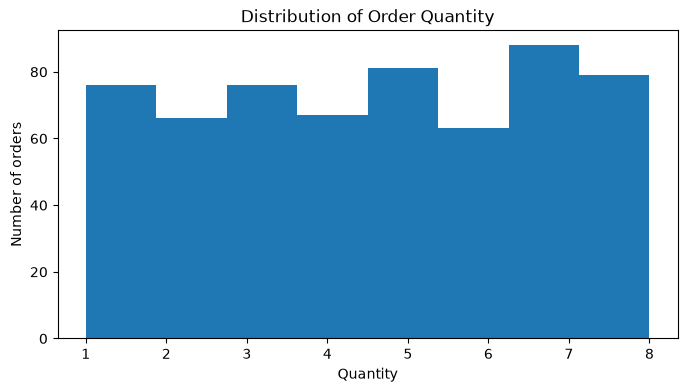

In [617]:
eda["quantity"].plot(
    kind="hist",
    bins=8,
    figsize=(8, 4),
    title="Distribution of Order Quantity"
)
plt.xlabel("Quantity")
plt.ylabel("Number of orders")
plt.show()
plt.close()

### Histogram — Net sales

A strongly right-skewed distribution is common in transaction data: many ordinary orders and a smaller number of high-value orders.

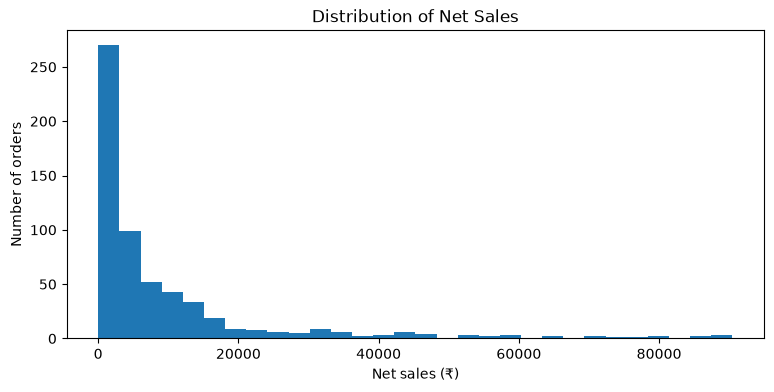

In [618]:
eda["net_sales"].plot(
    kind="hist",
    bins=30,
    figsize=(9, 4),
    title="Distribution of Net Sales"
)
plt.xlabel("Net sales (₹)")
plt.ylabel("Number of orders")
plt.show()
plt.close()

### Box plot — Net sales

Use a box plot to identify the central range and possible unusually large/small observations.

Remember: **a plotted outlier is a record to investigate, not automatically a record to delete.**

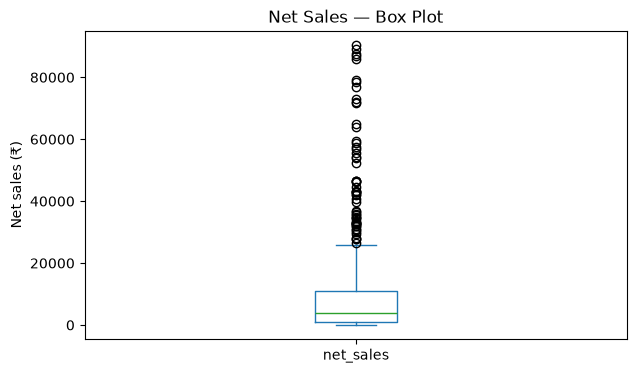

In [619]:
eda[["net_sales"]].plot(
    kind="box",
    figsize=(7, 4),
    title="Net Sales — Box Plot"
)
plt.ylabel("Net sales (₹)")
plt.show()
plt.close()

## Step 10 — Univariate EDA: categorical variables

For categorical data, start with frequencies.

Typical questions:

- Which cities generate the most orders?
- Which category is most common?
- Which payment method is used most?
- Which sales channel dominates?

In [620]:
for column in ["city", "segment", "category", "payment", "sales_channel", "returned"]:
    print(f"\n{column.upper()}")
    print(eda[column].value_counts())



CITY
city
Mumbai       167
Chennai      130
Delhi        126
Bengaluru     94
Hyderabad     79
Name: count, dtype: int64

SEGMENT
segment
Consumer          332
Corporate         148
Small Business    116
Name: count, dtype: int64

CATEGORY
category
Electronics    177
Office         161
Home           135
Accessories    123
Name: count, dtype: int64

PAYMENT
payment
UPI            267
CARD           214
CASH            68
NET BANKING     47
Name: count, dtype: int64

SALES_CHANNEL
sales_channel
Website       273
Mobile App    206
Store         117
Name: count, dtype: int64

RETURNED
returned
No     559
Yes     37
Name: count, dtype: int64


### Bar chart — Number of orders by city

Bars are useful for comparing categories because their lengths can be compared directly.

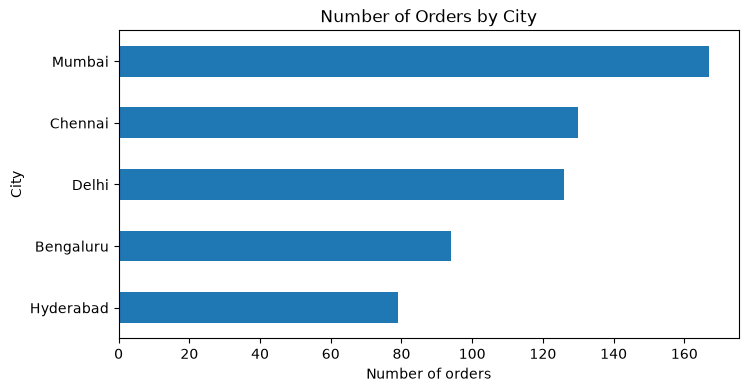

In [621]:
eda["city"].value_counts().sort_values().plot(
    kind="barh",
    figsize=(8, 4),
    title="Number of Orders by City"
)
plt.xlabel("Number of orders")
plt.ylabel("City")
plt.show()
plt.close()

### Bar chart — Order mix by category

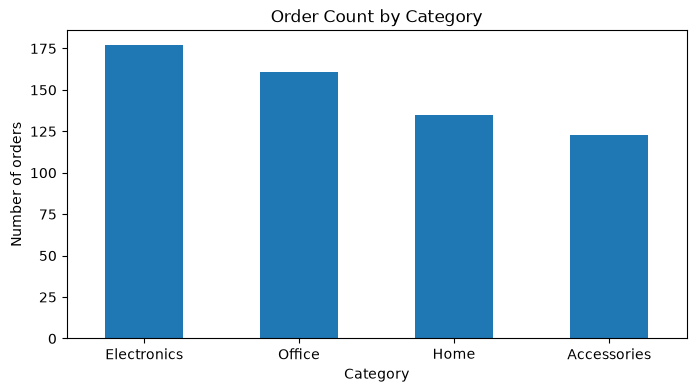

In [622]:
eda["category"].value_counts().plot(
    kind="bar",
    figsize=(8, 4),
    title="Order Count by Category"
)
plt.xlabel("Category")
plt.ylabel("Number of orders")
plt.xticks(rotation=0)
plt.show()
plt.close()

## Step 11 — Bivariate EDA: category vs numeric measure

Bivariate analysis asks:

**Does a numeric outcome differ between groups?**

A common example is comparing net sales across categories or cities.

In [623]:
category_sales = (
    eda.groupby("category", as_index=False)
       .agg(
           orders=("order_id", "nunique"),
           units=("quantity", "sum"),
           revenue=("net_sales", "sum"),
           average_order_value=("net_sales", "mean")
       )
       .sort_values("revenue", ascending=False)
)

category_sales

,category,orders,units,revenue,average_order_value
1,Electronics,177,824.0,2.936680e+06,16591.412601
2,Home,135,639.0,2.058109e+06,15245.248830
0,Accessories,123,556.0,5.155276e+05,4191.281340
3,Office,161,716.0,8.820481e+04,547.855976


### Visualization — Revenue by category

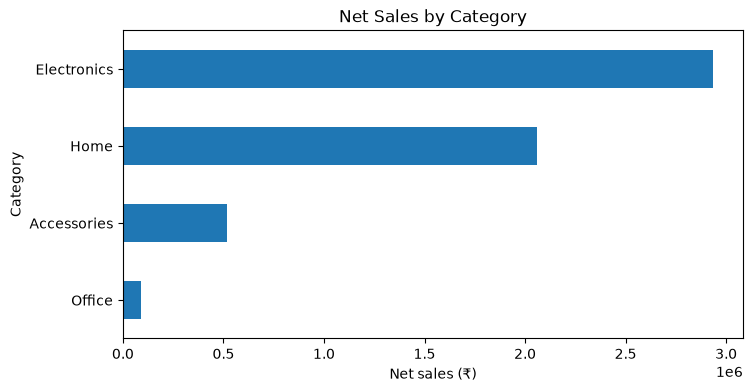

In [624]:
category_sales.set_index("category")["revenue"].sort_values().plot(
    kind="barh",
    figsize=(8, 4),
    title="Net Sales by Category"
)
plt.xlabel("Net sales (₹)")
plt.ylabel("Category")
plt.show()
plt.close()

### Box plot — Net sales by category

A group box plot compares both **central tendency and spread**.

Ask:

- Which category has the highest typical order value?
- Which category has more variation?
- Are there possible high-value orders?

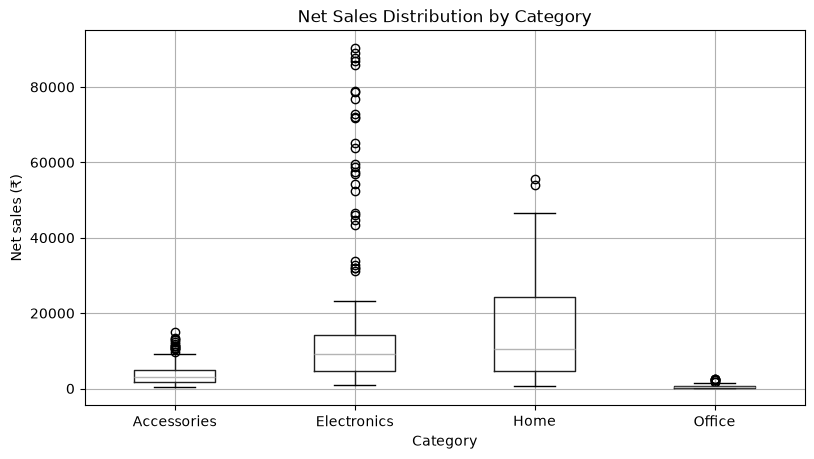

In [625]:
eda.boxplot(
    column="net_sales",
    by="category",
    figsize=(9, 5)
)
plt.title("Net Sales Distribution by Category")
plt.suptitle("")
plt.xlabel("Category")
plt.ylabel("Net sales (₹)")
plt.show()
plt.close()

## Step 12 — Bivariate EDA: city vs revenue

Averages alone can be misleading. Always consider **both volume and value**.

For example, a city can have fewer orders but still generate high revenue because its orders are larger.

In [626]:
city_summary = (
    eda.groupby("city", as_index=False)
       .agg(
           orders=("order_id", "nunique"),
           units=("quantity", "sum"),
           revenue=("net_sales", "sum"),
           average_order_value=("net_sales", "mean")
       )
       .sort_values("revenue", ascending=False)
)

city_summary

,city,orders,units,revenue,average_order_value
4,Mumbai,167,791.0,1.574967e+06,9430.941274
1,Chennai,130,607.0,1.170938e+06,9007.215165
0,Bengaluru,94,419.0,1.108611e+06,11793.731409
2,Delhi,126,568.0,1.079430e+06,8566.903480
3,Hyderabad,79,350.0,6.645753e+05,8412.345373


### Visual comparison — revenue by city

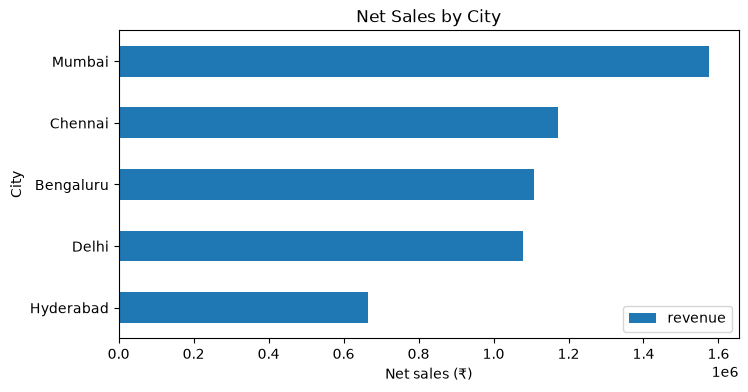

In [627]:
city_summary.set_index("city")[["revenue"]].sort_values("revenue").plot(
    kind="barh",
    figsize=(8, 4),
    title="Net Sales by City"
)
plt.xlabel("Net sales (₹)")
plt.ylabel("City")
plt.show()
plt.close()

## Step 13 — Multivariate EDA with a pivot table

A pivot table lets us compare **two categorical variables against a numeric measure**.

Question:

**How does each product category perform inside each city?**

In [628]:
city_category = pd.pivot_table(
    eda,
    index="city",
    columns="category",
    values="net_sales",
    aggfunc="sum",
    fill_value=0
).round(0)

city_category

category,Accessories,Electronics,Home,Office
city,,,,
Bengaluru,87104.0,512629.0,498077.0,10800.0
Chennai,121078.0,531522.0,499834.0,18503.0
Delhi,124860.0,572942.0,362949.0,18679.0
Hyderabad,64057.0,342150.0,248354.0,10014.0
Mumbai,118428.0,977437.0,448894.0,30208.0


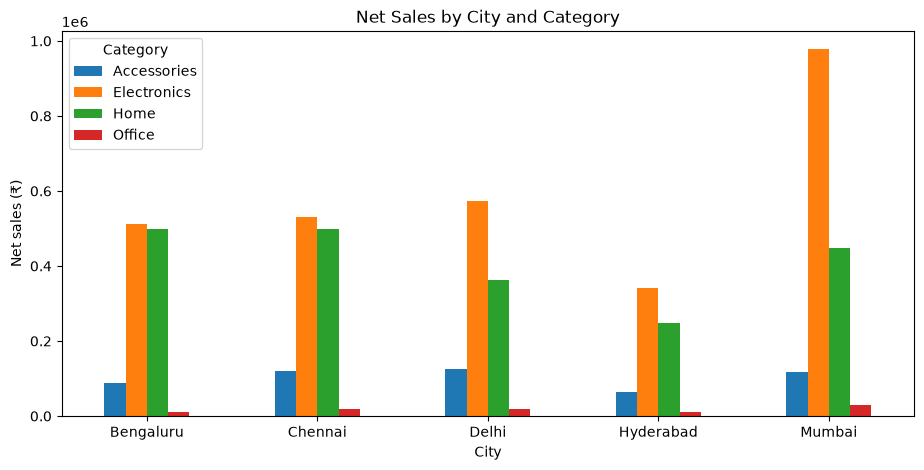

In [629]:
city_category.plot(
    kind="bar",
    figsize=(11, 5),
    title="Net Sales by City and Category"
)
plt.xlabel("City")
plt.ylabel("Net sales (₹)")
plt.xticks(rotation=0)
plt.legend(title="Category")
plt.show()
plt.close()

## Step 14 — Relationship analysis with a scatter plot

Scatter plots are useful when both variables are numeric.

Question:

**Do larger quantities tend to produce larger net sales?**

Do not expect a perfect straight line because unit prices vary between products.

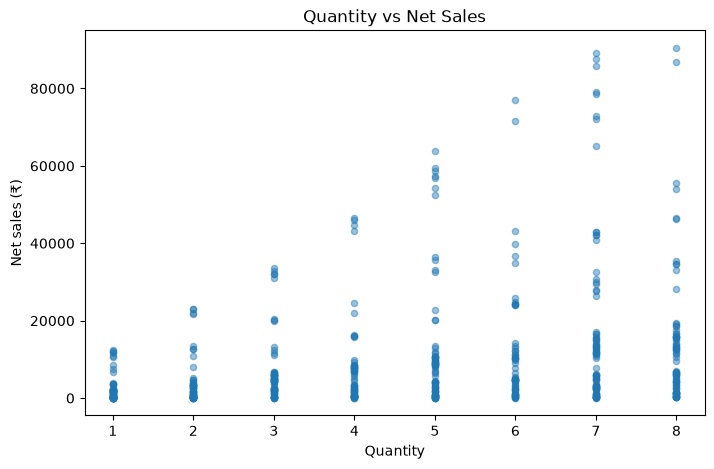

In [630]:
eda.plot.scatter(
    x="quantity",
    y="net_sales",
    figsize=(8, 5),
    alpha=0.45,
    title="Quantity vs Net Sales"
)
plt.xlabel("Quantity")
plt.ylabel("Net sales (₹)")
plt.show()
plt.close()

## Step 15 — Correlation

Correlation measures the strength and direction of a **linear association** between numeric variables.

It is useful for exploration, but:

**correlation ≠ causation**

A high correlation does not prove that one variable causes the other.

In [631]:
corr_cols = [
    "quantity", "unit_price", "discount",
    "shipping_days", "customer_rating",
    "gross_sales", "net_sales"
]

correlation = eda[corr_cols].corr().round(2)
correlation

,quantity,unit_price,discount,shipping_days,customer_rating,gross_sales,net_sales
quantity,1.00,-0.01,0.04,0.03,-0.03,0.30,0.30
unit_price,-0.01,1.00,0.00,0.01,-0.03,0.85,0.84
discount,0.04,0.00,1.00,-0.01,-0.05,0.02,-0.01
shipping_days,0.03,0.01,-0.01,1.00,0.03,-0.00,-0.00
customer_rating,-0.03,-0.03,-0.05,0.03,1.00,-0.04,-0.04
gross_sales,0.30,0.85,0.02,-0.00,-0.04,1.00,1.00
net_sales,0.30,0.84,-0.01,-0.00,-0.04,1.00,1.00


### Correlation heatmap with Matplotlib

The table above is the important analytical result. A heatmap is a visual summary that makes strong positive/negative relationships easier to scan.

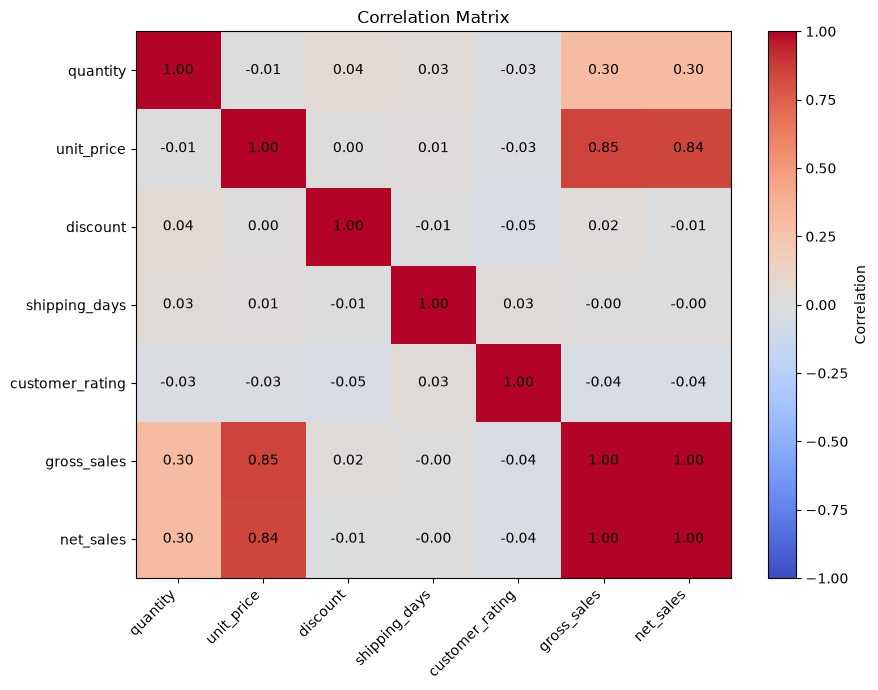

In [632]:
corr = correlation

fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(corr, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

fig.colorbar(image, ax=ax, label="Correlation")
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()
plt.close()

## Step 16 — Categorical relationships with `crosstab()`

A useful EDA question is:

**Does the return rate differ by category or sales channel?**

`crosstab(..., normalize="index")` converts counts into within-group percentages.

In [633]:
return_by_category = pd.crosstab(
    eda["category"],
    eda["returned"],
    normalize="index"
).mul(100).round(2)

return_by_category

returned,No,Yes
category,,
Accessories,93.50,6.50
Electronics,93.79,6.21
Home,94.81,5.19
Office,93.17,6.83


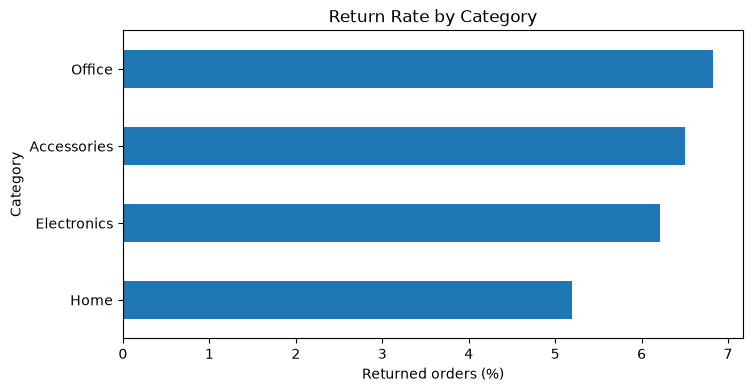

In [634]:
return_by_category["Yes"].sort_values().plot(
    kind="barh",
    figsize=(8, 4),
    title="Return Rate by Category"
)
plt.xlabel("Returned orders (%)")
plt.ylabel("Category")
plt.show()
plt.close()

## Step 17 — Time-series EDA

Dates are not just labels. Convert them into a proper datetime type and ask:

- How is revenue changing month by month?
- Are order volumes growing or falling?
- Does average order value change over time?

For transaction data, monthly aggregation is often a useful first view.

In [635]:
monthly_eda = (
    eda.set_index("order_date")
       .resample("ME")
       .agg(
           orders=("order_id", "nunique"),
           units=("quantity", "sum"),
           revenue=("net_sales", "sum")
       )
)

monthly_eda["average_order_value"] = (
    monthly_eda["revenue"] / monthly_eda["orders"]
)

monthly_eda.round(2)

,orders,units,revenue,average_order_value
order_date,,,,
2025-01-31,34,145.0,418543.33,12310.10
2025-02-28,45,206.0,344325.20,7651.67
2025-03-31,70,322.0,644133.44,9201.91
2025-04-30,45,223.0,530012.37,11778.05
2025-05-31,53,208.0,500555.66,9444.45
2025-06-30,51,213.0,520935.31,10214.42
2025-07-31,45,192.0,610027.82,13556.17
2025-08-31,52,265.0,531617.45,10223.41
2025-09-30,46,202.0,347743.18,7559.63


### Line chart — monthly revenue

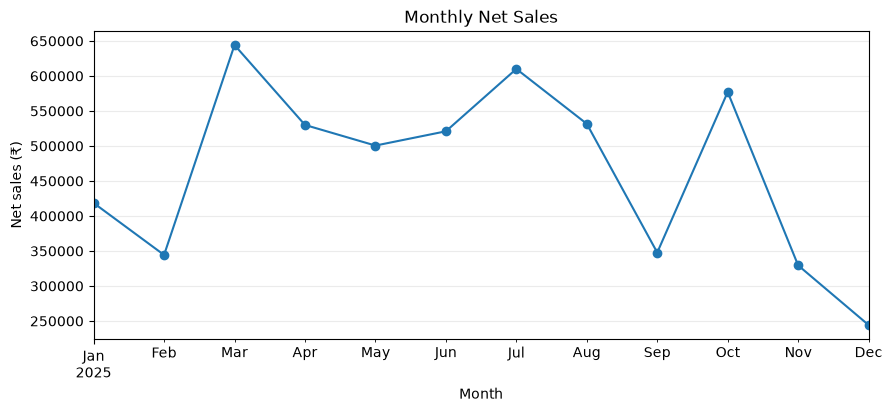

In [636]:
monthly_eda["revenue"].plot(
    kind="line",
    marker="o",
    figsize=(10, 4),
    title="Monthly Net Sales"
)
plt.xlabel("Month")
plt.ylabel("Net sales (₹)")
plt.grid(alpha=0.25)
plt.show()
plt.close()

### Line chart — monthly order volume

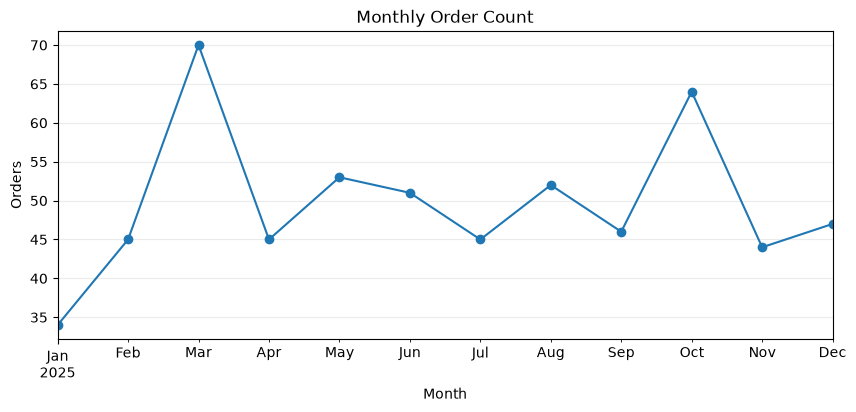

In [637]:
monthly_eda["orders"].plot(
    kind="line",
    marker="o",
    figsize=(10, 4),
    title="Monthly Order Count"
)
plt.xlabel("Month")
plt.ylabel("Orders")
plt.grid(alpha=0.25)
plt.show()
plt.close()

### Three-month rolling average

Rolling statistics help us see the underlying pattern without relying only on month-to-month noise.

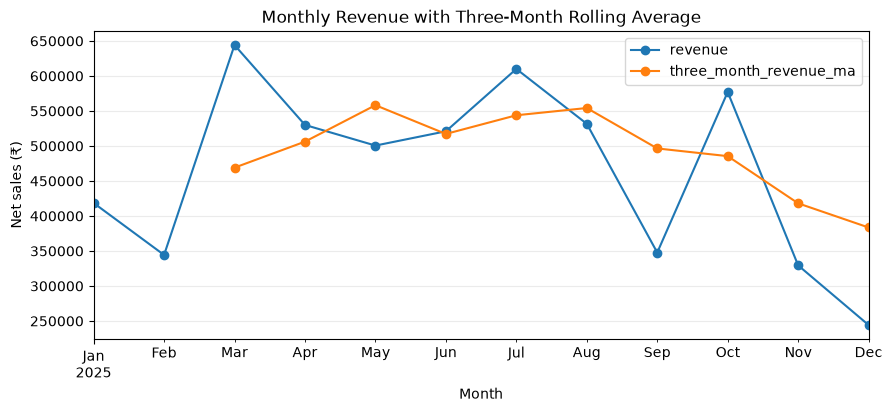

In [638]:
monthly_eda["three_month_revenue_ma"] = monthly_eda["revenue"].rolling(3).mean()

monthly_eda[["revenue", "three_month_revenue_ma"]].plot(
    kind="line",
    marker="o",
    figsize=(10, 4),
    title="Monthly Revenue with Three-Month Rolling Average"
)
plt.xlabel("Month")
plt.ylabel("Net sales (₹)")
plt.grid(alpha=0.25)
plt.show()
plt.close()

## Step 18 — Outlier analysis with the IQR rule

For a numeric variable:

`IQR = Q3 − Q1`

Lower fence:

`Q1 − 1.5 × IQR`

Upper fence:

`Q3 + 1.5 × IQR`

Records outside these fences are **potential outliers**.

Use this to investigate unusual data, not as an automatic deletion rule.

In [639]:
def iqr_summary(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return pd.Series({
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_fence": lower,
        "upper_fence": upper,
        "outlier_count": int(mask.sum()),
        "outlier_pct": round(mask.mean() * 100, 2)
    })

outlier_report = pd.DataFrame({
    col: iqr_summary(eda[col])
    for col in ["quantity", "unit_price", "shipping_days", "net_sales"]
}).T

outlier_report

,Q1,Q3,IQR,lower_fence,upper_fence,outlier_count,outlier_pct
quantity,3.000000,7.000000,4.000000,-3.000000,13.000000,0.0,0.00
unit_price,359.007500,2229.107500,1870.100000,-2446.142500,5034.257500,67.0,11.24
shipping_days,3.000000,6.000000,3.000000,-1.500000,10.500000,0.0,0.00
net_sales,957.735315,10926.847878,9969.112563,-13995.933529,25880.516721,57.0,9.56


### Inspect possible net-sales outliers

Always look at the records rather than deleting them blindly.

In [640]:
q1 = eda["net_sales"].quantile(0.25)
q3 = eda["net_sales"].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr

possible_outliers = (
    eda.loc[eda["net_sales"] > upper,
            ["order_id", "order_date", "city", "category", "product",
             "quantity", "unit_price", "net_sales"]]
      .sort_values("net_sales", ascending=False)
)

possible_outliers.head(10)

,order_id,order_date,city,category,product,quantity,unit_price,net_sales
87,5377,2025-03-05,Mumbai,Electronics,Monitor,8.0,12303.83,90457.75816
569,5028,2025-12-13,Mumbai,Electronics,Monitor,7.0,13345.52,89121.38256
332,5153,2025-07-25,Mumbai,Electronics,Monitor,7.0,12996.03,87606.23823
532,5359,2025-11-19,Delhi,Electronics,Monitor,8.0,12937.33,86938.85760
284,5571,2025-06-23,Mumbai,Electronics,Monitor,7.0,12339.29,85770.40479
329,5186,2025-07-20,Chennai,Electronics,Monitor,7.0,12157.39,78974.40544
2,5311,2025-01-02,Hyderabad,Electronics,Monitor,7.0,11666.80,78645.89880
236,5432,2025-05-27,Hyderabad,Electronics,Monitor,6.0,12816.72,76900.32000
327,5461,2025-07-17,Mumbai,Electronics,Monitor,7.0,11892.91,72927.32412
193,5163,2025-04-30,Bengaluru,Electronics,Monitor,7.0,11452.28,72149.36400


## Step 19 — Visualise missingness before cleaning

A missing-value chart is useful during the data-quality stage.

This chart should be based on the **raw dataset**, because cleaning may remove the evidence that something was missing.

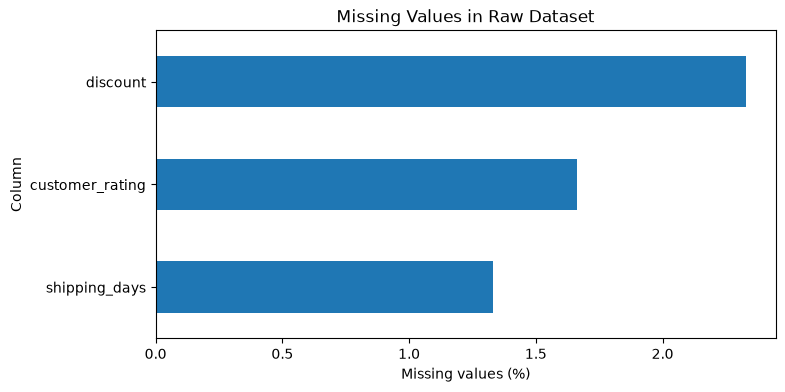

In [641]:
raw_missing_pct = (eda_raw.isna().mean() * 100).sort_values()

raw_missing_pct[raw_missing_pct > 0].plot(
    kind="barh",
    figsize=(8, 4),
    title="Missing Values in Raw Dataset"
)
plt.xlabel("Missing values (%)")
plt.ylabel("Column")
plt.show()
plt.close()

## Step 20 — Turn analysis into findings

A chart is not the final output.

A good EDA conclusion should state:

**Observation → evidence → possible business meaning**

For example:

> “City A generated the largest net sales, supported by its revenue total in the city summary. This suggests the city is an important market to investigate further; however, order volume and average order value should also be considered before deciding where to invest.”

The wording separates what the data shows from what management might investigate next.

In [642]:
# Programmatically extract a few factual findings from the EDA tables.

top_city = city_summary.iloc[0]
top_category = category_sales.iloc[0]
best_month = monthly_eda["revenue"].idxmax()
best_month_revenue = monthly_eda.loc[best_month, "revenue"]

return_rate = (
    eda["returned"].eq("Yes").mean() * 100
)

print(f"Top city by net sales: {top_city['city']} — ₹{top_city['revenue']:,.0f}")
print(f"Top category by net sales: {top_category['category']} — ₹{top_category['revenue']:,.0f}")
print(f"Highest-revenue month: {best_month.strftime('%B %Y')} — ₹{best_month_revenue:,.0f}")
print(f"Overall return rate: {return_rate:.2f}%")

Top city by net sales: Mumbai — ₹1,574,967
Top category by net sales: Electronics — ₹2,936,680
Highest-revenue month: March 2025 — ₹644,133
Overall return rate: 6.21%


## Choosing the right chart for the question

| Question | Recommended first chart |
|---|---|
| How does a measure change over time? | Line |
| Which categories are larger/smaller? | Bar / horizontal bar |
| What does one numeric variable look like? | Histogram |
| Are there possible extreme values? | Box plot |
| How do two numeric variables relate? | Scatter |
| How do two categorical variables combine? | Grouped/stacked bar or crosstab |
| How do many numeric variables relate? | Correlation matrix / heatmap |

A chart should answer a question. Avoid adding a chart simply because the library can create it.

## Common EDA mistakes

### 1. Plotting before understanding the columns
A visually attractive chart can still be based on the wrong measure.

### 2. Ignoring missing values
`mean()`, `count()` and plots may behave differently when values are missing.

### 3. Treating every outlier as an error
Investigate first.

### 4. Reporting correlation as causation
Correlation describes an association; it does not establish a causal relationship.

### 5. Looking only at averages
Always consider volume, spread, median and distribution.

### 6. Producing charts without a written interpretation
EDA is complete only when the analyst can explain what the evidence means and what should be investigated next.

## 📝 Class Practice — EDA Skills

Try these before looking at other cells.

### 🧩 Practice 103 — Data profile
Create a table containing dtype, missing count, missing percentage and unique values for every column.

### 🧩 Practice 104 — Numeric distribution
Choose `unit_price` or `net_sales`. Calculate descriptive statistics and draw a histogram.

### 🧩 Practice 105 — Group comparison
Calculate total net sales and average order value by `sales_channel`. Plot the revenue comparison.

### 🧩 Practice 106 — Relationship
Calculate the correlation between `quantity` and `net_sales`, then create a scatter plot and write one factual observation.

### 🧩 Practice 107 — Time trend
Create a monthly table containing orders, units, revenue and average order value. Plot monthly revenue.

### 🧩 Practice 108 — Outliers
Use the IQR rule to count potential outliers in `net_sales` and inspect the top five records.

**Challenge:** Write two evidence-based findings in complete sentences. Do not simply say “City X is best”; report the actual measure and value.

In [643]:
# Write your solution here.


In [644]:
# Write your solution here.


In [645]:
# Write your solution here.


In [646]:
# Write your solution here.


In [647]:
# Write your solution here.


In [648]:
# Write your solution here.


## EDA workflow to remember

**1. Understand the question**  
**2. Load the raw data**  
**3. Inspect structure**  
**4. Check data quality**  
**5. Clean carefully**  
**6. Profile numeric variables**  
**7. Profile categorical variables**  
**8. Compare groups**  
**9. Explore relationships**  
**10. Analyse time**  
**11. Investigate outliers**  
**12. Communicate findings and limitations**

This is the workflow we will apply again in the end-to-end project below.

# 2️⃣5️⃣ Reading & Writing Data — CSV, TSV, Excel, JSON, Parquet

A large part of data work is IO: getting data into Pandas and saving the result in a useful format.

### read_csv()

In [649]:
df = pd.read_csv(RAW / 'sales.csv')
print(df.head())

   order_id  order_date customer       city     category   product  quantity  \
0      1001  2026-01-03     Asha      Delhi  Electronics     Mouse         2   
1      1002  2026-01-04     Ravi     Mumbai       Office  Notebook         5   
2      1003  2026-01-05     Neha      Delhi  Electronics  Keyboard         1   
3      1004  2026-01-07     Amit  Bengaluru       Office       Pen        20   
4      1005  2026-01-09     Riya    Chennai  Electronics   Monitor         2   

   unit_price  discount payment  
0         900      0.05    Card  
1         120      0.00     UPI  
2        1800      0.10    Card  
3          25      0.02    Cash  
4       12500      0.08     UPI  


### TSV

Tab-separated files use `sep="\t"`.

In [650]:
tsv_path = RAW / 'demo.tsv'
tsv_path.write_text('name\tage\nA\t20\nB\t21\n', encoding='utf-8')
print(pd.read_csv(tsv_path, sep='\t'))

  name  age
0    A   20
1    B   21


### usecols

Load only the columns you need to reduce memory and parsing work.

In [651]:
print(pd.read_csv(RAW / 'sales.csv', usecols=['order_id', 'product', 'quantity']).head())

   order_id   product  quantity
0      1001     Mouse         2
1      1002  Notebook         5
2      1003  Keyboard         1
3      1004       Pen        20
4      1005   Monitor         2


### nrows

Load only a sample while developing.

In [652]:
print(pd.read_csv(RAW / 'sales.csv', nrows=3))

   order_id  order_date customer    city     category   product  quantity  \
0      1001  2026-01-03     Asha   Delhi  Electronics     Mouse         2   
1      1002  2026-01-04     Ravi  Mumbai       Office  Notebook         5   
2      1003  2026-01-05     Neha   Delhi  Electronics  Keyboard         1   

   unit_price  discount payment  
0         900      0.05    Card  
1         120      0.00     UPI  
2        1800      0.10    Card  


### skiprows

Skip source-file lines that contain metadata or unwanted rows.

In [653]:
messy = RAW / 'messy.csv'
messy.write_text('# report export\n# created by system\nname,score\nA,90\nB,80\n', encoding='utf-8')
print(pd.read_csv(messy, skiprows=2))

  name  score
0    A     90
1    B     80


### dtype on input

IDs such as `00123` should be read as strings so leading zeros are not lost.

In [654]:
ids_csv = RAW / 'ids.csv'
ids_csv.write_text('customer_id,name\n00123,Asha\n00124,Ravi\n', encoding='utf-8')
print(pd.read_csv(ids_csv, dtype={'customer_id': 'string'}))

  customer_id  name
0       00123  Asha
1       00124  Ravi


### na_values

Tell Pandas which custom markers represent missing values.

In [655]:
custom_missing = RAW / 'missing_markers.csv'
custom_missing.write_text('name,score\nA,90\nB,NA\nC,?\n', encoding='utf-8')
print(pd.read_csv(custom_missing, na_values=['NA', '?']))

  name  score
0    A   90.0
1    B    NaN
2    C    NaN


### parse dates

You can convert to datetime after reading or use the appropriate parser during ingestion.

In [656]:
df = pd.read_csv(RAW / 'sales.csv')
df['order_date'] = pd.to_datetime(df['order_date'])
print(df.dtypes['order_date'])

datetime64[us]


### Excel read/write

Excel support commonly uses `openpyxl`. If the engine is unavailable in a fresh environment, install it separately.

In [657]:
import openpyxl

In [658]:
excel_path = OUTPUT / 'sales_demo.xlsx'
sales.head(5).to_excel(excel_path, index=False)
loaded_excel = pd.read_excel(excel_path)
print(loaded_excel)

   order_id  order_date customer       city     category   product  quantity  \
0      1001  2026-01-03     Asha      Delhi  Electronics     Mouse         2   
1      1002  2026-01-04     Ravi     Mumbai       Office  Notebook         5   
2      1003  2026-01-05     Neha      Delhi  Electronics  Keyboard         1   
3      1004  2026-01-07     Amit  Bengaluru       Office       Pen        20   
4      1005  2026-01-09     Riya    Chennai  Electronics   Monitor         2   

   unit_price  discount payment  
0         900      0.05    Card  
1         120      0.00     UPI  
2        1800      0.10    Card  
3          25      0.02    Cash  
4       12500      0.08     UPI  


### JSON read/write

JSON can represent tabular data in several orientations. Records orientation is easy to understand.

In [659]:
json_path = OUTPUT / 'students.json'
students.to_json(json_path, orient='records', indent=2)
print(pd.read_json(json_path, orient='records'))

    Name  Age  Marks Branch
0  Rahul   20     85    CSE
1  Priya   21     92     IT
2   Amit   20     76    CSE
3   Neha   22     88    ECE


### Parquet

Parquet is a columnar format commonly used in analytics/data engineering. `pyarrow` is typically needed as the engine.

In [660]:
parquet_path = OUTPUT / 'sales_demo.parquet'
try:
    sales2.to_parquet(parquet_path, index=False)
    pq = pd.read_parquet(parquet_path)
    print(pq.head())
except ImportError:
    print('Parquet demo skipped: install pyarrow to run this cell.')

   order_id  order_date customer       city     category   product  quantity  \
0      1001  2026-01-03     Asha      Delhi  Electronics     Mouse         2   
1      1002  2026-01-04     Ravi     Mumbai       Office  Notebook         5   
2      1003  2026-01-05     Neha      Delhi  Electronics  Keyboard         1   
3      1004  2026-01-07     Amit  Bengaluru       Office       Pen        20   
4      1005  2026-01-09     Riya    Chennai  Electronics   Monitor         2   

   unit_price  discount payment  gross  net_sales product_upper  
0         900      0.05    Card   1800     1710.0         MOUSE  
1         120      0.00     UPI    600      600.0      NOTEBOOK  
2        1800      0.10    Card   1800     1620.0      KEYBOARD  
3          25      0.02    Cash    500      490.0           PEN  
4       12500      0.08     UPI  25000    23000.0       MONITOR  


### Compressed CSV

In [661]:
gz_path = OUTPUT / 'sales.csv.gz'
sales.to_csv(gz_path, index=False, compression='gzip')
print('Wrote:', gz_path.name)

Wrote: sales.csv.gz


### Export selected columns

In [662]:
sales[['order_id', 'product', 'quantity']].to_csv(OUTPUT / 'order_extract.csv', index=False)

## 📝 Class Practice — 2️⃣5️⃣ Reading & Writing Data — CSV, TSV, Excel, JSON, Parquet

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 107 — Easy

**Question:** Read a CSV file into a DataFrame.

💡 **Hint:** Use `pd.read_csv(...)`.

**Your task:** Write and run your own Pandas code in the cell below.

In [663]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 108 — Easy → Medium

**Question:** Save a cleaned DataFrame as a CSV without writing the index.

💡 **Hint:** Use `.to_csv(..., index=False)`.

**Your task:** Write and run your own Pandas code in the cell below.

In [664]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 109 — Easy

**Question:** Write a DataFrame to JSON and read it back.

💡 **Hint:** Use `.to_json()` and `pd.read_json()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [665]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 110 — Easy

**Question:** Write a DataFrame to an Excel file and read it back.

💡 **Hint:** Use `.to_excel()` and `pd.read_excel()`; Excel support may require an engine.

**Your task:** Write and run your own Pandas code in the cell below.

In [666]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 2️⃣6️⃣ Advanced CSV Ingestion & Large Files

For large or messy files, parsing choices can matter as much as the analysis itself.

### Converters

A converter can normalize a column during ingestion.

In [667]:
converter_file = RAW / 'converter.csv'
converter_file.write_text('name,phone\nA, +91-9999999999 \nB, +91-8888888888 \n', encoding='utf-8')
print(pd.read_csv(converter_file, converters={'phone': lambda x: x.strip().replace('-', '')}))

  name          phone
0    A  +919999999999
1    B  +918888888888


### Bad lines

For malformed input, decide whether to error, warn, skip, or use a callable handler depending on your version and requirements.

In [668]:
bad = RAW / 'bad.csv'
bad.write_text('a,b\n1,2\n3,4,5\n6,7\n', encoding='utf-8')
try:
    print(pd.read_csv(bad, on_bad_lines='warn'))
except Exception as e:
    print(type(e).__name__, e)

   a  b
0  1  2
1  6  7


C:\Users\niraj\AppData\Local\Temp\ipykernel_19768\2410226502.py:4: ParserWarning: Skipping line 3: expected 2 fields, saw 3

  print(pd.read_csv(bad, on_bad_lines='warn'))


### chunksize

`chunksize` returns an iterator of DataFrame chunks instead of loading the entire file at once.

In [669]:
total_units = 0
for chunk in pd.read_csv(RAW / 'sales.csv', chunksize=4):
    total_units += chunk['quantity'].sum()
print('Total units:', total_units)

Total units: 55


### Chunked aggregation

For large files, keep only the small state needed for your final result.

In [670]:
city_totals = {}
for chunk in pd.read_csv(RAW / 'sales.csv', chunksize=4):
    chunk['discount'] = chunk['discount'].fillna(0)
    chunk['net_sales'] = chunk['quantity'] * chunk['unit_price'] * (1 - chunk['discount'])
    grouped = chunk.groupby('city')['net_sales'].sum()
    for city, value in grouped.items():
        city_totals[city] = city_totals.get(city, 0) + value
print(city_totals)

{'Bengaluru': 3190.0, 'Delhi': 12480.0, 'Mumbai': 12110.0, 'Chennai': 25890.0}


### StringIO

Pandas can parse in-memory CSV text as well as files.

In [671]:
text = StringIO('name,score\nA,90\nB,80\n')
print(pd.read_csv(text))

  name  score
0    A     90
1    B     80


## 📝 Class Practice — 2️⃣6️⃣ Advanced CSV Ingestion & Large Files

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 111 — Easy → Medium

**Question:** Read only three columns from a CSV file.

💡 **Hint:** Use `usecols=[...]`.

**Your task:** Write and run your own Pandas code in the cell below.

In [672]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 112 — Easy

**Question:** Read a CSV in chunks and count the total number of rows.

💡 **Hint:** Use `pd.read_csv(..., chunksize=...)`.

**Your task:** Write and run your own Pandas code in the cell below.

In [673]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 113 — Easy

**Question:** Specify a data type for one CSV column during reading.

💡 **Hint:** Use the `dtype={...}` argument.

**Your task:** Write and run your own Pandas code in the cell below.

In [674]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 114 — Easy → Medium

**Question:** Read a CSV while parsing a date column as datetime.

💡 **Hint:** Use the appropriate datetime parsing option for your Pandas version.

**Your task:** Write and run your own Pandas code in the cell below.

In [675]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 2️⃣7️⃣ SQL & Database Workflows

Pandas can read SQL query results into DataFrames and write DataFrames back to SQL tables. SQLite is convenient for practice because Python includes `sqlite3`.

### Create a SQLite database

In [676]:
import sqlite3

db_path = OUTPUT / 'school.db'
conn = sqlite3.connect(db_path)
conn.execute('CREATE TABLE IF NOT EXISTS student (id INTEGER, name TEXT, marks INTEGER)')
conn.execute('DELETE FROM student')
conn.executemany('INSERT INTO student VALUES (?, ?, ?)', [(1, 'A', 85), (2, 'B', 92), (3, 'C', 76)])
conn.commit()

### read_sql_query()

In [677]:
students_sql = pd.read_sql_query('SELECT * FROM student WHERE marks >= 80', conn)
print(students_sql)

   id name  marks
0   1    A     85
1   2    B     92


### SQL aggregation

In [678]:
print(pd.read_sql_query('SELECT AVG(marks) AS avg_marks FROM student', conn))

   avg_marks
0  84.333333


### to_sql()

`to_sql()` writes a DataFrame to a SQL table. Use it when the database schema and write semantics are understood.

In [679]:
students_sql.to_sql('high_scorers', conn, if_exists='replace', index=False)
print(pd.read_sql_query('SELECT * FROM high_scorers', conn))
conn.close()

   id name  marks
0   1    A     85
1   2    B     92


## 📝 Class Practice — 2️⃣7️⃣ SQL & Database Workflows

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 115 — Easy

**Question:** Create an in-memory SQLite database and write a small DataFrame into a table.

💡 **Hint:** Use `sqlite3.connect(':memory:')` and `df.to_sql(...)`.

**Your task:** Write and run your own Pandas code in the cell below.

In [680]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 116 — Easy

**Question:** Read the table back into Pandas with a SQL query.

💡 **Hint:** Use `pd.read_sql_query(...)`.

**Your task:** Write and run your own Pandas code in the cell below.

In [681]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 117 — Easy → Medium

**Question:** Write a SQL query that selects only rows meeting a condition and load the result into Pandas.

💡 **Hint:** Pass the SQL string to `read_sql_query`.

**Your task:** Write and run your own Pandas code in the cell below.

In [682]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 2️⃣8️⃣ JSON, Nested Data & `json_normalize()`

APIs often return nested JSON rather than a flat table.

### Nested JSON

In [683]:
payload = [
    {'id': 1, 'name': 'A', 'address': {'city': 'Delhi', 'pin': 110001}},
    {'id': 2, 'name': 'B', 'address': {'city': 'Mumbai', 'pin': 400001}}
]
print(pd.json_normalize(payload))

   id name address.city  address.pin
0   1    A        Delhi       110001
1   2    B       Mumbai       400001


### Nested records

When a field contains a list of records, `record_path` can turn those nested records into rows.

In [684]:
payload = [
    {'order_id': 1, 'customer': 'A', 'items': [{'product': 'Mouse', 'qty': 2}, {'product': 'Pad', 'qty': 1}]},
    {'order_id': 2, 'customer': 'B', 'items': [{'product': 'Keyboard', 'qty': 1}]}
]
print(pd.json_normalize(payload, record_path='items', meta=['order_id', 'customer']))

    product  qty order_id customer
0     Mouse    2        1        A
1       Pad    1        1        A
2  Keyboard    1        2        B


## 📝 Class Practice — 2️⃣8️⃣ JSON, Nested Data & `json_normalize()`

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 118 — Easy

**Question:** Create a small list of dictionaries representing students and turn it into a DataFrame.

💡 **Hint:** Use `pd.DataFrame(list_of_dicts)`.

**Your task:** Write and run your own Pandas code in the cell below.

In [685]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 119 — Easy

**Question:** Create nested JSON where each student has an address dictionary and flatten it.

💡 **Hint:** Try `pd.json_normalize(...)`.

**Your task:** Write and run your own Pandas code in the cell below.

In [686]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 120 — Easy → Medium

**Question:** Extract selected fields from a nested JSON structure.

💡 **Hint:** Use the `record_path`/`meta` ideas after inspecting the nested structure.

**Your task:** Write and run your own Pandas code in the cell below.

In [687]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 2️⃣9️⃣ Method Chaining & Production-Style Workflows

Method chaining keeps a transformation pipeline close to the business logic. Use it when each step remains readable.

### Simple method chain

In [688]:
result = (pd.read_csv(RAW / 'sales.csv')
          .assign(discount=lambda d: d['discount'].fillna(0))
          .assign(net_sales=lambda d: d['quantity'] * d['unit_price'] * (1 - d['discount']))
          .query('net_sales > 1000')
          .loc[:, ['order_id', 'city', 'product', 'net_sales']]
          .sort_values('net_sales', ascending=False))
print(result)

    order_id       city   product  net_sales
4       1005    Chennai   Monitor    23000.0
7       1008      Delhi     Chair     8550.0
9       1010     Mumbai      Desk     6650.0
11      1012     Mumbai    Webcam     4500.0
6       1007    Chennai      Lamp     2890.0
8       1009  Bengaluru     Mouse     2700.0
0       1001      Delhi     Mouse     1710.0
2       1003      Delhi  Keyboard     1620.0


### pipe()

`pipe()` lets you insert a custom reusable function into a chain.

In [689]:
def add_revenue(df):
    return df.assign(revenue=df['quantity'] * df['unit_price'])

result = (sales[['order_id', 'quantity', 'unit_price']]
          .pipe(add_revenue))
print(result.head())

   order_id  quantity  unit_price  revenue
0      1001         2         900     1800
1      1002         5         120      600
2      1003         1        1800     1800
3      1004        20          25      500
4      1005         2       12500    25000


### Copy-on-Write friendly assignment

Modern Pandas uses Copy-on-Write. Prefer direct `.loc[...] = ...` assignment on the DataFrame you intend to modify rather than chained assignment.

In [690]:
df = pd.DataFrame({'score': [50, 80, 90], 'passed': [False, False, True]})
df.loc[df['score'] >= 75, 'passed'] = True
print(df)

   score  passed
0     50   False
1     80    True
2     90    True


### Explicit copy when you intend a separate object

In [691]:
subset = sales.loc[sales['city'].eq('Delhi'), ['order_id', 'quantity', 'unit_price']].copy()
subset['gross_sales'] = subset['quantity'] * subset['unit_price']
subset['gross_sales'] = subset['gross_sales'] * 2
print('Subset after modification:\n', subset)

Subset after modification:
     order_id  quantity  unit_price  gross_sales
0       1001         2         900         3600
2       1003         1        1800         3600
7       1008         2        4500        18000
10      1011        10          60         1200


## 📝 Class Practice — 2️⃣9️⃣ Method Chaining & Production-Style Workflows

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 121 — Easy

**Question:** Write one chained expression that filters sales, sorts them by amount, and selects three columns.

💡 **Hint:** Use parentheses and chain one method per line.

**Your task:** Write and run your own Pandas code in the cell below.

In [692]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 122 — Easy

**Question:** Use `assign()` inside a method chain to create a sales column.

💡 **Hint:** Keep the workflow readable across multiple lines.

**Your task:** Write and run your own Pandas code in the cell below.

In [693]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 123 — Easy → Medium

**Question:** Use `query()` inside a method chain to keep only rows with quantity greater than 2.

💡 **Hint:** Write the condition as a string.

**Your task:** Write and run your own Pandas code in the cell below.

In [694]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 3️⃣0️⃣ Validation, Reproducibility & Data Quality

Good analysis is not only about getting an answer; it is about knowing the answer is based on valid input.

### Required columns

In [695]:
required = {'order_id', 'order_date', 'customer', 'city', 'quantity', 'unit_price'}
missing = required - set(sales.columns)
if missing:
    raise ValueError(f'Missing required columns: {missing}')
print('Schema check passed')

Schema check passed


### Uniqueness check

In [696]:
print('Unique order IDs:', sales['order_id'].is_unique)
print('Duplicate order IDs:', sales['order_id'].duplicated().sum())

Unique order IDs: True
Duplicate order IDs: 0


### Range checks

In [697]:
checks = {
    'quantity_positive': sales['quantity'].gt(0).all(),
    'unit_price_nonnegative': sales['unit_price'].ge(0).all(),
    'discount_0_to_1': sales['discount'].fillna(0).between(0, 1).all(),
}
print(checks)

{'quantity_positive': np.True_, 'unit_price_nonnegative': np.True_, 'discount_0_to_1': np.True_}


### Business-key duplicates

Sometimes one column is not enough. A business key may be a combination of columns.

In [698]:
print(sales.duplicated(subset=['customer', 'order_date', 'product']).sum())

0


### Reproducible sampling

`random_state` gives repeatable random results.

In [699]:
print(sales.sample(3, random_state=42))

    order_id  order_date customer    city     category product  quantity  \
10      1011  2026-02-02     Asha   Delhi       Office  Marker        10   
9       1010  2026-01-21     Arun  Mumbai       Office    Desk         1   
0       1001  2026-01-03     Asha   Delhi  Electronics   Mouse         2   

    unit_price  discount payment  
10          60      0.00     UPI  
9         7000      0.05    Cash  
0          900      0.05    Card  


### A simple data-quality report

In [700]:
quality = pd.DataFrame({
    'dtype': sales.dtypes.astype(str),
    'missing_count': sales.isna().sum(),
    'missing_pct': sales.isna().mean().mul(100).round(2),
    'nunique': sales.nunique(dropna=True)
})
print(quality)

              dtype  missing_count  missing_pct  nunique
order_id      int64              0         0.00       12
order_date      str              0         0.00       12
customer        str              0         0.00       10
city            str              0         0.00        4
category        str              0         0.00        3
product         str              0         0.00       10
quantity      int64              0         0.00        7
unit_price    int64              0         0.00       10
discount    float64              1         8.33        6
payment         str              0         0.00        3


## 📝 Class Practice — 3️⃣0️⃣ Validation, Reproducibility & Data Quality

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 124 — Easy

**Question:** Check that an ID column is unique.

💡 **Hint:** Use `.is_unique`.

**Your task:** Write and run your own Pandas code in the cell below.

In [701]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 125 — Easy

**Question:** Check whether a DataFrame contains any missing values at all.

💡 **Hint:** Use `.isna().any().any()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [702]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 126 — Easy → Medium

**Question:** Create a simple validation check that all quantities are non-negative.

💡 **Hint:** Use a boolean condition and `.all()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [703]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 127 — Easy

**Question:** Create a small data-quality summary showing null count and unique count for each column.

💡 **Hint:** Use `.isna().sum()` and `.nunique()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [704]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 3️⃣1️⃣ Pandas 3.x — Modern Behavior You Must Know


Your original notebook already included version awareness. This section makes the modern behavior explicit because students often learn older tutorials online.

### Important Pandas 3.0 changes
- String data now has a dedicated default `str` dtype rather than using NumPy `object` by default.
- Copy-on-Write is now the default/only behavior, making mutation of derived objects more predictable and removing the old confusing copy/view model.
- `DataFrame.map()` is the current DataFrame-level elementwise mapping API; older tutorials may show `applymap()`.
- `merge()` supports `left_anti` and `right_anti` joins in Pandas 3.0.
- Pandas can use PyArrow-backed dtypes and Arrow-aware IO for some workflows.

The official Pandas documentation and migration guides should be checked when code must remain compatible across major versions.

### Default string dtype

On Pandas 3.x, string data is inferred to the dedicated string dtype. Exact displayed dtype details can depend on the environment/backing implementation.

In [705]:
s = pd.Series(['A', 'B', None])
print(s)
print('dtype:', s.dtype)
print('is string dtype:', pd.api.types.is_string_dtype(s.dtype))

0      A
1      B
2    NaN
dtype: str
dtype: str
is string dtype: True


### Copy-on-Write demonstration

Changing a separately created derived Series/DataFrame should not unexpectedly mutate the original under modern Pandas behavior.

In [706]:
df = pd.DataFrame({'score': [10, 20, 30]})
subset = df['score']
subset.iloc[0] = 999
print('Original DataFrame:\n', df)
print('Subset:\n', subset)

Original DataFrame:
    score
0     10
1     20
2     30
Subset:
 0    999
1     20
2     30
Name: score, dtype: int64


### Modern DataFrame.map()

In [707]:
df = pd.DataFrame({'a': [1, 2], 'b': [3, 4]})
print(df.map(lambda x: f'value={x}'))

         a        b
0  value=1  value=3
1  value=2  value=4


### Modern anti join

In [708]:
all_ids = pd.DataFrame({'id': [1, 2, 3, 4]})
known_ids = pd.DataFrame({'id': [2, 4]})

if tuple(map(int, pd.__version__.split('.')[:2])) >= (3, 0):
    print(all_ids.merge(known_ids, on='id', how='left_anti'))
else:
    print('Pandas < 3 fallback:')
    print(all_ids[~all_ids['id'].isin(known_ids['id'])])

   id
0   1
2   3


### pd.col() in Pandas 3.x

`pd.col()` is a modern expression helper for some `assign` workflows. Keep a version check when teaching mixed-version environments.

In [709]:
if hasattr(pd, 'col'):
    df = pd.DataFrame({'qty': [2, 3], 'price': [10, 20]})
    print(df.assign(total=pd.col('qty') * pd.col('price')))
else:
    print('pd.col is not available in this Pandas version; use assign(total=lambda d: d.qty * d.price).')

   qty  price  total
0    2     10     20
1    3     20     60


### PyArrow-backed nullable dtypes

PyArrow can extend Pandas dtypes and IO capabilities. This is an advanced topic; install `pyarrow` only when you need the Arrow backend.

In [710]:
try:
    import pyarrow as pa
    df = pd.DataFrame({'id': [1, 2, None], 'name': ['A', 'B', None]}).convert_dtypes(dtype_backend='pyarrow')
    print(df)
    print(df.dtypes)
except ImportError:
    print('PyArrow not installed; skip this optional demo.')

     id  name
0     1     A
1     2     B
2  <NA>  <NA>
id       int64[pyarrow]
name    string[pyarrow]
dtype: object


## 📝 Class Practice — 3️⃣1️⃣ Pandas 3.x — Modern Behavior You Must Know

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 128 — Easy

**Question:** Inspect the dtype of a simple text Series in your installed Pandas version.

💡 **Hint:** Create `pd.Series(['a', 'b', None])` and inspect `.dtype`.

**Your task:** Write and run your own Pandas code in the cell below.

In [711]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 129 — Easy → Medium

**Question:** Create a DataFrame and demonstrate that `.copy()` creates an independent copy before making a change.

💡 **Hint:** Compare the original and copied DataFrames.

**Your task:** Write and run your own Pandas code in the cell below.

In [712]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 130 — Easy

**Question:** Use `pd.col()` inside `assign()` to create a derived column, if your installed Pandas version supports it.

💡 **Hint:** Check `hasattr(pd, 'col')` first if needed.

**Your task:** Write and run your own Pandas code in the cell below.

In [713]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 3️⃣2️⃣ Performance, Memory & Scaling

Pandas is powerful, but good Pandas code also means understanding memory and avoiding unnecessary Python-level work.

### Compare vectorized vs row-wise thinking

The exact timing depends on hardware and data size; the lesson is to prefer column operations when a direct vectorized expression exists.

In [714]:
n = 100_000
df = pd.DataFrame({'a': np.arange(n), 'b': np.arange(n) * 2})

# Vectorized
df['sum_vectorized'] = df['a'] + df['b']

print(df[['a', 'b', 'sum_vectorized']].head())

   a  b  sum_vectorized
0  0  0               0
1  1  2               3
2  2  4               6
3  3  6               9
4  4  8              12


### Memory usage

In [715]:
big = pd.DataFrame({
    'city': ['Delhi', 'Mumbai', 'Chennai', 'Delhi'] * 10_000,
    'value': np.arange(40_000)
})
print(big.memory_usage(deep=True))
print('Total MB:', big.memory_usage(deep=True).sum() / 1024**2)

Index       132
city     550000
value    320000
dtype: int64
Total MB: 0.8298225402832031


### Category can help repeated labels

Categorical data can reduce memory for low-cardinality repeated labels, although you should measure on your real data.

In [716]:
before = big.memory_usage(deep=True).sum()
big2 = big.copy()
big2['city'] = big2['city'].astype('category')
after = big2.memory_usage(deep=True).sum()
print('Before MB:', before / 1024**2)
print('After  MB:', after / 1024**2)

Before MB: 0.8298225402832031
After  MB: 0.3434896469116211


### Downcast numbers carefully

Downcasting can reduce memory when the value range fits. Always validate results.

In [717]:
nums = pd.Series([1, 2, 3, 4, 5], dtype='int64')
down = pd.to_numeric(nums, downcast='integer')
print(nums.dtype, '->', down.dtype)

int64 -> int8


### Chunk processing pattern

For very large files, process chunks and accumulate compact summaries rather than concatenating everything unnecessarily.

In [718]:
def total_by_city(path, chunksize=100_000):
    result = {}
    for chunk in pd.read_csv(path, chunksize=chunksize):
        chunk['discount'] = chunk['discount'].fillna(0)
        chunk['net_sales'] = chunk['quantity'] * chunk['unit_price'] * (1 - chunk['discount'])
        grouped = chunk.groupby('city')['net_sales'].sum()
        for city, value in grouped.items():
            result[city] = result.get(city, 0) + value
    return pd.Series(result).sort_values(ascending=False)

print(total_by_city(RAW / 'sales.csv', chunksize=4))

Chennai      25890.0
Delhi        12480.0
Mumbai       12110.0
Bengaluru     3190.0
dtype: float64


## 📝 Class Practice — 3️⃣2️⃣ Performance, Memory & Scaling

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 131 — Easy

**Question:** Check the memory usage of each column in a DataFrame.

💡 **Hint:** Use `df.memory_usage(deep=True)`.

**Your task:** Write and run your own Pandas code in the cell below.

In [719]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 132 — Easy → Medium

**Question:** Compare the memory usage before and after converting a repeated text column to `category`.

💡 **Hint:** Use `.memory_usage(deep=True).sum()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [720]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 133 — Easy

**Question:** Select only the columns needed for an analysis instead of carrying the whole DataFrame.

💡 **Hint:** Create a small list of required columns.

**Your task:** Write and run your own Pandas code in the cell below.

In [721]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 3️⃣3️⃣ End-to-End Project 1 — E-Commerce Sales EDA

## Business scenario

An e-commerce company has provided a raw order-level dataset and wants an initial analytical review before making decisions about products, markets and customer segments.

You are the data analyst.

Your job is to move from **raw data → cleaned dataset → EDA → visual evidence → findings → recommendations for further investigation**.

### Business questions

1. Which cities and categories generate the most revenue?
2. What does the order-value distribution look like?
3. How do customer segments and sales channels differ?
4. How does revenue change over time?
5. Which values need data-quality investigation?
6. Which relationships are visible in the data?
7. What evidence should be included in a short management report?

### Project deliverables

At the end of the project you should have:

- a cleaned analysis dataset
- a data-quality summary
- a KPI summary
- at least five meaningful visualisations
- an outlier report
- a monthly trend table
- a short set of evidence-based findings
- practical next-step recommendations

## Project Step 1 — Load and profile the raw dataset

In [722]:
# Start from the raw source
project_raw = pd.read_csv(RAW / "eda_sales.csv")

print("Shape:", project_raw.shape)
print("\nColumn data types:")
print(project_raw.dtypes)
print("\nFirst five rows:")
print(project_raw.head())

project_profile = pd.DataFrame({
    "dtype": project_raw.dtypes.astype(str),
    "missing": project_raw.isna().sum(),
    "missing_pct": (project_raw.isna().mean() * 100).round(2),
    "unique": project_raw.nunique(dropna=True)
})

project_profile

Shape: (601, 16)

Column data types:
order_id             int64
order_date             str
customer_id            str
customer               str
city                   str
segment                str
category               str
product                str
quantity           float64
unit_price         float64
discount           float64
payment                str
sales_channel          str
shipping_days      float64
customer_rating    float64
returned               str
dtype: object

First five rows:
   order_id  order_date customer_id      customer       city         segment  \
0      5354  2025-01-02        C018  Customer_018    Chennai        Consumer   
1      5337  2025-01-02        C006  Customer_006  Hyderabad        Consumer   
2      5311  2025-01-02        C012  Customer_012  Hyderabad  Small Business   
3      5519  2025-01-03        C116  Customer_116  Hyderabad  Small Business   
4      5256  2025-01-06        C081  Customer_081     Mumbai       Corporate   

      category    

,dtype,missing,missing_pct,unique
order_id,int64,0,0.00,599
order_date,str,0,0.00,290
customer_id,str,0,0.00,120
customer,str,0,0.00,120
city,str,0,0.00,6
segment,str,0,0.00,3
category,str,0,0.00,4
product,str,0,0.00,18
quantity,float64,0,0.00,9
unit_price,float64,0,0.00,596


## Project Step 2 — Diagnose data quality

Create a compact audit before making any changes.

The purpose is to record what was wrong with the raw data and justify the cleaning actions.

In [723]:
audit = pd.DataFrame({
    "missing_count": project_raw.isna().sum(),
    "missing_pct": (project_raw.isna().mean() * 100).round(2),
    "unique_values": project_raw.nunique(dropna=True)
})

audit = audit.sort_values("missing_pct", ascending=False)

print("Exact duplicate rows:", project_raw.duplicated().sum())
print("Duplicate order IDs:", project_raw["order_id"].duplicated().sum())
print("Invalid quantities:", (project_raw["quantity"] <= 0).sum())
print("Suspicious prices:", (project_raw["unit_price"] > 50_000).sum())

audit

Exact duplicate rows: 1
Duplicate order IDs: 2
Invalid quantities: 3
Suspicious prices: 2


,missing_count,missing_pct,unique_values
discount,14,2.33,181
customer_rating,10,1.66,4
shipping_days,8,1.33,10
order_id,0,0.00,599
city,0,0.00,6
order_date,0,0.00,290
customer_id,0,0.00,120
customer,0,0.00,120
product,0,0.00,18
category,0,0.00,4


## Project Step 3 — Clean and validate

Keep a clear distinction between:

- **correction of known data-quality problems**
- **investigation of unusual but potentially valid observations**

The aim is not to manufacture a perfectly shaped dataset. It is to make the analytical assumptions explicit.

In [724]:
df = project_raw.copy()

# Convert and standardise
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["city"] = df["city"].str.strip().str.title()
df["payment"] = df["payment"].str.strip().str.upper()
df["sales_channel"] = df["sales_channel"].str.strip().str.title()

# Remove exact duplicates and duplicate order IDs
df = df.drop_duplicates()
df = df.drop_duplicates(subset="order_id", keep="first")

# Remove impossible orders
df = df[df["quantity"].gt(0)].copy()

# Correct clearly suspicious prices using product-level median
df.loc[df["unit_price"] > 50_000, "unit_price"] = np.nan
df["unit_price"] = df.groupby("product")["unit_price"].transform(
    lambda s: s.fillna(s.median())
)

# Handle missing values with explicit rules
df["discount"] = df["discount"].fillna(0)
df["shipping_days"] = df.groupby("city")["shipping_days"].transform(
    lambda s: s.fillna(s.median())
)
df["customer_rating"] = df["customer_rating"].fillna(df["customer_rating"].median())

df = df.dropna(subset=["order_date", "unit_price"])
df = df.sort_values("order_date").reset_index(drop=True)

# Business measures
df["gross_sales"] = df["quantity"] * df["unit_price"]
df["discount_amount"] = df["gross_sales"] * df["discount"]
df["net_sales"] = df["gross_sales"] - df["discount_amount"]

assert df["order_id"].is_unique
assert df["quantity"].gt(0).all()
assert df["discount"].between(0, 0.25).all()

print("Cleaned shape:", df.shape)
print("Validation passed.")

Cleaned shape: (596, 19)
Validation passed.


## Project Step 4 — KPI summary

Create a small set of numbers that describe the overall dataset before moving into detailed findings.

In [725]:
kpis = pd.DataFrame({
    "metric": [
        "Total orders",
        "Total units",
        "Gross sales",
        "Discounts",
        "Net sales",
        "Average order value",
        "Return rate"
    ],
    "value": [
        df["order_id"].nunique(),
        df["quantity"].sum(),
        df["gross_sales"].sum(),
        df["discount_amount"].sum(),
        df["net_sales"].sum(),
        df["net_sales"].mean(),
        df["returned"].eq("Yes").mean() * 100
    ]
})

kpis

,metric,value
0,Total orders,5.960000e+02
1,Total units,2.735000e+03
2,Gross sales,6.101654e+06
3,Discounts,5.031328e+05
4,Net sales,5.598521e+06
5,Average order value,9.393492e+03
6,Return rate,6.208054e+00


## Project Step 5 — Univariate analysis

Start by understanding distributions before comparing groups.

Use descriptive statistics plus at least two distribution plots.

       quantity  unit_price  discount  shipping_days  customer_rating  \
count    596.00      596.00    596.00         596.00           596.00   
mean       4.59     2244.66      0.08           4.45             3.95   
std        2.32     3123.57      0.05           1.77             0.78   
min        1.00       22.39      0.00           1.00             2.00   
25%        3.00      359.01      0.04           3.00             3.00   
50%        5.00     1225.53      0.08           4.00             4.00   
75%        7.00     2229.11      0.12           6.00             5.00   
max        8.00    13345.52      0.23          10.00             5.00   

       net_sales  
count     596.00  
mean     9393.49  
std     15040.71  
min        22.46  
25%       957.74  
50%      3832.93  
75%     10926.85  
max     90457.76  


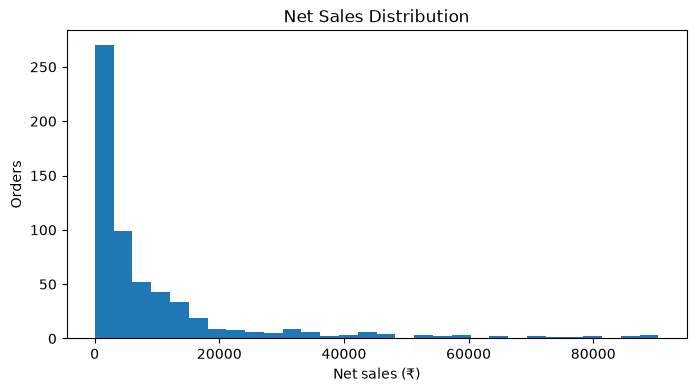

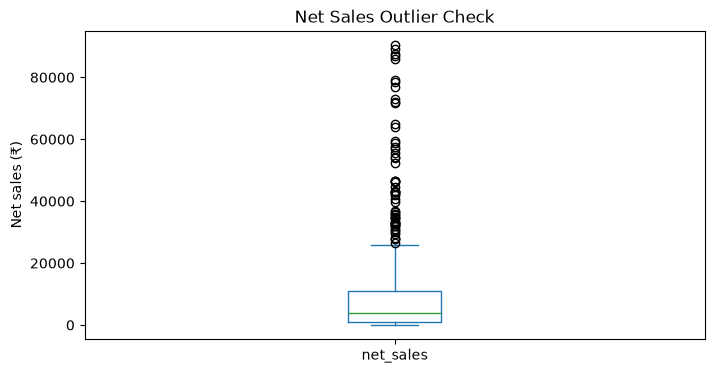

In [726]:
print(df[[
    "quantity", "unit_price", "discount",
    "shipping_days", "customer_rating", "net_sales"
]].describe().round(2))

fig = plt.figure(figsize=(8, 4))
df["net_sales"].plot(kind="hist", bins=30, title="Net Sales Distribution")
plt.xlabel("Net sales (₹)")
plt.ylabel("Orders")
plt.show()
plt.close()

df[["net_sales"]].plot(
    kind="box",
    figsize=(8, 4),
    title="Net Sales Outlier Check"
)
plt.ylabel("Net sales (₹)")
plt.show()
plt.close()

## Project Step 6 — Category and city analysis

Compare both revenue and order volume.

A useful report should not rely on one metric only.

In [727]:
category_summary = (
    df.groupby("category", as_index=False)
      .agg(
          orders=("order_id", "nunique"),
          units=("quantity", "sum"),
          revenue=("net_sales", "sum"),
          average_order_value=("net_sales", "mean")
      )
      .sort_values("revenue", ascending=False)
)

city_summary = (
    df.groupby("city", as_index=False)
      .agg(
          orders=("order_id", "nunique"),
          units=("quantity", "sum"),
          revenue=("net_sales", "sum"),
          average_order_value=("net_sales", "mean")
      )
      .sort_values("revenue", ascending=False)
)

print("Category summary")
print(category_summary)

print("\nCity summary")
print(city_summary)

Category summary
      category  orders  units       revenue  average_order_value
1  Electronics     177  824.0  2.936680e+06         16591.412601
2         Home     135  639.0  2.058109e+06         15245.248830
0  Accessories     123  556.0  5.155276e+05          4191.281340
3       Office     161  716.0  8.820481e+04           547.855976

City summary
        city  orders  units       revenue  average_order_value
4     Mumbai     167  791.0  1.574967e+06          9430.941274
1    Chennai     130  607.0  1.170938e+06          9007.215165
0  Bengaluru      94  419.0  1.108611e+06         11793.731409
2      Delhi     126  568.0  1.079430e+06          8566.903480
3  Hyderabad      79  350.0  6.645753e+05          8412.345373


### Visual evidence — category and city revenue

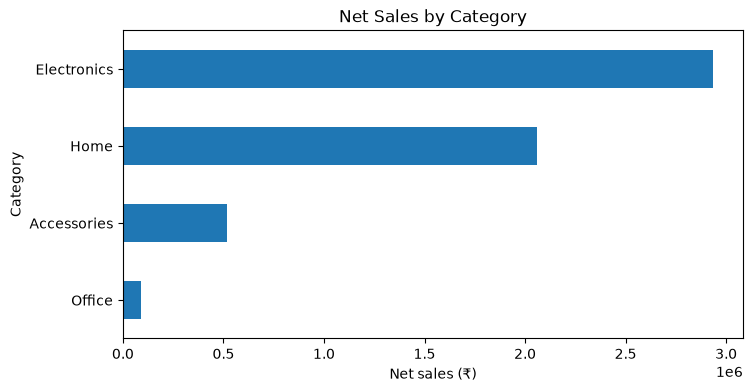

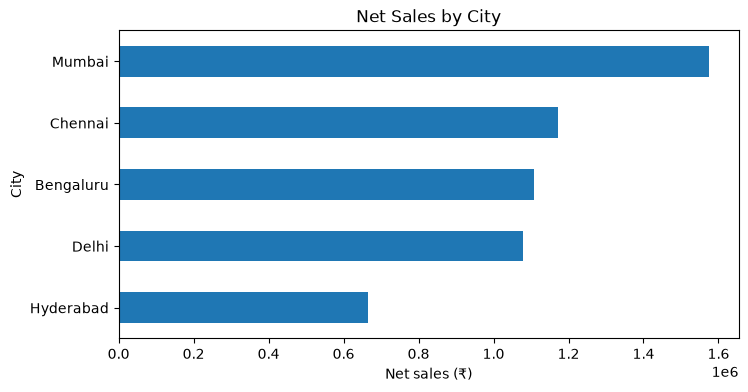

In [728]:
category_summary.set_index("category")["revenue"].sort_values().plot(
    kind="barh",
    figsize=(8, 4),
    title="Net Sales by Category"
)
plt.xlabel("Net sales (₹)")
plt.ylabel("Category")
plt.show()
plt.close()

city_summary.set_index("city")["revenue"].sort_values().plot(
    kind="barh",
    figsize=(8, 4),
    title="Net Sales by City"
)
plt.xlabel("Net sales (₹)")
plt.ylabel("City")
plt.show()
plt.close()

## Project Step 7 — Segment and sales-channel analysis

In [729]:
segment_channel = pd.pivot_table(
    df,
    index="segment",
    columns="sales_channel",
    values="net_sales",
    aggfunc="sum",
    fill_value=0
).round(0)

segment_channel

sales_channel,Mobile App,Store,Website
segment,,,
Consumer,1143459.0,535820.0,1555857.0
Corporate,413333.0,211909.0,644783.0
Small Business,301876.0,212543.0,578942.0


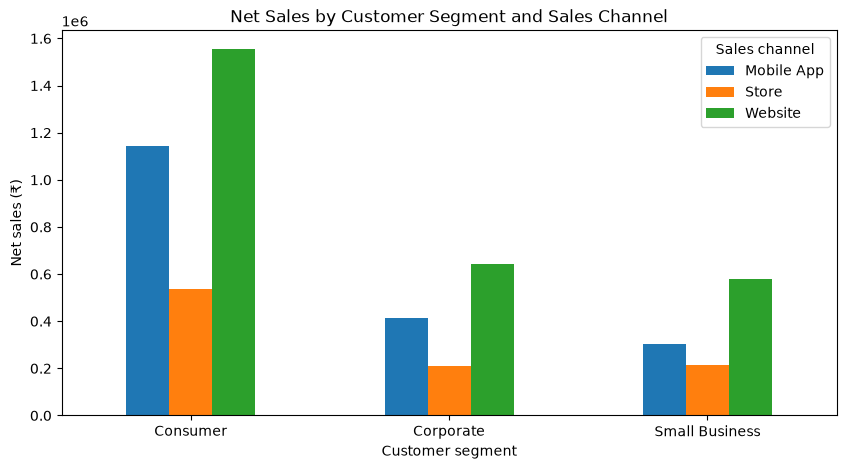

In [730]:
segment_channel.plot(
    kind="bar",
    figsize=(10, 5),
    title="Net Sales by Customer Segment and Sales Channel"
)
plt.xlabel("Customer segment")
plt.ylabel("Net sales (₹)")
plt.xticks(rotation=0)
plt.legend(title="Sales channel")
plt.show()
plt.close()

## Project Step 8 — Time-series analysis

Build one monthly table that can feed both analysis and a future dashboard.

In [731]:
monthly = (
    df.set_index("order_date")
      .resample("ME")
      .agg(
          orders=("order_id", "nunique"),
          units=("quantity", "sum"),
          revenue=("net_sales", "sum")
      )
)

monthly["average_order_value"] = monthly["revenue"] / monthly["orders"]

monthly

,orders,units,revenue,average_order_value
order_date,,,,
2025-01-31,34,145.0,418543.331670,12310.097990
2025-02-28,45,206.0,344325.197700,7651.671060
2025-03-31,70,322.0,644133.441510,9201.906307
2025-04-30,45,223.0,530012.367220,11778.052605
2025-05-31,53,208.0,500555.662720,9444.446466
2025-06-30,51,213.0,520935.312305,10214.417888
2025-07-31,45,192.0,610027.822710,13556.173838
2025-08-31,52,265.0,531617.445550,10223.412414
2025-09-30,46,202.0,347743.176720,7559.634277


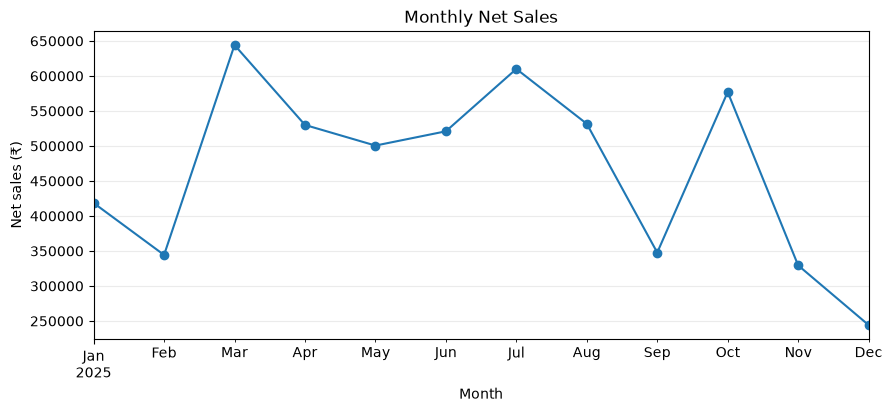

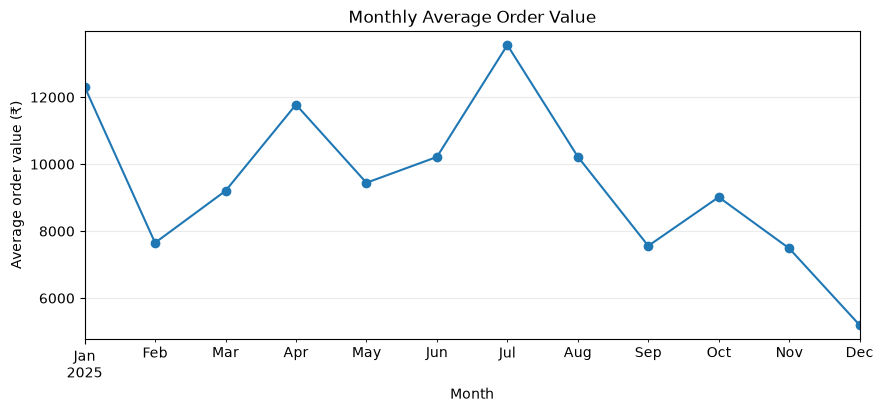

In [732]:
monthly["revenue"].plot(
    kind="line",
    marker="o",
    figsize=(10, 4),
    title="Monthly Net Sales"
)
plt.xlabel("Month")
plt.ylabel("Net sales (₹)")
plt.grid(alpha=0.25)
plt.show()
plt.close()

monthly["average_order_value"].plot(
    kind="line",
    marker="o",
    figsize=(10, 4),
    title="Monthly Average Order Value"
)
plt.xlabel("Month")
plt.ylabel("Average order value (₹)")
plt.grid(alpha=0.25)
plt.show()
plt.close()

## Project Step 9 — Relationship and correlation analysis

Correlation with net_sales:
net_sales          1.00
gross_sales        1.00
unit_price         0.84
quantity           0.30
shipping_days     -0.00
discount          -0.01
customer_rating   -0.04
Name: net_sales, dtype: float64


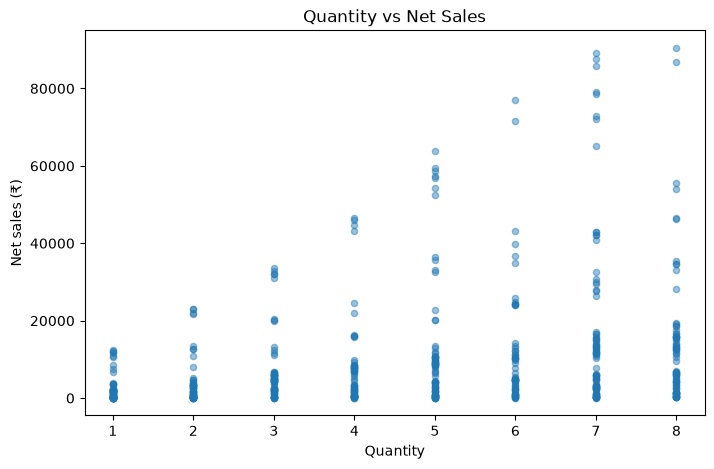

In [733]:
relationship_cols = [
    "quantity", "unit_price", "discount",
    "shipping_days", "customer_rating",
    "gross_sales", "net_sales"
]

relationship_matrix = df[relationship_cols].corr().round(2)

print("Correlation with net_sales:")
print(relationship_matrix["net_sales"].sort_values(ascending=False))

df.plot.scatter(
    x="quantity",
    y="net_sales",
    figsize=(8, 5),
    alpha=0.45,
    title="Quantity vs Net Sales"
)
plt.xlabel("Quantity")
plt.ylabel("Net sales (₹)")
plt.show()
plt.close()

## Project Step 10 — Investigate outliers rather than deleting them blindly

In [734]:
def outlier_report(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return pd.Series({
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_fence": lower,
        "upper_fence": upper,
        "outlier_count": int(mask.sum()),
        "outlier_pct": round(mask.mean() * 100, 2)
    })

project_outliers = pd.DataFrame({
    c: outlier_report(df[c])
    for c in ["unit_price", "quantity", "shipping_days", "net_sales"]
}).T

project_outliers

,Q1,Q3,IQR,lower_fence,upper_fence,outlier_count,outlier_pct
unit_price,359.007500,2229.107500,1870.100000,-2446.142500,5034.257500,67.0,11.24
quantity,3.000000,7.000000,4.000000,-3.000000,13.000000,0.0,0.00
shipping_days,3.000000,6.000000,3.000000,-1.500000,10.500000,0.0,0.00
net_sales,957.735315,10926.847878,9969.112563,-13995.933529,25880.516721,57.0,9.56


## Project Step 11 — Produce evidence-based findings

The code below extracts a few factual results. The analyst should then explain what these results may mean and what should be investigated next.

In [735]:
top_city = city_summary.iloc[0]
top_category = category_summary.iloc[0]
top_segment = (
    df.groupby("segment")["net_sales"]
      .sum()
      .sort_values(ascending=False)
      .iloc[0]
)
top_segment_value = (
    df.groupby("segment")["net_sales"]
      .sum()
      .sort_values(ascending=False)
      .iloc[0]
)

peak_month = monthly["revenue"].idxmax()

findings = {
    "top_city": f"{top_city['city']} — ₹{top_city['revenue']:,.0f} net sales",
    "top_category": f"{top_category['category']} — ₹{top_category['revenue']:,.0f} net sales",
    "top_segment": f"{top_segment} — ₹{top_segment_value:,.0f} net sales",
    "peak_month": f"{peak_month.strftime('%B %Y')} — ₹{monthly.loc[peak_month, 'revenue']:,.0f}",
    "return_rate": f"{df['returned'].eq('Yes').mean() * 100:.2f}%"
}

findings

{'top_city': 'Mumbai — ₹1,574,967 net sales',
 'top_category': 'Electronics — ₹2,936,680 net sales',
 'top_segment': '3235135.608355 — ₹3,235,136 net sales',
 'peak_month': 'March 2025 — ₹644,133',
 'return_rate': '6.21%'}

## Project Step 12 — Export the analysis outputs

A real EDA project should leave behind reusable outputs, not only notebook charts.

In [736]:
FIG_DIR = OUTPUT / "eda_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(OUTPUT / "eda_sales_clean.csv", index=False)
kpis.to_csv(OUTPUT / "eda_kpis.csv", index=False)
city_summary.to_csv(OUTPUT / "eda_city_summary.csv", index=False)
category_summary.to_csv(OUTPUT / "eda_category_summary.csv", index=False)
monthly.to_csv(OUTPUT / "eda_monthly_summary.csv")

print("Saved cleaned data and summary tables to:", OUTPUT.resolve())

Saved cleaned data and summary tables to: E:\Data Engineering\DE\Data-Engineering\Python For Data Engineering\Intermediate - 8\.pandas_course_lab\output


## Project Step 13 — Management-style conclusion template

Do not write unsupported claims. Use the numbers from your tables and charts.

A strong conclusion should contain:

**Finding:** What does the analysis show?  
**Evidence:** Which metric, chart or comparison supports it?  
**Implication:** Why might this matter to the business?  
**Next step:** What should be investigated before taking action?  

Example structure:

> “The analysis shows that **[city/category]** generated **₹X** in net sales, based on the city/category summary. This indicates that it is a significant contributor to the observed revenue in this dataset. Before changing budgets or strategy, the business should investigate **order volume, customer mix, margin and operational factors** to understand why the difference occurs.”

This keeps the report evidence-based and avoids turning one EDA result into an unsupported causal claim.

## 🎯 Independent student challenge

Repeat the project with the following changes without copying the demonstration:

1. Find the top three products by net sales and visualise them.
2. Compare average customer rating by city.
3. Calculate return rate by sales channel.
4. Identify the month with the highest number of orders.
5. Create a city × segment revenue pivot table and visualise it.
6. Find the top five net-sales outliers and investigate their product/category.
7. Write **three factual findings** and **two questions for further investigation**.

### Final project check

Your notebook should clearly show:

`raw data → profile → quality issues → cleaning decisions → EDA tables → visualisations → outlier investigation → findings → exported outputs`

# 3️⃣4️⃣ End-to-End Project 2 — Customer Enrichment

Goal: join transactions with customer attributes, then compare customer segments.

In [737]:
orders = df.copy()
customers = pd.read_csv(RAW / "eda_customers.csv")

enriched = orders.merge(
    customers,
    on="customer_id",
    how="left",
    suffixes=("_order", "_master"),
    validate="many_to_one"
)

print(enriched[[
    "order_id", "customer_id", "customer_order",
    "city_order", "segment_order", "net_sales"
]].head())

segment_summary = (
    enriched.groupby("segment_master", as_index=False)
            .agg(
                orders=("order_id", "nunique"),
                customers=("customer_id", "nunique"),
                revenue=("net_sales", "sum")
            )
            .sort_values("revenue", ascending=False)
)

print("\nSegment summary")
print(segment_summary)

   order_id customer_id customer_order city_order   segment_order    net_sales
0      5354        C018   Customer_018    Chennai        Consumer   4840.73022
1      5337        C006   Customer_006  Hyderabad        Consumer   6146.45982
2      5311        C012   Customer_012  Hyderabad  Small Business  78645.89880
3      5519        C116   Customer_116  Hyderabad  Small Business   1235.82312
4      5256        C081   Customer_081     Mumbai       Corporate   5206.66248

Segment summary
   segment_master  orders  customers       revenue
0        Consumer     332         66  3.235136e+06
1       Corporate     148         29  1.270025e+06
2  Small Business     116         25  1.093361e+06


## 📝 Class Practice — 3️⃣4️⃣ End-to-End Project 2 — Customer Enrichment

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 138 — Easy → Medium

**Question:** Merge customer information with sales data.

💡 **Hint:** Choose an appropriate key.

**Your task:** Write and run your own Pandas code in the cell below.

In [738]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 139 — Easy

**Question:** Calculate total spending for each customer.

💡 **Hint:** Group by customer and sum the sales amount.

**Your task:** Write and run your own Pandas code in the cell below.

In [739]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 140 — Easy

**Question:** Identify customers who have never appeared in the sales table.

💡 **Hint:** Use an outer merge with an indicator or an anti join if supported.

**Your task:** Write and run your own Pandas code in the cell below.

In [740]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 3️⃣5️⃣ End-to-End Project 3 — Monthly KPI Dashboard Table

Goal: create a monthly KPI table that can be exported to Excel/CSV or plotted.

In [741]:
monthly = (
    df.set_index("order_date")
      .resample("ME")
      .agg(
          orders=("order_id", "nunique"),
          units=("quantity", "sum"),
          revenue=("net_sales", "sum")
      )
      .reset_index()
)

monthly["avg_order_value"] = monthly["revenue"] / monthly["orders"]
print(monthly)

   order_date  orders  units        revenue  avg_order_value
0  2025-01-31      34  145.0  418543.331670     12310.097990
1  2025-02-28      45  206.0  344325.197700      7651.671060
2  2025-03-31      70  322.0  644133.441510      9201.906307
3  2025-04-30      45  223.0  530012.367220     11778.052605
4  2025-05-31      53  208.0  500555.662720      9444.446466
5  2025-06-30      51  213.0  520935.312305     10214.417888
6  2025-07-31      45  192.0  610027.822710     13556.173838
7  2025-08-31      52  265.0  531617.445550     10223.412414
8  2025-09-30      46  202.0  347743.176720      7559.634277
9  2025-10-31      64  295.0  577015.806960      9015.871984
10 2025-11-30      44  252.0  329411.041540      7486.614580
11 2025-12-31      47  212.0  244200.432950      5195.753893


## 📝 Class Practice — 3️⃣5️⃣ End-to-End Project 3 — Monthly KPI Dashboard Table

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 141 — Easy → Medium

**Question:** Create a monthly sales table containing total sales and total quantity.

💡 **Hint:** Use datetime conversion plus `groupby`/resampling.

**Your task:** Write and run your own Pandas code in the cell below.

In [742]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 142 — Easy

**Question:** Add average order value to the monthly KPI table.

💡 **Hint:** Think about total sales divided by number of orders.

**Your task:** Write and run your own Pandas code in the cell below.

In [743]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 3️⃣6️⃣ End-to-End Project 4 — Data Quality Report

Goal: build a repeatable report showing missingness, uniqueness, dtypes, and possible duplicate business keys.

In [744]:
quality_report = pd.DataFrame({
    "dtype": project_raw.dtypes.astype(str),
    "missing_count": project_raw.isna().sum(),
    "missing_pct": (project_raw.isna().mean() * 100).round(2),
    "unique_values": project_raw.nunique(dropna=True),
}).sort_values("missing_pct", ascending=False)

print(quality_report)
print("\nExact duplicate rows:", project_raw.duplicated().sum())
print("Duplicate order IDs:", project_raw["order_id"].duplicated().sum())
print("Invalid quantity:", (project_raw["quantity"] <= 0).sum())
print("Suspicious unit prices:", (project_raw["unit_price"] > 50_000).sum())

                   dtype  missing_count  missing_pct  unique_values
discount         float64             14         2.33            181
customer_rating  float64             10         1.66              4
shipping_days    float64              8         1.33             10
order_id           int64              0         0.00            599
city                 str              0         0.00              6
order_date           str              0         0.00            290
customer_id          str              0         0.00            120
customer             str              0         0.00            120
product              str              0         0.00             18
category             str              0         0.00              4
segment              str              0         0.00              3
quantity         float64              0         0.00              9
payment              str              0         0.00              5
unit_price       float64              0         

## 📝 Class Practice — 3️⃣6️⃣ End-to-End Project 4 — Data Quality Report

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 143 — Easy

**Question:** Create a report showing missing values by column.

💡 **Hint:** Use `isna().sum()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [745]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 144 — Easy → Medium

**Question:** Create a report showing the number of unique values in every column.

💡 **Hint:** Use `.nunique()`.

**Your task:** Write and run your own Pandas code in the cell below.

In [746]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 3️⃣7️⃣ Practice Lab — Beginner to Advanced

Try these without looking back. Start from the easy questions and progress toward integrated workflows.

### 🧩 01 — DataFrame creation

**Task:** Create a DataFrame for 5 students with name, age, branch, and marks.

In [747]:
# Write your solution here

### 🧩 02 — Inspection

**Task:** Print shape, columns, dtypes, head, and descriptive statistics for `sales`.

In [748]:
# Write your solution here

### 🧩 03 — Column selection

**Task:** Select only customer, city, product, and quantity.

In [749]:
# Write your solution here

### 🧩 04 — Filtering

**Task:** Return only orders from Chennai.

In [750]:
# Write your solution here

### 🧩 05 — Multiple filters

**Task:** Find orders with quantity >= 3 and unit_price < 1000.

In [751]:
# Write your solution here

### 🧩 06 — New column

**Task:** Create `gross_sales = quantity * unit_price`.

In [752]:
# Write your solution here

### 🧩 07 — Sorting

**Task:** Show the five orders with the largest gross sales.

In [753]:
# Write your solution here

### 🧩 08 — Missing data

**Task:** Report missing counts and percentages.

In [754]:
# Write your solution here

### 🧩 09 — GroupBy

**Task:** Find total net sales by city.

In [755]:
# Write your solution here

### 🧩 10 — Multi-key GroupBy

**Task:** Find total net sales by city and category.

In [756]:
# Write your solution here

### 🧩 11 — Transform

**Task:** Add each order’s share of its city’s total sales.

In [757]:
# Write your solution here

### 🧩 12 — Merge

**Task:** Join sales with customer segment information.

In [758]:
# Write your solution here

### 🧩 13 — Pivot

**Task:** Create a city × category table of net sales.

In [759]:
# Write your solution here

### 🧩 14 — Melt

**Task:** Convert a student marks table from wide to long format.

In [760]:
# Write your solution here

### 🧩 15 — Date time

**Task:** Find monthly revenue using resampling.

In [761]:
# Write your solution here

### 🧩 16 — Rolling

**Task:** Calculate a 3-period rolling average of monthly revenue.

In [762]:
# Write your solution here

### 🧩 17 — Categories

**Task:** Create Bronze/Silver/Gold as an ordered categorical type.

In [763]:
# Write your solution here

### 🧩 18 — JSON

**Task:** Normalize a nested list of customer records.

In [764]:
# Write your solution here

### 🧩 19 — Chunking

**Task:** Read sales in chunks and calculate total units.

In [765]:
# Write your solution here

### 🧩 20 — Validation

**Task:** Build assertions for required columns, positive quantity, and unique order IDs.

In [766]:
# Write your solution here

### 🧩 21 — Anti join

**Task:** Find IDs present in one table but absent in another.

In [767]:
# Write your solution here

### 🧩 22 — merge_asof

**Task:** Match events to the most recent preceding timestamped measurement.

In [768]:
# Write your solution here

### 🧩 23 — Performance

**Task:** Compare memory before and after converting a repeated text column to category.

In [769]:
# Write your solution here

## 📝 Class Practice — 3️⃣7️⃣ Practice Lab — Beginner to Advanced

These are **in-class practice exercises**. Try each problem yourself before using the hint. The hint identifies the Pandas idea to use but **does not give the solution**.

### 🧩 Practice 145 — Easy

**Question:** Build a new DataFrame with at least 6 rows and 5 columns using your own data.

💡 **Hint:** Include both numeric and text columns.

**Your task:** Write and run your own Pandas code in the cell below.

In [770]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 146 — Easy

**Question:** Filter the DataFrame using two conditions and display only selected columns.

💡 **Hint:** Use boolean indexing plus a column list.

**Your task:** Write and run your own Pandas code in the cell below.

In [771]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 147 — Easy → Medium

**Question:** Create one derived column using vectorized arithmetic.

💡 **Hint:** Do not use a loop.

**Your task:** Write and run your own Pandas code in the cell below.

In [772]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 148 — Easy

**Question:** Group by one categorical column and calculate two statistics.

💡 **Hint:** Use `.groupby(...).agg(...)`.

**Your task:** Write and run your own Pandas code in the cell below.

In [773]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 149 — Easy

**Question:** Sort the final result and save it as a CSV file.

💡 **Hint:** Use `.sort_values()` followed by `.to_csv(index=False)`.

**Your task:** Write and run your own Pandas code in the cell below.

In [774]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


### 🧩 Practice 150 — Easy → Medium

**Question:** Write a short three-step data-cleaning pipeline using method chaining.

💡 **Hint:** Try `dropna`, `drop_duplicates`, and `reset_index`.

**Your task:** Write and run your own Pandas code in the cell below.

In [775]:
# Write your solution here.
# Tip: read the question carefully, predict the output, then run your code.


# 3️⃣8️⃣ Common Mistakes — Memorize These

These errors appear frequently when students move from Python to Pandas.

### 1. Using `and` / `or` instead of `&` / `|`

Wrong:
```python
# df[(df["age"] > 20) and (df["marks"] > 80)]
```
Correct:
```python
df[(df["age"] > 20) & (df["marks"] > 80)]
```

### 2. Forgetting parentheses around each comparison
```python
df[(df["age"] > 20) & (df["marks"] > 80)]
```

### 3. Confusing one bracket with two
```python
df["marks"]          # Series
df[["marks"]]        # DataFrame
```

### 4. Checking missing values with `== np.nan`
Use:
```python
df["x"].isna()
```

### 5. Accidentally losing leading zeros in IDs
Use a string dtype when reading identifiers:
```python
pd.read_csv(path, dtype={"customer_id": "string"})
```

### 6. Chained assignment
Prefer one explicit assignment:
```python
df.loc[df["marks"] >= 40, "result"] = "Pass"
```

### 7. Using `apply` for everything
Before writing `apply`, ask whether a vectorized Pandas operation already exists.

### 8. Blindly trusting automatic dtype inference
Inspect `df.dtypes` and explicitly convert important columns when needed.

### 9. Merging without checking key uniqueness
Use `validate=` when you know the intended relationship.

### 10. Treating every missing value the same
Missing salary, missing category, missing timestamp, and missing comment may require different business decisions.

# 3️⃣9️⃣ Pandas Cheat Sheet

Use this only for revision. Learn the concepts first; then use the cheat sheet for recall.

| Task | Typical Pandas code |
|---|---|
| Import | `import pandas as pd` |
| Create Series | `pd.Series([...])` |
| Create DataFrame | `pd.DataFrame({...})` |
| Read CSV | `pd.read_csv(path)` |
| Write CSV | `df.to_csv(path, index=False)` |
| First rows | `df.head()` |
| Last rows | `df.tail()` |
| Random sample | `df.sample(n, random_state=42)` |
| Shape | `df.shape` |
| Columns | `df.columns` |
| Types | `df.dtypes` |
| Summary | `df.describe()` |
| Info | `df.info()` |
| One column | `df["col"]` |
| Multiple columns | `df[["a", "b"]]` |
| Label selection | `df.loc[...]` |
| Position selection | `df.iloc[...]` |
| Filter | `df[df["age"] > 20]` |
| Multiple conditions | `df[(cond1) & (cond2)]` |
| Membership | `df["city"].isin([...])` |
| Add column | `df["new"] = expression` |
| Rename | `df.rename(columns={...})` |
| Drop columns | `df.drop(columns=[...])` |
| Sort | `df.sort_values("col")` |
| Statistics | `mean`, `median`, `min`, `max`, `sum`, `count` |
| Missing | `isna`, `fillna`, `dropna` |
| Duplicates | `duplicated`, `drop_duplicates` |
| Strings | `df["name"].str.strip()` |
| Category | `astype("category")` |
| Grouping | `df.groupby(...)` |
| Merge | `df1.merge(df2, ...)` |
| Concat | `pd.concat([...])` |
| Pivot | `df.pivot(...)` |
| Pivot table | `df.pivot_table(...)` |
| Long format | `df.melt(...)` |
| Datetime | `pd.to_datetime(...)` |
| Date parts | `df["date"].dt.month` |
| Resample | `df.resample(...)` |
| Rolling | `df.rolling(...)` |
| SQL read | `pd.read_sql_query(...)` |
| JSON normalize | `pd.json_normalize(...)` |
| Chunked CSV | `pd.read_csv(..., chunksize=...)` |
| Memory | `df.memory_usage(deep=True)` |
| Modern elementwise DataFrame mapping | `df.map(func)` |

# 4️⃣0️⃣ Recommended Learning Strategy


Do not try to memorize Pandas function names in one sitting. Learn in layers:

### Day 1 — Foundations
`Series → DataFrame → index → columns → head/info/describe → loc/iloc`

### Day 2 — Everyday manipulation
`filtering → new columns → sorting → missing values → strings → duplicates`

### Day 3 — Analysis
`statistics → groupby → agg → transform → merge → pivot_table`

### Day 4 — Real data
`CSV → Excel → JSON → SQL → datetime → resample → visualization`

### Day 5 — Advanced
`MultiIndex → rolling/EWM → advanced merges → categorical data → chunking → performance → validation → method chaining`

### Golden rule
For every new function, answer four questions:
1. **What problem does it solve?**
2. **What does it return?**
3. **What happens to the index?**
4. **What happens with missing values?**

That is much more valuable than memorizing syntax alone.

# 📚 Official Documentation & Further Study


For version-specific details, use the official Pandas documentation:

- Pandas User Guide: https://pandas.pydata.org/docs/user_guide/
- API Reference: https://pandas.pydata.org/docs/reference/
- Pandas 3.0 release notes: https://pandas.pydata.org/docs/whatsnew/v3.0.0.html
- Pandas 3.0 string migration guide: https://pandas.pydata.org/docs/user_guide/migration-3-strings.html
- Copy-on-Write guide: https://pandas.pydata.org/docs/user_guide/copy_on_write.html
- PyArrow functionality: https://pandas.pydata.org/docs/user_guide/pyarrow.html

The official user guide currently recommends starting beginners with “10 minutes to pandas”, then moving into the topic-based guides for indexing, missing data, operations, merging, grouping, reshaping, time series, categoricals, plotting, and IO.

# ✅ Course Completion Checklist

Mark these mentally as you become comfortable.

- [ ] I can explain Series vs DataFrame.
- [ ] I understand what an index is and why alignment matters.
- [ ] I can load CSV/Excel/JSON data.
- [ ] I can inspect a new dataset systematically.
- [ ] I can select with `loc` and `iloc`.
- [ ] I can write correct Boolean filters.
- [ ] I can create calculated columns without unnecessary loops.
- [ ] I can clean missing values, text, types, and duplicates.
- [ ] I understand `groupby` and `transform`.
- [ ] I can merge two datasets and validate the relationship.
- [ ] I can reshape with `pivot_table` and `melt`.
- [ ] I can work with dates and resampling.
- [ ] I understand rolling windows.
- [ ] I can process a large CSV in chunks.
- [ ] I can create a data-quality report.
- [ ] I understand modern Pandas 3.x string dtype and Copy-on-Write behavior.
- [ ] I can complete an end-to-end project without copying a solution line-by-line.

- [ ] I can perform a complete EDA workflow from raw data to findings.
- [ ] I can analyse numeric distributions with descriptive statistics, histograms and box plots.
- [ ] I can compare categorical groups with `groupby()`, `pivot_table()` and bar charts.
- [ ] I can investigate numeric relationships with scatter plots and correlation.
- [ ] I can analyse time trends with datetime features and resampling.
- [ ] I can identify and investigate potential outliers using the IQR rule.
- [ ] I can write evidence-based findings and distinguish observations from questions for further investigation.
